In [2]:
from neural_priors.utils.data import get_all_behavioral_data, get_all_subject_ids
import pingouin as pg
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
import numpy as np
import os, pickle
from scipy import stats, odr, optimize
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
plt.rcParams['legend.frameon'] = False
np.set_printoptions(linewidth=140)
pd.set_option('display.width', 170) # 80
pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 70)

In [4]:
NARROW = 'narrow'
WIDE = 'wide'
CONDITIONS = [NARROW, WIDE]
# COLORS_COND = {NARROW:'C0', WIDE:'C1'}; THIRD_COLOR = '#009E73'
# COLORS_COND = {NARROW:'#0072B2', WIDE:'#D55E00'}; THIRD_COLOR = '#7570B3'
# COLORS_COND = {NARROW:'#009E73', WIDE:'#E69F00'}; THIRD_COLOR = '#56B4E9'
# COLORS_COND = {NARROW:'#56B4E9', WIDE:'#CC79A7'}; THIRD_COLOR = '#999933'
#COLORS_COND = {NARROW:'#56B4E9', WIDE:'C1'}; THIRD_COLOR = '#009E73'; FOURTH_COLOR = 'C4'
COLORS_COND = {NARROW:'#56B4E9', WIDE:'C1'}; THIRD_COLOR = '#55BB55'; FOURTH_COLOR = 'C4'
#COLORS_COND = {NARROW:'#56B4E9', WIDE:'xkcd:peach'}; THIRD_COLOR = '#009E73'; FOURTH_COLOR = 'C4'
#COLORS_COND = {NARROW:'cornflowerblue', WIDE:'C1'}; THIRD_COLOR = '#009E73'; FOURTH_COLOR = 'C4'
#COLORS_COND = {NARROW:'#008080', WIDE:'#AA3377'}; THIRD_COLOR = '#009E73'
MAX_COND = {NARROW: 25, WIDE: 40}
M_NARROW = 17.5
M_WIDE = 25.
SD_NARROW = 15./np.sqrt(12)
SD_WIDE   = 30./np.sqrt(12)
W_NARROW = 15.
W_WIDE   = 30.
HW_NARROW = W_NARROW/2
HW_WIDE   = W_WIDE/2

In [5]:
# def obvious_index_filter(df, **kwargs):
#     r = df
#     for k,v in kwargs.items():
#         r = r.xs(v, level=k)
#     return r

def index_filter(df, **kwargs):
    """
    Filter a DataFrame based on index level value(s) and drop levels uniquely determined
    by a single-value filter.

    For a MultiIndex, only those levels filtered by a single element (not list-like)
    that then have only one unique value in the result are dropped.
    For a simple index, if the filtering criterion is a single element and the index
    becomes constant, the index is reset (dropped).

    Parameters:
        df (pd.DataFrame): The DataFrame to filter.
        **kwargs: Each keyword corresponds to an index level name and its filter condition.
                  The condition may be a single value or a list/tuple/set of acceptable values.

    Returns:
        pd.DataFrame: The filtered DataFrame.
    """
    # No filters provided; return the original DataFrame.
    if not kwargs:
        return df

    idx = df.index

    # MultiIndex handling.
    if isinstance(idx, pd.MultiIndex):
        mask = np.ones(len(df), dtype=bool)
        # Build the mask for each provided index level.
        for level, value in kwargs.items():
            if level not in idx.names:
                raise KeyError(f"Index level '{level}' not found in MultiIndex {idx.names}.")
            if not isinstance(value, str) and hasattr(value, '__iter__'): #isinstance(value, (list, tuple, set)):
                mask &= idx.get_level_values(level).isin(value)
            else:
                mask &= (idx.get_level_values(level) == value)
        filtered_df = df[mask]

        # Only drop levels that were filtered with a single value and are constant.
        to_drop = [level for level, value in kwargs.items() 
                   if not isinstance(value, (list, tuple, set)) 
                   and filtered_df.index.get_level_values(level).nunique() == 1]
        if to_drop:
            filtered_df = filtered_df.droplevel(to_drop)
        return filtered_df

    # Simple index handling.
    else:
        if len(kwargs) > 1:
            raise ValueError("A simple index DataFrame accepts only one filtering criterion.")
        key, value = next(iter(kwargs.items()))
        # If the simple index has a name, it must match the key.
        if idx.name is not None and idx.name != key:
            raise KeyError(f"Simple index name '{idx.name}' does not match filter key '{key}'.")
        # Apply the filtering.
        if not isinstance(value, str) and hasattr(value, '__iter__'): # isinstance(value, (list, tuple, set)):
            mask = idx.isin(value)
        else:
            mask = (idx == value)
        filtered_df = df[mask]

        # Drop the index (by resetting it) only if the filter was a single value and the index is constant.
        if not isinstance(value, (list, tuple, set)) and filtered_df.index.nunique() == 1:
            filtered_df = filtered_df.reset_index(drop=True)
        return filtered_df

In [6]:
def paired_strip_plot(ax, x1, x2, y1, y2, jitter=0.05,
                      marker='o', markersize=8, col1='C0', col2='C1',
                      color_line='grey', alpha=0.4, line_width=0.5,
                      color_incr_line=None, color_decr_line=None
                      ):
    """
    Creates a paired strip plot on the given axis.
    
    Parameters:
      ax : matplotlib.axes.Axes
          The axis to plot on.
      x1, x2 : float
          The x-axis positions for the two groups.
      y1, y2 : array-like
          The y-values for the two groups. They should have the same length.
      jitter : float, optional
          The standard deviation of the jitter to add to the x positions (default 0.05).
      marker : str, optional
          The marker style for the points (default 'o').
      markersize : int, optional
          The marker size (default 8).
      col1 : str, optional
          The color for the points in group 1 (default 'C0').
      col2 : str, optional
          The color for the points in group 2 (default 'C1').
      color_line : str, optional
          The color for the connecting lines (default 'grey').
      alpha : float, optional
          The transparency for points and lines (default 0.4).
      line_width : float, optional
          The width of the connecting lines (default 0.5).
    """
    
    color_incr_line = color_incr_line or color_line
    color_decr_line = color_decr_line or color_line

    # Create jittered x positions for each group
    xs1 = np.full(len(y1), x1) + np.random.normal(0, jitter, size=len(y1))
    xs2 = np.full(len(y2), x2) + np.random.normal(0, jitter, size=len(y2))

    # Plot the points for both groups with separate colors
    ax.plot(xs1, y1, linestyle='None', marker=marker, markersize=markersize,
            color=col1, alpha=alpha)
    ax.plot(xs2, y2, linestyle='None', marker=marker, markersize=markersize,
            color=col2, alpha=alpha)

    # Connect each paired point with a line
    for xi1, xi2, yi1, yi2 in zip(xs1, xs2, y1, y2):
        c = color_incr_line if yi2 > yi1 else color_decr_line if yi2 < yi1 else color_line
        ax.plot([xi1, xi2], [yi1, yi2], color=c,
                linewidth=line_width, alpha=alpha)

In [7]:
def odr_1dregression(x, y, data=None):
    if data is None:
        dat = odr.Data(x, y)
    else:
        dat = odr.Data(data[x], data[y])
    myodr = odr.ODR(dat, odr.unilinear, beta0=[1., 0.]) # start point = identity
    res = myodr.run()
    return res

def odr_pred(odr_res, x):
    B = odr_res.beta
    return B[0]*x + B[1]

In [8]:
def quick_ols(y, x):
    model = sm.OLS(y, sm.add_constant(x))
    return model.fit()

In [9]:
def star_string(pv):
    return '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else ''

In [10]:
from matplotlib.transforms import blended_transform_factory

def star_line(ax, x1, x2, y, pval, star_size=10, star_offset=0,
              star_color='black', line_color='black', line_width=1,
              vertical_lines_length=0.05, yTransAxes=False):
    """
    Draws a star and a line between two x positions at a specified y position on the given axis.

    If yTransAxes is True, y (and vertical_lines_length) are interpreted as a fraction of the y-axis.
    x1 and x2 are always in data coordinates.
    
    Parameters:
        ax: matplotlib axis
        x1, x2: x positions (data coordinates)
        y: y position; if yTransAxes is True, this is in axis fraction; otherwise data coordinates.
        pval: p-value to determine the star string.
        star_size: font size for the star.
        star_offset: vertical offset for the star text.
        star_color: color for the star text.
        line_color: color for the line.
        line_width: width of the line.
        vertical_lines_length: length of the vertical lines at the ends.
        yTransAxes: when True, y and vertical_lines_length are in fraction units.
    """
    # Choose appropriate transform for the y coordinate.
    if yTransAxes:
        # x in data coordinates and y in axes fraction.
        transform = blended_transform_factory(ax.transData, ax.transAxes)
    else:
        transform = ax.transData

    # Determine the number of stars based on the p-value.
    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''

    # Draw the stars at the specified position.
    ax.text((x1 + x2) / 2, y + star_offset, stars, fontsize=star_size,
            color=star_color, ha='center', va='bottom', transform=transform)

    # Draw a horizontal line between the two x positions.
    ax.plot([x1, x2], [y, y], color=line_color, linewidth=line_width, transform=transform)

    if vertical_lines_length > 0:
        # Draw vertical lines at the endpoints.
        ax.plot([x1, x1], [y - vertical_lines_length, y], color=line_color,
                linewidth=line_width, transform=transform)
        ax.plot([x2, x2], [y - vertical_lines_length, y], color=line_color,
                linewidth=line_width, transform=transform)

# Data

In [11]:
bids_folder = '../../ds-neuralpriors'

In [12]:
beh = get_all_behavioral_data(bids_folder=bids_folder) #, subjects=[f'{i}'.rjust(2,'0') for i in range(1,23)])
#beh = beh.droplevel(['session', 'run', 'trial_nr'])

In [13]:
beh

onset  phase  response  nr_frames     n  jitter  start_marker_position  response_time   onset_abs  duration   range  error  \
subject session run trial_nr                                                                                                                                    
01      1       1   1          68.826307      5       NaN       30.0  11.0     6.0                   24.0            NaN   76.378611  0.500457  narrow    NaN   
                    2          76.016292      5      19.0       31.0  23.0     4.0                   14.0       1.317963   83.568595  0.517188  narrow   -4.0   
                    3          87.026471      5      25.0       30.0  23.0     6.0                   11.0       0.834244   94.578775  0.500469  narrow    2.0   
                    4          97.085656      5      24.0       30.0  22.0     5.0                   22.0       1.701381  104.637959  0.500559  narrow    2.0   
                    5         106.744768      5      17.0       31.0  21.0     5.0                   22.0       2.018881  114.297072  0.517009  narrow   -4.0   
...                                  ...    ...       ...        ...   ...     ...                    ...            ...         ...       ...     ...    ...   
41      2       8   26        275.797056      5      25.0       30.0  24.0     4.0                   12.0       1.635028  278.746204  0.500532  narrow    1.0   
                    27        286.857371      5      24.0       30.0  19.0     6.0                   15.0       1.701679  289.806518  0.500510  narrow    5.0   
                    28        296.683059      5      22.0       30.0  17.0     5.0                   15.0       0.100000  299.632207  0.500525  narrow    5.0   
                    29        307.476458      5      19.0       30.0  19.0     6.0                   20.0       1.751607  310.425606  0.500458  narrow    0.0   
                    30        317.202043      5      19.0       30.0  19.0     5.0                   24.0       0.049945  320.151190  0.500598  narrow    0.0   

                              abs_error  squared_error  
subject session run trial_nr                            
01      1       1   1               NaN            NaN  
                    2               4.0           16.0  
                    3               2.0            4.0  
                    4               2.0            4.0  
                    5               4.0           16.0  
...                                 ...            ...  
41      2       8   26              1.0            1.0  
                    27              5.0           25.0  
                    28              5.0           25.0  
                    29              0.0            0.0  
                    30              0.0            0.0  

[18720 rows x 14 columns]

In [198]:
subjects = beh.index.get_level_values('subject').unique().astype(int)
subjects

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject')

## Stan

In [199]:
stan = pd.read_csv('stan/outputs/summaries/results_20250815154906.csv', index_col=0)
#stan = pd.read_csv('stan/outputs/summaries_30/results_20250804214456.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10
stan

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-27494.400000,1.491370,65.297500,64.344800,-27602.200000,-27494.900000,-27384.900000,1919.22,3713.90,1.00165
z_m_0_15[1],0.115055,0.000572,0.021728,0.021839,0.079253,0.114889,0.150880,1462.85,2773.69,1.00533
z_m_0_15[2],0.099505,0.000514,0.022336,0.022173,0.063241,0.099115,0.136588,1904.16,2982.67,1.00313
z_m_0_15[3],0.116751,0.000444,0.022452,0.022490,0.080319,0.116716,0.153391,2578.17,4032.47,1.00260
z_m_0_15[4],0.101043,0.000479,0.022759,0.022663,0.063305,0.101099,0.138859,2286.22,4487.77,1.00314
...,...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],0.513938,0.001164,0.153526,0.153864,0.260301,0.515932,0.767961,17576.90,7907.20,1.00091
delta_avg_log_var_s_1322[36],0.621292,0.001134,0.153181,0.152486,0.370653,0.620708,0.875096,18693.40,8183.89,1.00239
delta_avg_log_var_s_1322[37],0.728946,0.001226,0.158177,0.158565,0.469740,0.728784,0.990862,16993.90,7875.83,1.00060
delta_avg_log_var_s_1322[38],0.491022,0.001241,0.156781,0.154829,0.236231,0.489395,0.750402,16656.40,7250.43,1.00084


In [200]:
stan.loc['delta_avg_var_s[1]']

Mean            5.167310
MCSE            0.007279
StdDev          0.797894
MAD             0.789974
5%              3.915290
50%             5.141820
95%             6.523210
ESS_bulk    12225.300000
ESS_tail     8044.570000
R_hat           1.000210
Name: delta_avg_var_s[1], dtype: float64

In [201]:
z = set()
for x in stan.index:
    x = x.split('[')
    if len(x) == 1:
        z.add(x[0])
    elif len(x[1].split(',')) == 1:
        z.add(x[0] + '[i]')
    else:
        z.add(x[0] + '[i,j]')
z
        

{'avg_inv_sigma_0_15',
 'avg_inv_sigma_0_30',
 'avg_inv_sigma_0_30_narrowrange',
 'avg_inv_sigma_s_15[i]',
 'avg_inv_sigma_s_15_1124[i]',
 'avg_inv_sigma_s_15_1223[i]',
 'avg_inv_sigma_s_15_1322[i]',
 'avg_inv_sigma_s_30[i]',
 'avg_inv_sigma_s_30_1124[i]',
 'avg_inv_sigma_s_30_1139[i]',
 'avg_inv_sigma_s_30_1223[i]',
 'avg_inv_sigma_s_30_1238[i]',
 'avg_inv_sigma_s_30_1322[i]',
 'avg_inv_sigma_s_30_1337[i]',
 'avg_inv_sigma_s_30_narrowrange[i]',
 'avg_log_var_0_15',
 'avg_log_var_0_30',
 'avg_log_var_0_30_narrowrange',
 'avg_log_var_s_15[i]',
 'avg_log_var_s_15_1124[i]',
 'avg_log_var_s_15_1223[i]',
 'avg_log_var_s_15_1322[i]',
 'avg_log_var_s_30[i]',
 'avg_log_var_s_30_1124[i]',
 'avg_log_var_s_30_1139[i]',
 'avg_log_var_s_30_1223[i]',
 'avg_log_var_s_30_1238[i]',
 'avg_log_var_s_30_1322[i]',
 'avg_log_var_s_30_1337[i]',
 'avg_log_var_s_30_narrowrange[i]',
 'avg_sigma_0_15',
 'avg_sigma_0_30',
 'avg_sigma_0_30_narrowrange',
 'avg_sigma_s_15[i]',
 'avg_sigma_s_15_1124[i]',
 'avg_sigma_

In [202]:
quantities = ["log_var", "var", "inv_sigma", "sigma"]

# For the narrow condition (model label 15)
stan0_n_list = []
for qty in quantities:
    rows = [f'{qty}_0_15[{i}]' for i in range(1, 17)]
    # extract the three statistics
    df_temp = stan.loc[rows, ['Mean','5%', '95%']]
    # Create a MultiIndex: top level is quantity; second level is statistic name
    df_temp.columns = pd.MultiIndex.from_product([[qty], df_temp.columns])
    df_temp.reset_index(drop=True, inplace=True)
    stan0_n_list.append(df_temp)

stan0_n = pd.concat(stan0_n_list, axis=1)
stan0_n.index = pd.Index(range(10, 26), name='n')
stan0_n

# For the wide condition (model label 30)
stan0_w_list = []
for qty in quantities:
    rows = [f'{qty}_0_30[{i}]' for i in range(1, 32)]
    df_temp = stan.loc[rows, ['Mean','5%', '95%']]
    df_temp.columns = pd.MultiIndex.from_product([[qty], df_temp.columns])
    df_temp.reset_index(drop=True, inplace=True)
    stan0_w_list.append(df_temp)

stan0_w = pd.concat(stan0_w_list, axis=1)
stan0_w.index = pd.Index(range(10, 41), name='n')
stan0_w

log_var                          var                     inv_sigma                        sigma                  
        Mean       5%       95%      Mean        5%       95%      Mean        5%       95%     Mean       5%      95%
n                                                                                                                     
10  0.768838  0.55370  0.988691   2.17608   1.73967   2.68771  0.682323  0.609970  0.758168  1.47195  1.31896  1.63943
11  1.610550  1.41359  1.815850   5.04315   4.11069   6.14630  0.447798  0.403360  0.493222  2.24149  2.02748  2.47918
12  1.869850  1.67076  2.065710   6.53433   5.31617   7.89089  0.393324  0.355989  0.433711  2.55163  2.30568  2.80907
13  1.785540  1.59587  1.976280   6.00361   4.93262   7.21584  0.410217  0.372269  0.450257  2.44605  2.22095  2.68623
14  1.966140  1.77223  2.160890   7.19353   5.88397   8.67887  0.374820  0.339444  0.412254  2.67735  2.42569  2.94599
15  1.932090  1.74514  2.124720   6.95018   5.72669   8.37059  0.381220  0.345639  0.417877  2.63192  2.39305  2.89319
16  2.051640  1.84721  2.253550   7.84085   6.34210   9.52146  0.359193  0.324077  0.397085  2.79476  2.51835  3.08569
17  2.038640  1.84547  2.238720   7.73509   6.33104   9.38135  0.361481  0.326488  0.397432  2.77625  2.51615  3.06290
18  2.103560  1.90909  2.302290   8.25544   6.74695   9.99702  0.349952  0.316275  0.384987  2.86797  2.59749  3.16180
19  2.080300  1.88823  2.274280   8.06230   6.60766   9.72092  0.354012  0.320735  0.389024  2.83452  2.57054  3.11784
20  2.391840  2.19548  2.591900  11.01310   8.98426  13.35520  0.302974  0.273637  0.333625  3.31259  2.99738  3.65447
21  2.218820  2.02062  2.415500   9.26409   7.54295  11.19530  0.330357  0.298869  0.364108  3.03813  2.74645  3.34594
22  2.357520  2.16591  2.550830  10.63690   8.72251  12.81780  0.308183  0.279315  0.338594  3.25587  2.95339  3.58019
23  2.257790  2.06189  2.453810   9.63007   7.86083  11.63250  0.323962  0.293198  0.356669  3.09772  2.80372  3.41066
24  2.325720  2.13627  2.521700  10.30520   8.46775  12.44970  0.313131  0.283414  0.343650  3.20461  2.90995  3.52841
25  2.421790  2.22183  2.625950  11.35160   9.22417  13.81770  0.298496  0.269018  0.329258  3.36285  3.03713  3.71722
26  2.447050  2.24500  2.648600  11.64090   9.44037  14.13430  0.294742  0.265989  0.325466  3.40550  3.07252  3.75955
27  2.548560  2.35714  2.743160  12.87850  10.56070  15.53590  0.280122  0.253706  0.307720  3.58238  3.24971  3.94158
28  2.517860  2.32018  2.716550  12.49140  10.17750  15.12790  0.284468  0.257105  0.313457  3.52798  3.19023  3.88946
29  2.574930  2.37879  2.767180  13.22160  10.79190  15.91380  0.276448  0.250676  0.304404  3.62987  3.28510  3.98921
30  2.526860  2.33235  2.723340  12.60360  10.30210  15.23100  0.283185  0.256233  0.311557  3.54383  3.20969  3.90270
31  2.644700  2.46030  2.833390  14.17190  11.70840  17.00290  0.266945  0.242515  0.292249  3.75839  3.42175  4.12346
32  2.551660  2.36543  2.740070  12.91120  10.64860  15.48810  0.279649  0.254098  0.306446  3.58743  3.26322  3.93549
33  2.501990  2.30685  2.693660  12.29060  10.04270  14.78560  0.286710  0.260064  0.315553  3.49979  3.16904  3.84521
34  2.644120  2.44916  2.842490  14.17400  11.57860  17.15840  0.267069  0.241413  0.293883  3.75798  3.40272  4.14227
35  2.414440  2.20795  2.620620  11.27350   9.09701  13.74430  0.299626  0.269736  0.331551  3.35087  3.01613  3.70733
36  2.454520  2.25275  2.656690  11.72940   9.51382  14.24900  0.293652  0.264915  0.324207  3.41834  3.08445  3.77479
37  2.610310  2.41220  2.813380  13.70390  11.15850  16.66620  0.271628  0.244953  0.299362  3.69506  3.34044  4.08242
38  2.587430  2.39374  2.780130  13.38720  10.95440  16.12110  0.274720  0.249059  0.302139  3.65257  3.30974  4.01511
39  2.583240  2.38634  2.780900  13.33510  10.87360  16.13360  0.275318  0.248963  0.303258  3.64519  3.29753  4.01667
40  2.491330  2.28687  2.696510  12.17100   9.84409  14.82790  0.288306  0.259

In [203]:
stan0_n.index

RangeIndex(start=10, stop=26, step=1, name='n')

In [215]:
dats = []
for nstr_stan in ['', '_narrowrange', '_1124', '_1223', '_1322', '_1139', '_1238', '_1337']:
    #the_index = index_filter(fisher_info_deltas, model_label=15).index
    dats_nstr_stan = []
    conds = []
    for cond in CONDITIONS:
        if cond is NARROW and nstr_stan in ['_1139', '_1238', '_1337']:
            continue
        conds.append(cond)
        da = []
        nn_cond = {NARROW: '15', WIDE: '30'}[cond]
        for qty in ['avg_var', 'avg_sigma', 'avg_inv_sigma', 'avg_log_var' ]:
            if cond is NARROW and nstr_stan == '_narrowrange':
                da.append( stan.loc[[f'{qty}_s_15[{subject}]' for subject in range(1,40)], 'Mean'].rename(qty).reset_index(drop=True) )
            else:
                da.append( stan.loc[[f'{qty}_s_{nn_cond}{nstr_stan}[{subject}]' for subject in range(1,40)], 'Mean'].rename(qty).reset_index(drop=True) )
        stan_avgs_cond = pd.concat(da, axis=1)
        stan_avgs_cond.index = subjects
        dats_nstr_stan.append(stan_avgs_cond)
    stan_avgs_nstr = pd.concat(dats_nstr_stan, axis=0, keys=conds)
    stan_avgs_nstr.index.names = ['condition', 'subject']
    dats.append(stan_avgs_nstr)

stan_avgs = pd.concat(dats, axis=0, keys=['all', 'narrowrange', '1124', '1223', '1322', '1139', '1238', '1337'])
stan_avgs.index.names = ['subrange', 'condition', 'subject']
stan_avgs

avg_var  avg_sigma  avg_inv_sigma  avg_log_var
subrange condition subject                                                 
all      narrow    1         4.51945    2.09239       0.493517      1.44462
                   2         5.16586    2.23781       0.461120      1.57969
                   3         6.72287    2.54261       0.410002      1.82561
                   4         5.60384    2.33301       0.441210      1.66530
                   5         4.06089    1.95980       0.544212      1.28437
...                              ...        ...            ...          ...
1337     wide      37       11.42540    3.27336       0.326354      2.30604
                   38       12.15280    3.36937       0.318670      2.35911
                   39       10.45430    3.12674       0.344825      2.20760
                   40        9.44498    2.98951       0.353995      2.13403
                   41       13.40340    3.54295       0.302830      2.46118

[507 rows x 4 columns]

In [217]:
dats = []
for nstr_stan in ['', '_narrowrange', '_1124', '_1223', '_1322']:
    #the_index = index_filter(fisher_info_deltas, model_label=15).index
    dats_nstr_stan = []
    for qty in ['avg_var', 'avg_sigma', 'avg_inv_sigma', 'avg_log_var' ]:
        dats_nstr_stan.append( stan.loc[[f'delta_{qty}_s{nstr_stan}[{subject}]' for subject in range(1,40)], 'Mean'].rename(f'{qty}_delta_wn').reset_index(drop=True) )
    stan_delta_avgs_nstr = pd.concat(dats_nstr_stan, axis=1)
    stan_delta_avgs_nstr.index = subjects
    dats.append(stan_delta_avgs_nstr)
stan_delta_avgs = pd.concat(dats, axis=0, keys=['all', 'narrowrange', '1124', '1223', '1322'])
stan_delta_avgs.index.names = ['subrange', 'subject']
stan_delta_avgs

avg_var_delta_wn  avg_sigma_delta_wn  avg_inv_sigma_delta_wn  avg_log_var_delta_wn
subrange subject                                                                                    
all      1                 5.16731            0.931676               -0.142603              0.709790
         2                 5.30783            0.899712               -0.118288              0.638578
         3                 7.48059            1.100640               -0.114891              0.689278
         4                 6.18644            1.007090               -0.122107              0.686683
         5                 8.78583            1.481590               -0.219931              1.089710
...                            ...                 ...                     ...                   ...
1322     37                3.35587            0.638242               -0.109532              0.513938
         38                3.86925            0.757178               -0.133374              0.621292
         39                4.27519            0.851930               -0.167210              0.728946
         40                3.07499            0.599511               -0.105406              0.491022
         41                7.37705            1.256400               -0.186674              0.931079

[195 rows x 4 columns]

In [218]:
subj_i_to_subj = {(i+1):subj for i,subj in enumerate( stan_delta_avgs.index.get_level_values('subject').unique()) }
print(subj_i_to_subj)

{1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 24, 23: 25, 24: 26, 25: 27, 26: 28, 27: 29, 28: 30, 29: 31, 30: 32, 31: 33, 32: 34, 33: 35, 34: 36, 35: 37, 36: 38, 37: 39, 38: 40, 39: 41}


In [219]:
das = []
quantities = ['m_s', 'sigma_s', 'var_s', 'inv_sigma_s', 'log_var_s', ]
for qty in quantities:
    da = []
    for cond in CONDITIONS:
        cond_k = {NARROW: 15, WIDE: 30}[cond]
        for subject in range(1, 40):
            nmax = {NARROW: 17, WIDE: 32}[cond]
            for n in range(1, nmax):
                v = stan.loc[f'{qty}_{cond_k}[{subject},{n}]', 'Mean']
                da.append([subj_i_to_subj[subject], cond, n+9., v])
    da = pd.DataFrame(da, columns=['subject', 'condition', 'n', qty[:-2]]).set_index(['subject', 'condition', 'n'])
    das.append(da)
stan_subj_n = pd.concat(das, axis=1)
stan_subj_n['bias'] = stan_subj_n['m'] - stan_subj_n.index.get_level_values('n')
stan_subj_n['log_n'] = np.log(stan_subj_n.index.get_level_values('n'))
stan_subj_n



m    sigma       var  inv_sigma  log_var    bias     log_n
subject condition n                                                                     
1       narrow    10.0  11.6204  2.06285   4.31974   0.491927  1.43340  1.6204  2.302585
                  11.0  12.9499  1.69757   2.95769   0.604200  1.03283  1.9499  2.397895
                  12.0  14.6868  2.40350   5.90082   0.424829  1.73286  2.6868  2.484907
                  13.0  14.9618  2.12623   4.63126   0.481492  1.48500  1.9618  2.564949
                  14.0  16.8867  2.08295   4.44199   0.491202  1.44447  2.8867  2.639057
...                         ...      ...       ...        ...      ...     ...       ...
41      wide      36.0  35.7106  3.63340  13.90460   0.290382  2.52729 -0.2894  3.583519
                  37.0  35.2801  3.63474  13.76590   0.286455  2.54049 -1.7199  3.610918
                  38.0  36.1881  3.44828  12.46470   0.304084  2.42838 -1.8119  3.637586
                  39.0  36.6927  3.29484  11.28060   0.315145  2.34683 -2.3073  3.663562
                  40.0  37.2799  3.07692   9.98379   0.342776  2.19463 -2.7201  3.688879

[1833 rows x 7 columns]

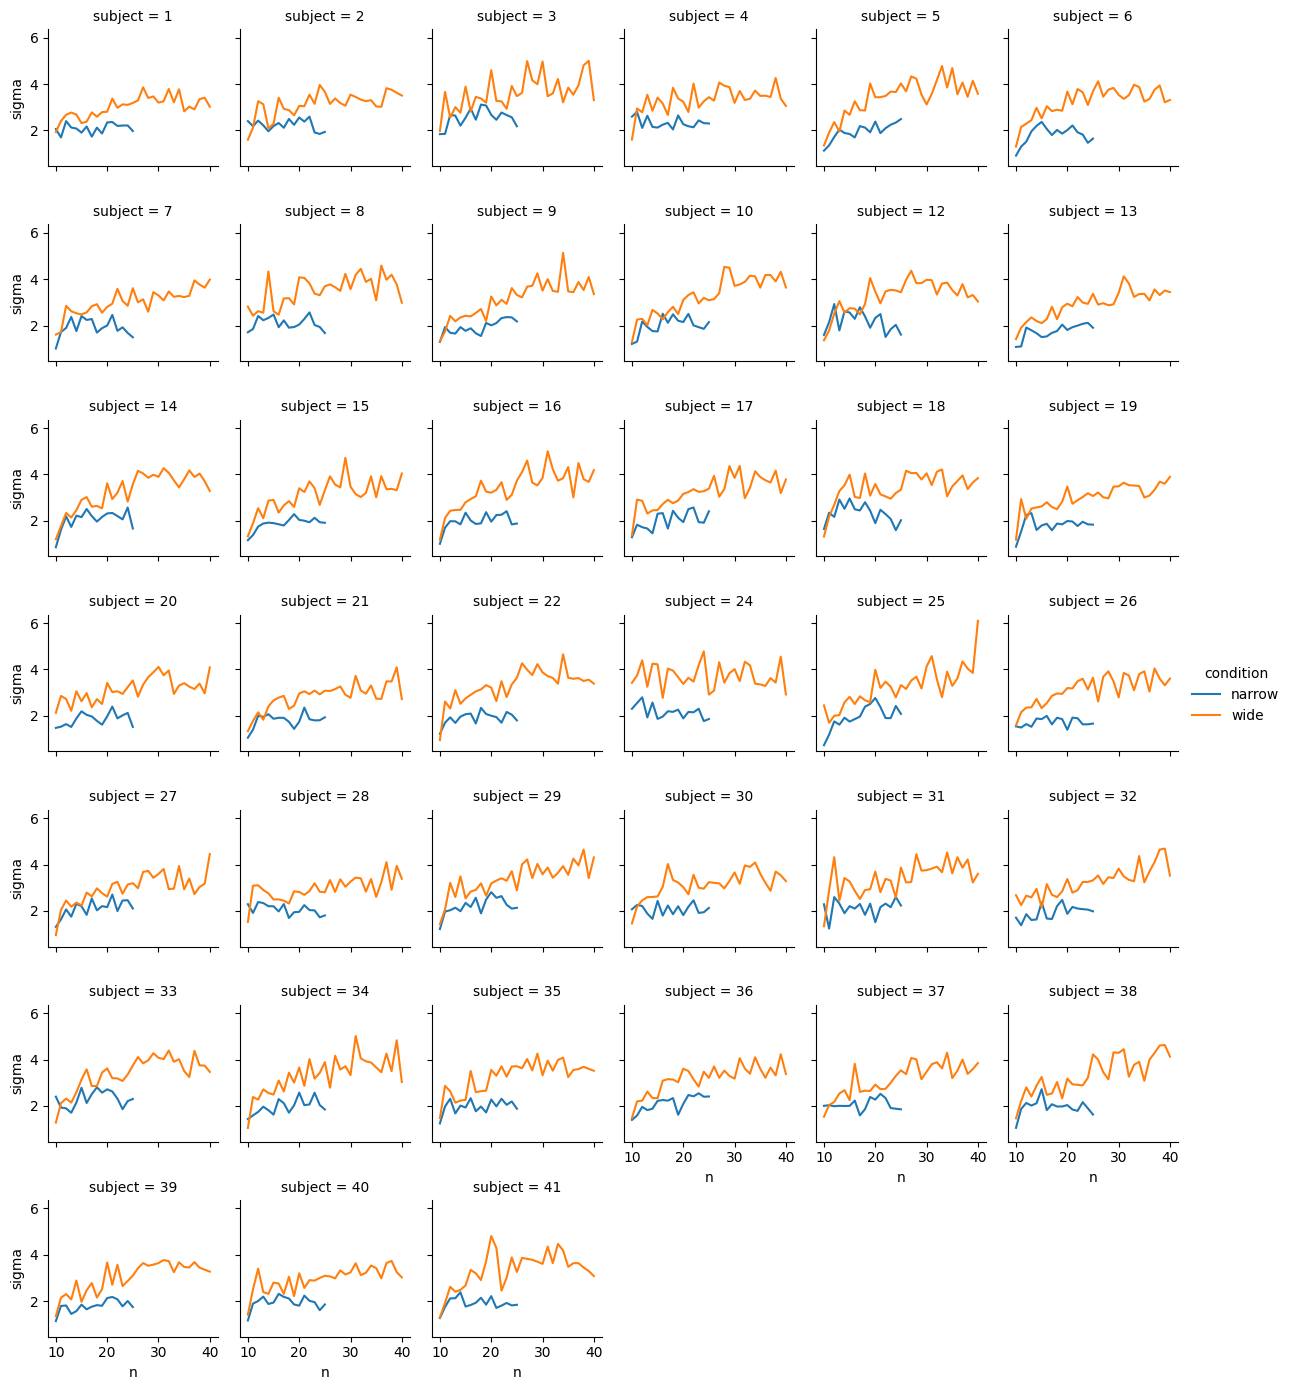

In [220]:
sns.relplot(stan_subj_n, x='n', y='sigma', hue='condition', kind='line', col='subject', col_wrap=6, height=2)

In [221]:
das = []
for qty in ['delta_inv_sigma_s', 'delta_log_var_s', 'delta_sigma_s', 'delta_var_s',
            ]:
    da = []
    for subject in range(1, 40):
        for n in range(1, 17):
            v = stan.loc[f'{qty}[{subject},{n}]', 'Mean']
            da.append([subj_i_to_subj[subject], n+9., v])
    da = pd.DataFrame(da, columns=['subject', 'n', qty[:-2]]).set_index(['subject', 'n'])
    das.append(da)
stan_deltas_subj_n = pd.concat(das, axis=1)
stan_deltas_subj_n

delta_inv_sigma  delta_log_var  delta_sigma  delta_var
subject n                                                           
1       10.0         0.038325      -0.140117    -0.129741  -0.486321
        11.0        -0.178957       0.701977     0.713120   3.003210
        12.0        -0.036966       0.198083     0.271811   1.530240
        13.0        -0.111362       0.528575     0.646809   3.268000
        14.0        -0.101649       0.485611     0.601541   3.097470
...                       ...            ...          ...        ...
41      21.0        -0.372120       1.866620     2.595120  15.916000
        22.0        -0.141217       0.590629     0.645761   2.959660
        23.0        -0.185092       0.877544     1.090670   5.703070
        24.0        -0.307842       1.537040     2.073800  12.066100
        25.0        -0.239719       1.131780     1.417820   7.554490

[624 rows x 4 columns]

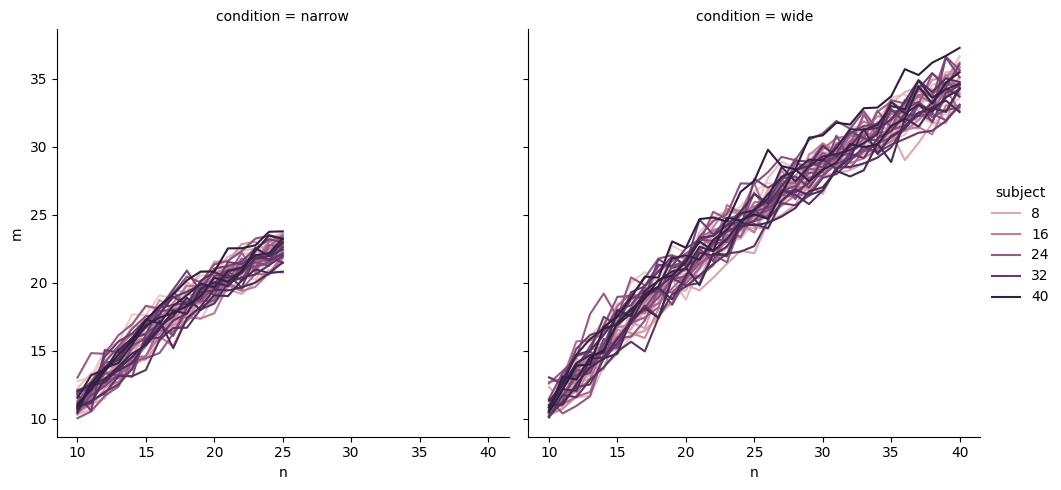

In [222]:
sns.relplot(stan_subj_n, x='n', y='m', hue='subject', kind='line', col='condition')

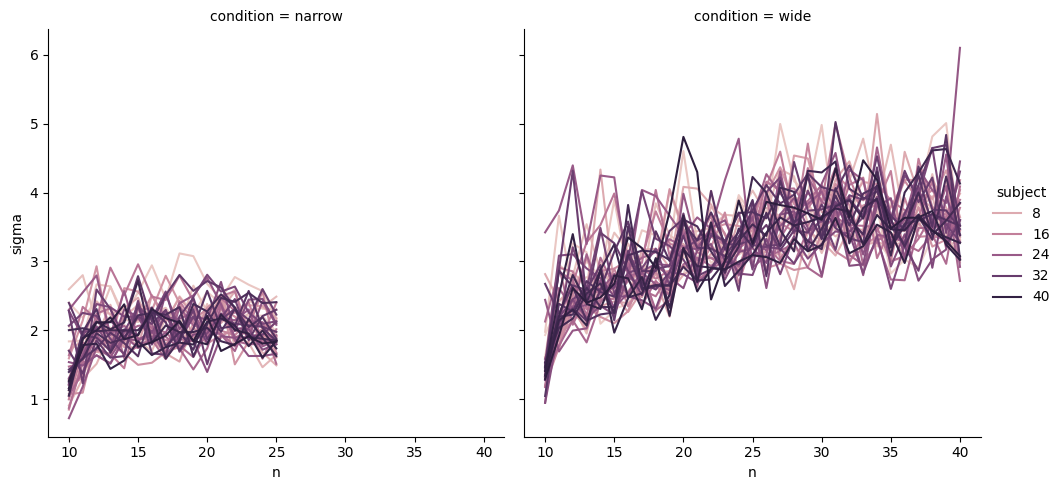

In [223]:
sns.relplot(stan_subj_n, x='n', y='sigma', hue='subject', kind='line', col='condition')

In [224]:
stan_subj_n

m    sigma       var  inv_sigma  log_var    bias     log_n
subject condition n                                                                     
1       narrow    10.0  11.6204  2.06285   4.31974   0.491927  1.43340  1.6204  2.302585
                  11.0  12.9499  1.69757   2.95769   0.604200  1.03283  1.9499  2.397895
                  12.0  14.6868  2.40350   5.90082   0.424829  1.73286  2.6868  2.484907
                  13.0  14.9618  2.12623   4.63126   0.481492  1.48500  1.9618  2.564949
                  14.0  16.8867  2.08295   4.44199   0.491202  1.44447  2.8867  2.639057
...                         ...      ...       ...        ...      ...     ...       ...
41      wide      36.0  35.7106  3.63340  13.90460   0.290382  2.52729 -0.2894  3.583519
                  37.0  35.2801  3.63474  13.76590   0.286455  2.54049 -1.7199  3.610918
                  38.0  36.1881  3.44828  12.46470   0.304084  2.42838 -1.8119  3.637586
                  39.0  36.6927  3.29484  11.28060   0.315145  2.34683 -2.3073  3.663562
                  40.0  37.2799  3.07692   9.98379   0.342776  2.19463 -2.7201  3.688879

[1833 rows x 7 columns]

In [225]:
stan_subj_n.loc[(1,NARROW)]

/var/folders/jq/_79_qpxx3vd0thkqqmw37l1c0000gn/T/ipykernel_25884/1672512187.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  stan_subj_n.loc[(1,NARROW)]


,m,sigma,var,inv_sigma,log_var,bias,log_n
n,,,,,,,
10.0,11.6204,2.06285,4.31974,0.491927,1.43340,1.6204,2.302585
11.0,12.9499,1.69757,2.95769,0.604200,1.03283,1.9499,2.397895
12.0,14.6868,2.40350,5.90082,0.424829,1.73286,2.6868,2.484907
13.0,14.9618,2.12623,4.63126,0.481492,1.48500,1.9618,2.564949
14.0,16.8867,2.08295,4.44199,0.491202,1.44447,2.8867,2.639057
15.0,18.2265,1.90453,3.73996,0.540836,1.25855,3.2265,2.708050
16.0,17.9312,2.17009,4.79743,0.469245,1.53127,1.9312,2.772589
17.0,17.8258,1.73399,3.07220,0.588911,1.07971,0.8258,2.833213
18.0,18.8105,2.11983,4.56857,0.479467,1.48632,0.8105,2.890372


In [226]:
stan.loc[f'm_0_15[16]']

Mean          22.566400
MCSE           0.004507
StdDev         0.225109
MAD            0.227060
5%            22.203400
50%           22.567000
95%           22.933900
ESS_bulk    2526.730000
ESS_tail    4048.090000
R_hat          1.001720
Name: m_0_15[16], dtype: float64

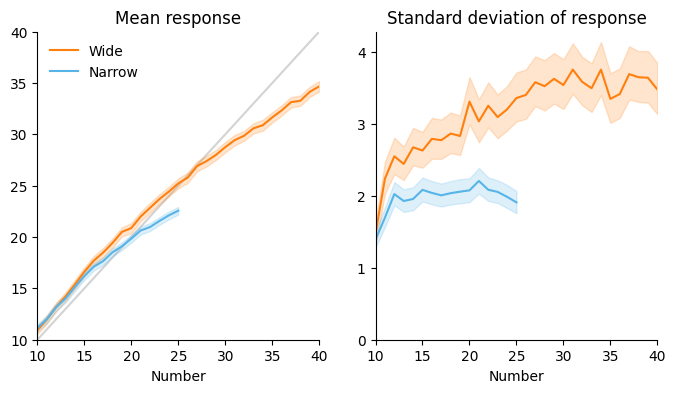

In [227]:
with_mse = False
fig, axs = subplots(ncols=2+with_mse, nrows=1, figsize=(4*(2+with_mse),4))

def plot_subjects_stan(axs):
    qties = ['m_0', 'sigma_0', ] # 'log_inv_var_0']
    if with_mse:
        qties.append('sqrt_mse')
    for iq, qty in enumerate(qties):
        ax = axs[iq]
        for cond in reversed(CONDITIONS):
            c = COLORS_COND[cond]
            xs = np.arange(10, MAX_COND[cond]+1, 1)
            # for subject in stan_subj_n.index.get_level_values('subject').unique():
            #     ax.plot(xs, stan_subj_n.loc[(subject, cond), qty[:-2]], c=c, alpha=.1)
            vs = []; vs_5 = []; vs_95 = []
            delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
            for j in range(1,delta+2):
                r = stan.loc[f'{qty}_{delta}[{j}]']
                vs.append( r['Mean'] )
                vs_5.append( r['5%'] )
                vs_95.append( r['95%'] )
            ax.plot(xs, vs, c=c, alpha=1., label=cond.capitalize())
            ax.fill_between(xs, vs_5, vs_95, color=c, alpha=.2)

plot_subjects_stan(axs.flat)
axs = axs.flat
axs[0].legend(loc='upper left')
#axs[0].set_ylabel('Response'); # $\hat x$
#axs[1].set_ylabel('Standard deviation of response');
axs[0].set_title('Mean response')
axs[1].set_title('Standard deviation of response')
if with_mse:
    axs[2].set_ylabel('$\sqrt{MSE} = \sqrt{bias^2 + variance}$');
for ax in axs: #.flatten():
    ax.set_xlim(10,40)
    #ax.set_xticks([30,40,50,60,70,80,90])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axs[1].set_ylim(0,None)
axs[1].set_yticks([0,1,2,3,4])
axs[0].set_ylim(10,40)
axs[0].axline((10,10), slope=1, c='lightgrey', zorder=-100)
# for ax in axs[:,0]:
#     ax.set_ylim(41,80)
#     ax.set_yticks([41,50,60,70,80])
#     ax.axline((60,60), slope=1, c='lightgrey', zorder=-1000)
# for ax in axs[:,1]:
#     ax.set_ylim(1.7,5.)
#     ax.set_yticks([2,3,4,5])
# for ax in axs[:,2]:
#     ax.set_ylim(2,11)
#     ax.set_yticks([2,4,6,8,10])
for ax in axs:
    ax.set_xlabel('Number') # $x$
#axs[1].set_xlim(13,22)
#fig.savefig(apc.todayDirPath() + '/subjects.pdf', bbox_inches='tight', transparent=False)

## fMRI

### Fisher information

In [32]:
fisher_info = pd.read_csv('decoding/fisher_information.tsv', sep='\t', index_col=[0, 1, 2, 3, 4, 5, 6, 8] ) #['fisher_information'] 
print( fisher_info.index.names )
print( fisher_info.index.get_level_values('fit_response').unique() )
print( fisher_info.index.get_level_values('smoothed').unique() )
#print( fisher_info.index.get_level_values('spherical_noise').unique() )
#print( fisher_info.index.get_level_values('separate_sigmas').unique() )
print( fisher_info.index.get_level_values('model_label').unique() )
fisher_info = fisher_info.droplevel('fit_response').droplevel('smoothed').droplevel('Unnamed: 0').droplevel(None) #.droplevel('spherical_noise') #.droplevel('model_label')
# print('!!! dropping separate_sigmas = True')
# fisher_info = index_filter(fisher_info, separate_sigmas=False)
#fisher_info['log_fi'] = np.log(fisher_info['fisher_information'])
fisher_info['sqrt_fi'] = np.sqrt(fisher_info['fisher_information'])
fisher_info['inv_fi'] = 1./(fisher_info['fisher_information'])
fisher_info['inv_sqrt_fi'] = 1./np.sqrt(fisher_info['fisher_information'])
fisher_info = fisher_info.rename(columns={'fisher_information': 'fi', 'log(fisher_information)': 'log_fi'})
fisher_info['log_n'] = np.log(fisher_info.index.get_level_values('n'))
fisher_info

['subject', 'model_label', 'fit_response', 'smoothed', None, 'Unnamed: 0', 'n', 'condition']
Index([False], dtype='bool', name='fit_response')
Index([True], dtype='bool', name='smoothed')
Index([31], dtype='int64', name='model_label')


fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n
subject model_label n    condition                                                               
1       31          10.0 narrow     6.035191  1.797608  2.456663  0.165695     0.407056  2.302585
                    11.0 narrow     3.724520  1.314938  1.929902  0.268491     0.518161  2.397895
                    12.0 narrow     1.117674  0.111250  1.057201  0.894715     0.945894  2.484907
                    13.0 narrow     1.006050  0.006032  1.003020  0.993986     0.996989  2.564949
                    14.0 narrow     0.460209 -0.776076  0.678387  2.172928     1.474085  2.639057
...                                      ...       ...       ...       ...          ...       ...
41      31          36.0 wide       0.273421 -1.296742  0.522897  3.657362     1.912423  3.583519
                    37.0 wide       0.255428 -1.364815  0.505399  3.914997     1.978635  3.610918
                    38.0 wide       0.238561 -1.433131  0.488427  4.191801     2.047389  3.637586
                    39.0 wide       0.222782 -1.501563  0.471997  4.488700     2.118655  3.663562
                    40.0 wide       0.208044 -1.570006  0.456118  4.806678     2.192414  3.688879

[2418 rows x 6 columns]

In [33]:
fisher_info_1518 = pd.read_csv('decoding/2025-06-26 fisher_information.tsv', sep='\t', index_col=[0, 1, 2, 3, 4, 5, 6, 8] ) #['fisher_information'] 
print( fisher_info_1518.index.get_level_values('fit_response').unique() )
print( fisher_info_1518.index.get_level_values('smoothed').unique() )
print( fisher_info_1518.index.get_level_values('spherical_noise').unique() )
print( fisher_info_1518.index.get_level_values('separate_sigmas').unique() )
print( fisher_info_1518.index.get_level_values('model_label').unique() )
fisher_info_1518 = fisher_info_1518.droplevel('fit_response').droplevel('smoothed').droplevel('spherical_noise') #.droplevel('model_label')
print('!!! dropping separate_sigmas = True')
fisher_info_1518 = index_filter(fisher_info_1518, separate_sigmas=False)
fisher_info_1518['log_fi'] = np.log(fisher_info_1518['fisher_information'])
fisher_info_1518['sqrt_fi'] = np.sqrt(fisher_info_1518['fisher_information'])
fisher_info_1518['inv_fi'] = 1./(fisher_info_1518['fisher_information'])
fisher_info_1518['inv_sqrt_fi'] = 1./np.sqrt(fisher_info_1518['fisher_information'])
fisher_info_1518 = fisher_info_1518.rename(columns={'fisher_information': 'fi'})
fisher_info_1518['log_n'] = np.log(fisher_info_1518.index.get_level_values('n'))
fisher_info_1518

Index([False], dtype='bool', name='fit_response')
Index([True], dtype='bool', name='smoothed')
Index([True], dtype='bool', name='spherical_noise')
Index([False, True], dtype='bool', name='separate_sigmas')
Index([15, 18], dtype='int64', name='model_label')
!!! dropping separate_sigmas = True


fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n
subject model_label n    condition                                                               
1       15          10.0 narrow     5.692601  1.739167  2.385917  0.175667     0.419126  2.302585
                    11.0 narrow     3.702477  1.309002  1.924182  0.270089     0.519701  2.397895
                    12.0 narrow     0.979151 -0.021069  0.989521  1.021293     1.010590  2.484907
                    13.0 narrow     1.185767  0.170390  1.088929  0.843336     0.918333  2.564949
                    14.0 narrow     0.537878 -0.620123  0.733402  1.859156     1.363509  2.639057
...                                      ...       ...       ...       ...          ...       ...
41      18          36.0 wide       0.278386 -1.278748  0.527623  3.592138     1.895294  3.583519
                    37.0 wide       0.260428 -1.345428  0.510322  3.839830     1.959548  3.610918
                    38.0 wide       0.243548 -1.412443  0.493505  4.105973     2.026320  3.637586
                    39.0 wide       0.227707 -1.479694  0.477187  4.391601     2.095615  3.663562
                    40.0 wide       0.212865 -1.547096  0.461373  4.697809     2.167443  3.688879

[3666 rows x 6 columns]

In [34]:
fisher_info.columns, fisher_info_1518.columns

(Index(['fi', 'log_fi', 'sqrt_fi', 'inv_fi', 'inv_sqrt_fi', 'log_n'], dtype='object'),
 Index(['fi', 'log_fi', 'sqrt_fi', 'inv_fi', 'inv_sqrt_fi', 'log_n'], dtype='object'))

In [35]:
fisher_info.index.names, fisher_info_1518.index.names

(FrozenList(['subject', 'model_label', 'n', 'condition']),
 FrozenList(['subject', 'model_label', 'n', 'condition']))

In [36]:
fisher_info = pd.concat([fisher_info, fisher_info_1518], )
fisher_info

fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n
subject model_label n    condition                                                               
1       31          10.0 narrow     6.035191  1.797608  2.456663  0.165695     0.407056  2.302585
                    11.0 narrow     3.724520  1.314938  1.929902  0.268491     0.518161  2.397895
                    12.0 narrow     1.117674  0.111250  1.057201  0.894715     0.945894  2.484907
                    13.0 narrow     1.006050  0.006032  1.003020  0.993986     0.996989  2.564949
                    14.0 narrow     0.460209 -0.776076  0.678387  2.172928     1.474085  2.639057
...                                      ...       ...       ...       ...          ...       ...
41      18          36.0 wide       0.278386 -1.278748  0.527623  3.592138     1.895294  3.583519
                    37.0 wide       0.260428 -1.345428  0.510322  3.839830     1.959548  3.610918
                    38.0 wide       0.243548 -1.412443  0.493505  4.105973     2.026320  3.637586
                    39.0 wide       0.227707 -1.479694  0.477187  4.391601     2.095615  3.663562
                    40.0 wide       0.212865 -1.547096  0.461373  4.697809     2.167443  3.688879

[6084 rows x 6 columns]

In [38]:
dats = []
for nstr in ['', '_narrowrange', '_1124', '_1223', '_1322']:
    a, b  = (-100,100) if nstr=='' else (10,25) if nstr == '_narrowrange' else (11,24) if nstr == '_1124' else (12,23) if nstr == '_1223' else (13,22)
    dats.append( index_filter(fisher_info, n=range(a, b+1)).groupby(['subject', 'model_label', 'condition' ]).mean() ) # 
fisher_info_avgs = pd.concat(dats, axis=0, keys=['all', 'narrowrange', '1124', '1223', '1322']).drop(columns=['log_n'])
fisher_info_avgs.index.names = ['subrange', 'subject', 'model_label', 'condition'] # 'model_label',
fisher_info_avgs

fi    log_fi   sqrt_fi     inv_fi  inv_sqrt_fi
subrange subject model_label condition                                                      
all      1       15          narrow     0.855621 -1.172242  0.706231   5.068577     2.080115
                             wide       0.251763 -2.447645  0.377351  18.130914     3.942094
                 18          narrow     0.843114 -1.413441  0.656623   6.623666     2.375812
                             wide       0.274819 -2.578914  0.368716  21.365276     4.262218
                 31          narrow     0.516915 -1.606773  0.541309   6.827314     2.467959
...                                          ...       ...       ...        ...          ...
1322     41      15          wide       0.701192 -0.361723  0.835927   1.444619     1.200130
                 18          narrow     2.052164  0.713177  1.430516   0.493025     0.701097
                             wide       0.666308 -0.407681  0.815933   1.505791     1.226607
                 31          narrow     1.587406  0.455942  1.258020   0.638048     0.797441
                             wide       0.772112 -0.283385  0.873105   1.356512     1.158676

[1170 rows x 5 columns]

In [39]:
fisher_info_avgs_deltas = (index_filter(fisher_info_avgs, condition=WIDE) - index_filter(fisher_info_avgs, condition=NARROW)).add_suffix('_delta_wn')
fisher_info_avgs_deltas

fi_delta_wn  log_fi_delta_wn  sqrt_fi_delta_wn  inv_fi_delta_wn  inv_sqrt_fi_delta_wn
subrange subject model_label                                                                                       
all      1       15             -0.603858        -1.275403         -0.328880        13.062337              1.861979
                 18             -0.568295        -1.165473         -0.287907        14.741609              1.886406
                 31             -0.243635        -0.661894         -0.140797         7.439760              1.063984
         2       15             -0.067489        -0.678275         -0.104880         8.066872              1.143553
                 18             -0.063444        -0.715131         -0.104180         9.804793              1.288462
...                                   ...              ...               ...              ...                   ...
1322     40      18             -0.084845        -1.425479         -0.142589       117.164516              5.463195
                 31             -0.014305        -0.475928         -0.041205        22.762243              1.536526
         41      15             -1.275781        -1.038396         -0.568427         0.933682              0.486266
                 18             -1.385856        -1.120858         -0.614584         1.012767              0.525510
                 31             -0.815294        -0.739327         -0.384916         0.718464              0.361235

[585 rows x 5 columns]

In [40]:
fisher_info

fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n
subject model_label n    condition                                                               
1       31          10.0 narrow     6.035191  1.797608  2.456663  0.165695     0.407056  2.302585
                    11.0 narrow     3.724520  1.314938  1.929902  0.268491     0.518161  2.397895
                    12.0 narrow     1.117674  0.111250  1.057201  0.894715     0.945894  2.484907
                    13.0 narrow     1.006050  0.006032  1.003020  0.993986     0.996989  2.564949
                    14.0 narrow     0.460209 -0.776076  0.678387  2.172928     1.474085  2.639057
...                                      ...       ...       ...       ...          ...       ...
41      18          36.0 wide       0.278386 -1.278748  0.527623  3.592138     1.895294  3.583519
                    37.0 wide       0.260428 -1.345428  0.510322  3.839830     1.959548  3.610918
                    38.0 wide       0.243548 -1.412443  0.493505  4.105973     2.026320  3.637586
                    39.0 wide       0.227707 -1.479694  0.477187  4.391601     2.095615  3.663562
                    40.0 wide       0.212865 -1.547096  0.461373  4.697809     2.167443  3.688879

[6084 rows x 6 columns]

In [41]:
fisher_info_deltas = ( index_filter(fisher_info, condition=WIDE ) - index_filter(fisher_info, condition=NARROW) ).drop(columns=['log_n']).add_suffix('_diff')
fisher_info_deltas['log_n'] = np.log(fisher_info_deltas.index.get_level_values('n'))
fisher_info_deltas

fi_diff  log_fi_diff  sqrt_fi_diff  inv_fi_diff  inv_sqrt_fi_diff     log_n
subject model_label n                                                                                 
1       15          10.0 -4.517753    -1.578028     -1.302013     0.675507          0.503465  2.302585
                    11.0 -1.851967    -0.693541     -0.563848     0.270302          0.215412  2.397895
                    12.0  0.759647     0.574263      0.329114    -0.446183         -0.252230  2.484907
                    13.0 -0.642712    -0.780934     -0.352006     0.998097          0.438661  2.564949
                    14.0 -0.162006    -0.358384     -0.120318     0.801324          0.267589  2.639057
...                            ...          ...           ...          ...               ...       ...
41      31          36.0  0.004423     0.016310      0.004247    -0.060139         -0.015659  3.583519
                    37.0  0.014591     0.058820      0.014647    -0.237189         -0.059056  3.610918
                    38.0  0.022645     0.099737      0.023760    -0.439636         -0.104689  3.637586
                    39.0  0.028919     0.139042      0.031699    -0.669591         -0.152532  3.663562
                    40.0  0.033701     0.176723      0.038574    -0.929131         -0.202541  3.688879

[3627 rows x 6 columns]

### Decoding quantities

In [42]:
fmri_estimates_stats = pd.read_csv('decoding/expected_uncertainty.tsv', sep='\t', index_col=[0, 1, 2, 3, 4, 5, 6] )
#fmri_estimates_stats = pd.read_csv('decoding/2025-07-24 expected_uncertainty.tsv', sep='\t', index_col=[0, 1, 2, 3, 4, 5, ] )
# #print( fmri_estimates_stats.index.get_level_values('spherical_noise').unique() )
print( fmri_estimates_stats.index.get_level_values('smoothed').unique() )
print( fmri_estimates_stats.index.get_level_values('fit_response').unique() )
print( fmri_estimates_stats.index.get_level_values('model_label').unique() )
fmri_estimates_stats.index = fmri_estimates_stats.index.droplevel(['smoothed', 'fit_response',] ).rename({'range': 'condition'}) # 'spherical_noise',  'model_label'
fmri_estimates_stats['sigma'] = np.sqrt( fmri_estimates_stats.var_E )
fmri_estimates_stats['bias'] = fmri_estimates_stats.mean_E - fmri_estimates_stats.index.get_level_values('n')
fmri_estimates_stats['log_var'] = np.log(fmri_estimates_stats.var_E)
fmri_estimates_stats['log_n'] = np.log(fmri_estimates_stats.index.get_level_values('n'))
if 'wide_prior' not in fmri_estimates_stats.index.names:
    fmri_estimates_stats = fmri_estimates_stats.set_index(pd.Index([True]*len(fmri_estimates_stats), name='wide_prior'), append=True)
    fmri_estimates_stats = fmri_estimates_stats.reorder_levels(['subject', 'model_label', 'wide_prior', 'condition', 'n'], axis=0)
fmri_estimates_stats

Index([True], dtype='bool', name='smoothed')
Index([False], dtype='bool', name='fit_response')
Index([31], dtype='int64', name='model_label')


mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide_prior condition n                                                                                            
1       31          False      narrow    10.0  10.497773    0.497774  1.135848        0.497774  1.065762  0.497773  0.127380  2.302585
                                         11.0  11.106773    0.106774  0.225290        0.164888  0.474647  0.106773 -1.490367  2.397895
                                         12.0  12.152911    0.152911  0.320103        0.280951  0.565777  0.152911 -1.139112  2.484907
                                         13.0  13.158963    0.158963  0.735248        0.526162  0.857466  0.158963 -0.307547  2.564949
                                         14.0  14.232490    0.232489  0.641316        0.594400  0.800822  0.232490 -0.444234  2.639057
...                                                  ...         ...       ...             ...       ...       ...       ...       ...
41      31          True       wide      36.0  35.989860   -0.010141  0.394477        0.475371  0.628074 -0.010140 -0.930194  3.583519
                                         37.0  36.994663   -0.005337  0.432053        0.496666  0.657308 -0.005337 -0.839206  3.610918
                                         38.0  37.933020   -0.066975  0.400793        0.469463  0.633082 -0.066980 -0.914310  3.637586
                                         39.0  38.805088   -0.194910  0.317602        0.424634  0.563562 -0.194912 -1.146957  3.663562
                                         40.0  39.474987   -0.525012  0.239361        0.525012  0.489245 -0.525013 -1.429782  3.688879

[3666 rows x 8 columns]

In [43]:
fmri_estimates_stats.index.names

FrozenList(['subject', 'model_label', 'wide_prior', 'condition', 'n'])

In [44]:
fmri_estimates_stats_1518 = pd.read_csv('decoding/2025-07-16 expected_error_pars.tsv', sep='\t', index_col=[0, 1, 2, 3, 4, 5, 6, ] )
print( fmri_estimates_stats_1518.index.get_level_values('spherical_noise').unique() )
print( fmri_estimates_stats_1518.index.get_level_values('smoothed').unique() )
print( fmri_estimates_stats_1518.index.get_level_values('fit_response').unique() )
print( fmri_estimates_stats_1518.index.get_level_values('model_label').unique() )
fmri_estimates_stats_1518.index = fmri_estimates_stats_1518.index.droplevel(['smoothed', 'fit_response', 'spherical_noise',] ).rename({'range': 'condition'}) # 
fmri_estimates_stats_1518['sigma'] = np.sqrt( fmri_estimates_stats_1518.var_E )
fmri_estimates_stats_1518['bias'] = fmri_estimates_stats_1518.mean_E - fmri_estimates_stats_1518.index.get_level_values('n')
fmri_estimates_stats_1518['log_var'] = np.log(fmri_estimates_stats_1518.var_E)
fmri_estimates_stats_1518['log_n'] = np.log(fmri_estimates_stats_1518.index.get_level_values('n'))
fmri_estimates_stats_1518
# add index level in the MultiIndex, named "wide_prior", and with value False for all rows
fmri_estimates_stats_1518 = fmri_estimates_stats_1518.set_index(pd.Index([False]*len(fmri_estimates_stats_1518), name='wide_prior'), append=True)
# reorder the index levels to have 'wide_prior' as the third level
fmri_estimates_stats_1518 = fmri_estimates_stats_1518.reorder_levels(fmri_estimates_stats.index.names, axis=0)
fmri_estimates_stats_1518

Index([True], dtype='bool', name='spherical_noise')
Index([True], dtype='bool', name='smoothed')
Index([False], dtype='bool', name='fit_response')
Index([15, 18], dtype='int64', name='model_label')


/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide_prior condition n                                                                                            
1       15          False      narrow    10.0  10.611801    0.611800  1.425448        0.611800  1.193921  0.611801  0.354486  2.302585
                                         11.0  11.137037    0.137037  0.243799        0.190036  0.493760  0.137037 -1.411413  2.397895
                                         12.0  12.139342    0.139343  0.358819        0.279343  0.599015  0.139342 -1.024939  2.484907
                                         13.0  13.040127    0.040127  0.605830        0.476747  0.778351  0.040127 -0.501155  2.564949
                                         14.0  14.287040    0.287040  0.827021        0.657156  0.909407  0.287040 -0.189925  2.639057
...                                                  ...         ...       ...             ...       ...       ...       ...       ...
40      18          False      wide      21.0  20.284681   -0.715318  1.085669        0.888804  1.041954 -0.715319  0.082196  3.044522
                                         22.0  20.323923   -1.676076  1.244854        1.710050  1.115730 -1.676077  0.219018  3.091042
                                         23.0  20.410765   -2.589235  1.564157        2.591409  1.250663 -2.589235  0.447347  3.135494
                                         24.0  20.319063   -3.680938  2.342525        3.680938  1.530531 -3.680937  0.851229  3.178054
                                         25.0  20.261852   -4.738148  3.050201        4.738148  1.746482 -4.738148  1.115207  3.218876

[2432 rows x 8 columns]

In [45]:
fmri_estimates_stats.columns, fmri_estimates_stats_1518.columns

(Index(['mean_E', 'mean_error', 'var_E', 'mean_abs_error', 'sigma', 'bias', 'log_var', 'log_n'], dtype='object'),
 Index(['mean_E', 'mean_error', 'var_E', 'mean_abs_error', 'sigma', 'bias', 'log_var', 'log_n'], dtype='object'))

In [46]:
fmri_estimates_stats.index.names, fmri_estimates_stats_1518.index.names

(FrozenList(['subject', 'model_label', 'wide_prior', 'condition', 'n']),
 FrozenList(['subject', 'model_label', 'wide_prior', 'condition', 'n']))

In [47]:
fmri_estimates_stats.index.get_level_values('subject').unique(), fmri_estimates_stats_1518.index.get_level_values('subject').unique()

(Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject'),
 Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40], dtype='int64', name='subject'))

In [48]:
# concatenate the two dataframes. 
fmri_estimates_stats = pd.concat([fmri_estimates_stats, fmri_estimates_stats_1518], axis=0)
fmri_estimates_stats


mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide_prior condition n                                                                                            
1       31          False      narrow    10.0  10.497773    0.497774  1.135848        0.497774  1.065762  0.497773  0.127380  2.302585
                                         11.0  11.106773    0.106774  0.225290        0.164888  0.474647  0.106773 -1.490367  2.397895
                                         12.0  12.152911    0.152911  0.320103        0.280951  0.565777  0.152911 -1.139112  2.484907
                                         13.0  13.158963    0.158963  0.735248        0.526162  0.857466  0.158963 -0.307547  2.564949
                                         14.0  14.232490    0.232489  0.641316        0.594400  0.800822  0.232490 -0.444234  2.639057
...                                                  ...         ...       ...             ...       ...       ...       ...       ...
40      18          False      wide      21.0  20.284681   -0.715318  1.085669        0.888804  1.041954 -0.715319  0.082196  3.044522
                                         22.0  20.323923   -1.676076  1.244854        1.710050  1.115730 -1.676077  0.219018  3.091042
                                         23.0  20.410765   -2.589235  1.564157        2.591409  1.250663 -2.589235  0.447347  3.135494
                                         24.0  20.319063   -3.680938  2.342525        3.680938  1.530531 -3.680937  0.851229  3.178054
                                         25.0  20.261852   -4.738148  3.050201        4.738148  1.746482 -4.738148  1.115207  3.218876

[6098 rows x 8 columns]

In [49]:
index_filter(fmri_estimates_stats, subject=41)

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
model_label wide_prior condition n                                                                                            
31          False      narrow    10.0  10.038330    0.038330  0.020522        0.038330  0.143257  0.038330 -3.886236  2.302585
                                 11.0  11.036518    0.036519  0.036793        0.068810  0.191816  0.036518 -3.302437  2.397895
                                 12.0  12.018329    0.018329  0.063388        0.113615  0.251769  0.018329 -2.758486  2.484907
                                 13.0  12.997161   -0.002839  0.086362        0.145320  0.293875 -0.002839 -2.449202  2.564949
                                 14.0  13.974835   -0.025165  0.093509        0.134896  0.305792 -0.025165 -2.369700  2.639057
...                                          ...         ...       ...             ...       ...       ...       ...       ...
            True       wide      36.0  35.989860   -0.010141  0.394477        0.475371  0.628074 -0.010140 -0.930194  3.583519
                                 37.0  36.994663   -0.005337  0.432053        0.496666  0.657308 -0.005337 -0.839206  3.610918
                                 38.0  37.933020   -0.066975  0.400793        0.469463  0.633082 -0.066980 -0.914310  3.637586
                                 39.0  38.805088   -0.194910  0.317602        0.424634  0.563562 -0.194912 -1.146957  3.663562
                                 40.0  39.474987   -0.525012  0.239361        0.525012  0.489245 -0.525013 -1.429782  3.688879

[94 rows x 8 columns]

In [50]:
fmri_estimates_deltas = ( index_filter(fmri_estimates_stats, condition=WIDE ) - index_filter(fmri_estimates_stats, condition=NARROW) ).drop(columns=['log_n']).add_suffix('_diff')
fmri_estimates_deltas['log_n'] = np.log(fmri_estimates_deltas.index.get_level_values('n'))
fmri_estimates_deltas

mean_E_diff  mean_error_diff  var_E_diff  mean_abs_error_diff  sigma_diff  bias_diff  log_var_diff     log_n
subject model_label wide_prior n                                                                                                                 
1       31          False      10.0    -0.149253        -0.149253    0.184640            -0.149253    0.083363  -0.149253      0.150622  2.302585
                               11.0     0.085628         0.085627    0.277683             0.050928    0.234558   0.085628      0.803148  2.397895
                               12.0     0.070600         0.070600    0.155371             0.060335    0.123770   0.070600      0.395669  2.484907
                               13.0     0.206186         0.206187   -0.053970             0.008114   -0.032070   0.206186     -0.076237  2.564949
                               14.0    -0.066757        -0.066756    0.188810            -0.009392    0.110290  -0.066757      0.258055  2.639057
...                                          ...              ...         ...                  ...         ...        ...           ...       ...
40      18          False      21.0     0.752501         0.752501   -2.360003            -0.807252   -0.814298   0.752501     -1.154923  3.044522
                               22.0    -0.335187        -0.335186   -2.614493             0.134436   -0.848792  -0.335187     -1.131480  3.091042
                               23.0    -1.267820        -1.267820   -3.599159             1.051671   -1.021631  -1.267820     -1.194232  3.135494
                               24.0    -2.328743        -2.328745   -3.016031             2.195038   -0.784325  -2.328743     -0.827465  3.178054
                               25.0    -2.806397        -2.806396   -5.968720             2.806396   -1.256669  -2.806397     -1.084117  3.218876

[3049 rows x 8 columns]

In [51]:
#index_filter(fmri_estimates_stats, subject=1, wide_prior=True, condition=NARROW)

In [263]:
dats = []
for nstr in ['', '_narrowrange', '_1124', '_1223', '_1322', '_1139', '_1238', '_1337']:
    #a, b  = (-100,100) if nstr=='' else (10,25) if nstr == '_narrowrange' else (11,24) if nstr == '_1124' else (12,23) if nstr == '_1223' else (13,22)
    a, b  = (-100,100) if nstr=='' else (10,25) if nstr == '_narrowrange' else (int(nstr[1:3]),int(nstr[3:5])) 
    dats.append( index_filter(fmri_estimates_stats.drop(columns=['log_n']), n=range(a, b+1)).groupby(['subject', 'wide_prior', 'condition', 'model_label', ]).mean() ) # 
fmri_estimates_avgs = pd.concat(dats, axis=0, keys=['all', 'narrowrange', '1124', '1223', '1322', '1139', '1238', '1337'])
fmri_estimates_avgs.index.names = ['subrange', 'subject', 'wide_prior', 'condition', 'model_label',]
fmri_estimates_avgs

mean_E  mean_error      var_E  mean_abs_error     sigma      bias   log_var
subrange subject wide_prior condition model_label                                                                                
all      1       False      narrow    15           17.500120    0.000120   0.846384        0.644334  0.900933  0.000120 -0.258407
                                      18           17.488188   -0.011812   0.927790        0.717525  0.950007 -0.011812 -0.137512
                                      31           17.492390   -0.007611   0.699289        0.577567  0.821504 -0.007610 -0.434774
                            wide      15           17.479056   -0.020944   1.530476        0.887792  1.209011 -0.020944  0.329207
                                      18           17.481986   -0.018013   1.444085        0.891383  1.180976 -0.018014  0.292836
...                                                      ...         ...        ...             ...       ...       ...       ...
1337     40      True       wide      31           25.015760    0.015760  10.041856        2.405318  2.993028  0.015760  2.061274
         41      False      narrow    31           18.984302   -0.015698   0.072039        0.124533  0.267680 -0.015698 -2.641214
                            wide      31           18.978475   -0.021524   0.190849        0.287044  0.434827 -0.021525 -1.675699
                 True       narrow    31           25.013903    0.013903   0.178146        0.240751  0.398938  0.013903 -1.950776
                            wide      31           25.010224    0.010223   0.282237        0.359255  0.526491  0.010224 -1.300689

[2464 rows x 7 columns]

Text(0, 0.5, 'sigma Model 31')

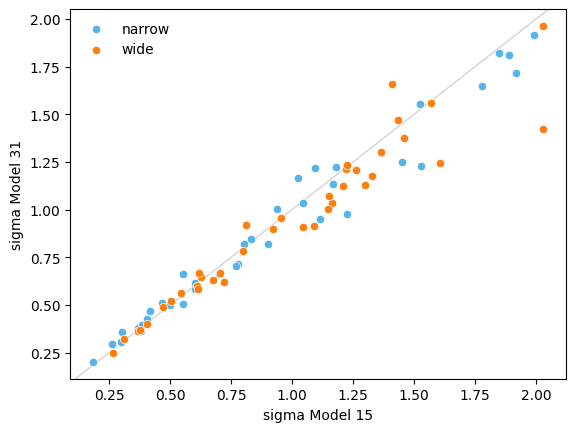

In [264]:
for cond in CONDITIONS:
    xxx = index_filter(fmri_estimates_avgs, subrange='narrowrange', model_label=15, condition=cond, wide_prior=False).sigma
    yyy = index_filter(fmri_estimates_avgs, subrange='narrowrange', model_label=31, condition=cond, wide_prior=False).sigma
    sns.scatterplot(x=xxx, y=yyy, c=COLORS_COND[cond], label=cond,)
axline((1,1), slope=1, color='lightgrey', lw=1, zorder=-1000)
plt.xlabel('sigma Model 15')
plt.ylabel('sigma Model 31')

In [265]:
index_filter(fmri_estimates_stats, wide_prior=True, model_label=31)

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject condition n                                                                                            
1       narrow    10.0  10.476123    0.476123  1.055120        0.476123  1.027190  0.476123  0.053655  2.302585
                  11.0  11.102278    0.102277  0.226197        0.161752  0.475602  0.102278 -1.486347  2.397895
                  12.0  12.135842    0.135843  0.222560        0.270570  0.471763  0.135842 -1.502556  2.484907
                  13.0  13.167693    0.167693  0.601260        0.497615  0.775410  0.167693 -0.508727  2.564949
                  14.0  14.264460    0.264460  0.627663        0.598814  0.792252  0.264460 -0.465753  2.639057
...                           ...         ...       ...             ...       ...       ...       ...       ...
41      wide      36.0  35.989860   -0.010141  0.394477        0.475371  0.628074 -0.010140 -0.930194  3.583519
                  37.0  36.994663   -0.005337  0.432053        0.496666  0.657308 -0.005337 -0.839206  3.610918
                  38.0  37.933020   -0.066975  0.400793        0.469463  0.633082 -0.066980 -0.914310  3.637586
                  39.0  38.805088   -0.194910  0.317602        0.424634  0.563562 -0.194912 -1.146957  3.663562
                  40.0  39.474987   -0.525012  0.239361        0.525012  0.489245 -0.525013 -1.429782  3.688879

[2418 rows x 8 columns]

In [266]:
fmri_ests_avgs_deltas = ( index_filter(fmri_estimates_avgs, condition='wide') - index_filter(fmri_estimates_avgs, condition='narrow') ).add_suffix('_diff')
fmri_ests_avgs_deltas

mean_E_diff  mean_error_diff  var_E_diff  mean_abs_error_diff  sigma_diff  bias_diff  log_var_diff
subrange subject wide_prior model_label                                                                                                    
all      1       False      15             -0.021064        -0.021064    0.684092             0.243458    0.308078  -0.021064      0.587614
                            18             -0.006202        -0.006201    0.516294             0.173858    0.230969  -0.006202      0.430348
                            31             -0.026616        -0.026616    0.620749             0.251902    0.304715  -0.026616      0.625707
                 True       31             -0.014349        -0.014349    1.214108             0.330676    0.485950  -0.014349      0.816711
         2       False      15             -0.071168        -0.071167    1.160393             0.300292    0.455214  -0.071168      0.751102
...                                              ...              ...         ...                  ...         ...        ...           ...
1337     40      False      18              0.082391         0.082392   -1.045301             0.530153   -0.217893   0.082391     -0.133399
                            31              0.259091         0.259092   -0.729226             0.065641   -0.184626   0.259091     -0.160693
                 True       31              0.176705         0.176704    8.014372             1.325132    1.634587   0.176705      1.539645
         41      False      31             -0.005827        -0.005826    0.118810             0.162511    0.167148  -0.005827      0.965516
                 True       31             -0.003679        -0.003680    0.104091             0.118504    0.127553  -0.003679      0.650087

[1232 rows x 7 columns]

In [267]:
fmri_estimates_stats

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide_prior condition n                                                                                            
1       31          False      narrow    10.0  10.497773    0.497774  1.135848        0.497774  1.065762  0.497773  0.127380  2.302585
                                         11.0  11.106773    0.106774  0.225290        0.164888  0.474647  0.106773 -1.490367  2.397895
                                         12.0  12.152911    0.152911  0.320103        0.280951  0.565777  0.152911 -1.139112  2.484907
                                         13.0  13.158963    0.158963  0.735248        0.526162  0.857466  0.158963 -0.307547  2.564949
                                         14.0  14.232490    0.232489  0.641316        0.594400  0.800822  0.232490 -0.444234  2.639057
...                                                  ...         ...       ...             ...       ...       ...       ...       ...
40      18          False      wide      21.0  20.284681   -0.715318  1.085669        0.888804  1.041954 -0.715319  0.082196  3.044522
                                         22.0  20.323923   -1.676076  1.244854        1.710050  1.115730 -1.676077  0.219018  3.091042
                                         23.0  20.410765   -2.589235  1.564157        2.591409  1.250663 -2.589235  0.447347  3.135494
                                         24.0  20.319063   -3.680938  2.342525        3.680938  1.530531 -3.680937  0.851229  3.178054
                                         25.0  20.261852   -4.738148  3.050201        4.738148  1.746482 -4.738148  1.115207  3.218876

[6098 rows x 8 columns]

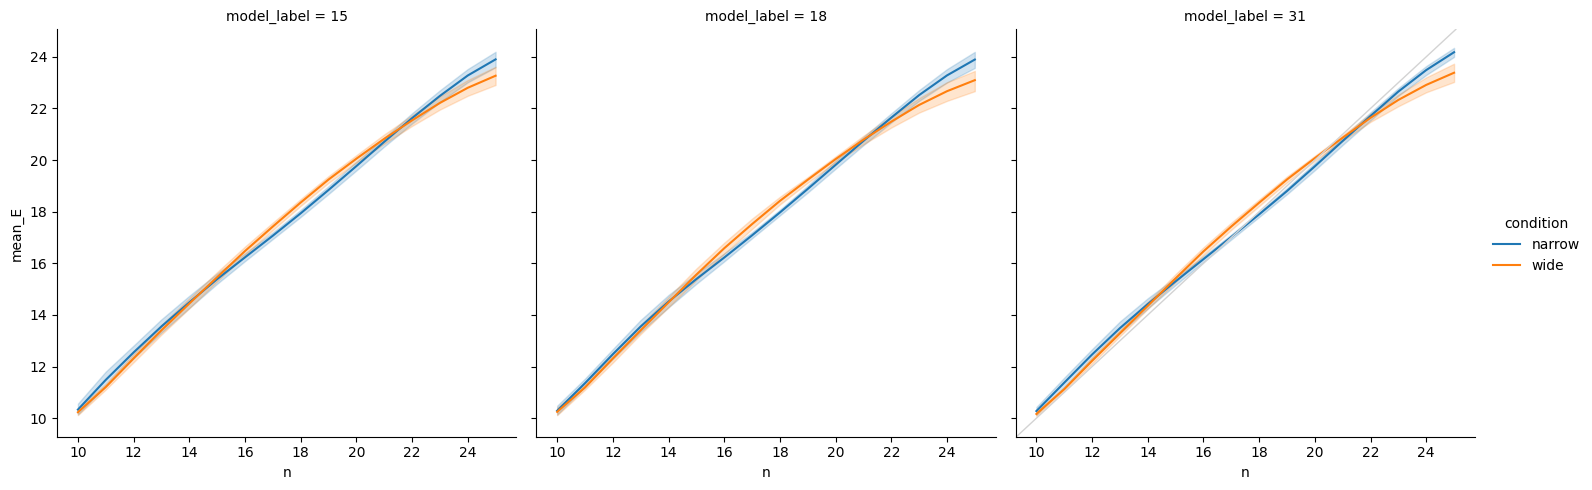

In [268]:
sns.relplot(index_filter(fmri_estimates_stats, wide_prior=False), x='n', y='mean_E', hue='condition', kind='line', col='model_label', ) # , model_label=15
axline((10,10), slope=1, color='lightgrey', lw=1)

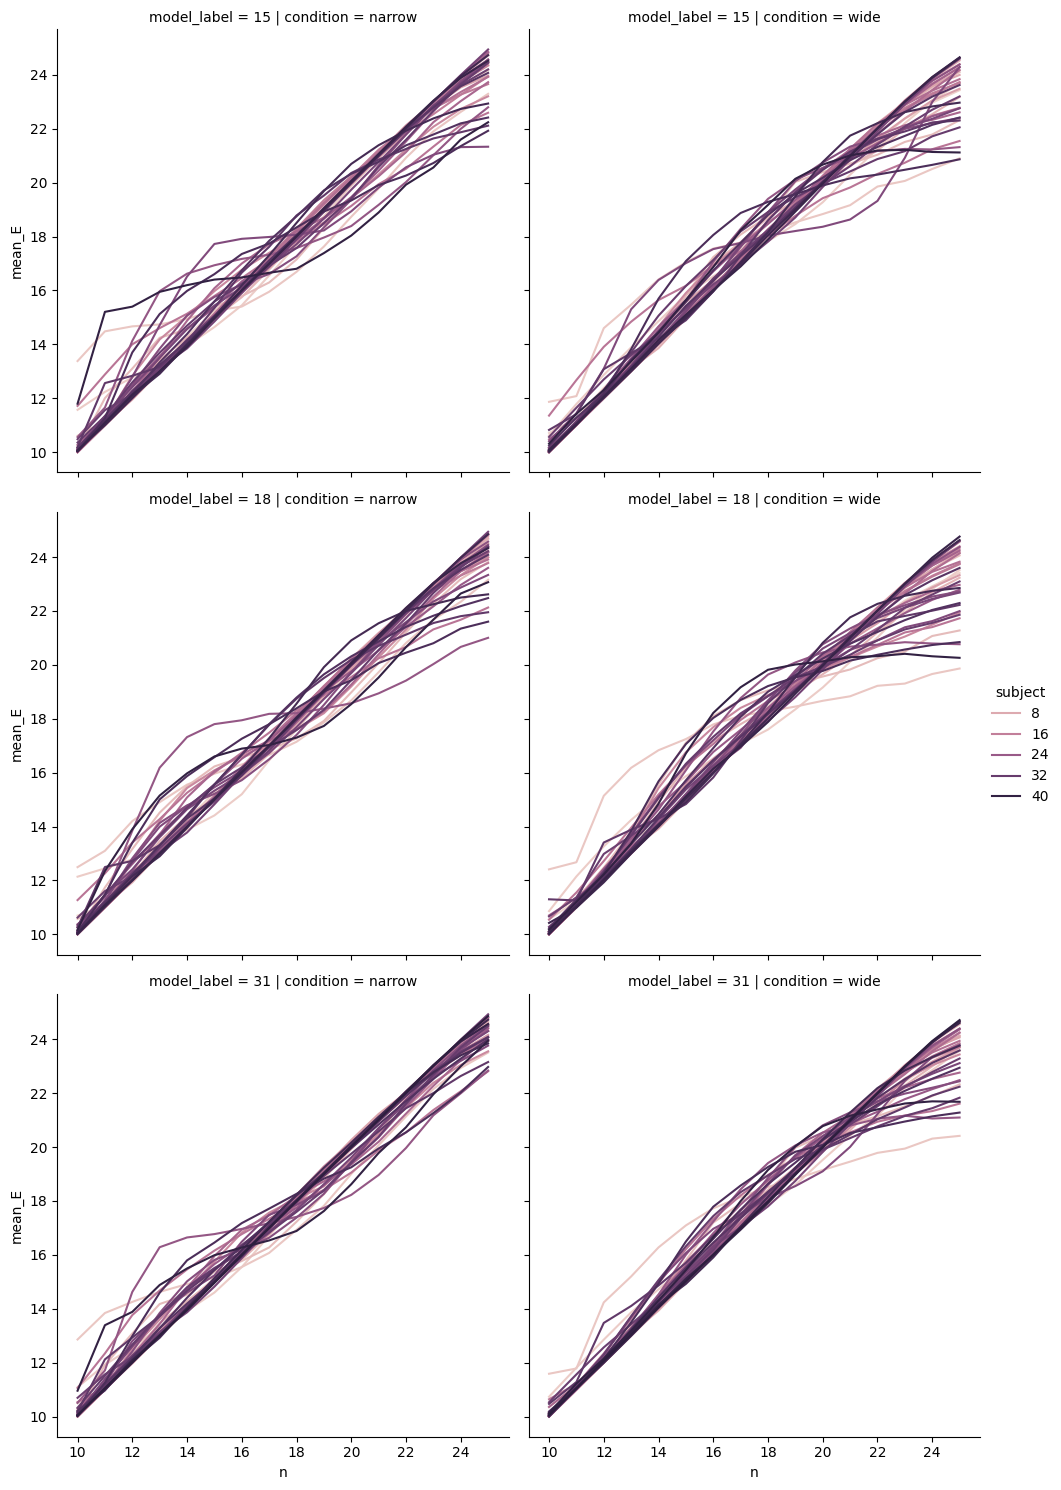

In [269]:
sns.relplot(index_filter(fmri_estimates_stats, wide_prior=False), x='n', y='mean_E', hue='subject', kind='line', col='condition', row='model_label') # model_label=15

### fMRI - trial responses

In [59]:
fmri_trial_resps = pd.read_csv('decoding/decoding_pars.tsv', delimiter='\t',) # index_col=[0,1,2,3])
fmri_trial_resps = fmri_trial_resps.drop(columns=['session', 'run', 'trial_nr', 'onset', 'phase', 'nr_frames', 'jitter', 'start_marker_position', 'onset_abs', 'duration'])
fmri_trial_resps = fmri_trial_resps.rename(columns={'range':'condition'})
fmri_trial_resps = fmri_trial_resps.set_index(['spherical_noise', 'subject', 'condition'])
fmri_trial_resps['t'] = fmri_trial_resps.groupby(level=['spherical_noise', 'subject', 'condition']).cumcount() + 1
fmri_trial_resps.set_index('t', append=True, inplace=True)
fmri_trial_resps = fmri_trial_resps.sort_index()
fmri_trial_resps

response     n  response_time  error  abs_error  squared_error          E        sd   E_narrow     E_wide  sd_narrow   sd_wide  \
spherical_noise subject condition t                                                                                                                                     
False           1       narrow    1         NaN  11.0            NaN    NaN        NaN            NaN  17.537264  5.247544  17.537264  28.895398   5.247544  6.506345   
                                  2        19.0  23.0       1.317963   -4.0        4.0           16.0  18.092014  2.777531  18.092014  22.410648   2.777531  6.116189   
                                  3        25.0  23.0       0.834244    2.0        2.0            4.0  17.128694  3.821620  17.128694  26.572495   3.821620  7.904282   
                                  4        24.0  22.0       1.701381    2.0        2.0            4.0  13.736838  2.043997  13.736838  14.762215   2.043997  3.323689   
                                  5        17.0  21.0       2.018881   -4.0        4.0           16.0  13.780057  2.001030  13.780057  14.782096   2.001030  3.248581   
...                                         ...   ...            ...    ...        ...            ...        ...       ...        ...        ...        ...       ...   
True            41      wide      236      29.0  24.0       0.283771    5.0        5.0           25.0  12.409954  0.526706  12.409954  12.409954   0.526706  0.526706   
                                  237      39.0  34.0       0.930894    5.0        5.0           25.0  39.976022  0.046817        NaN  39.976022        NaN  0.046817   
                                  238      39.0  32.0       0.817487    7.0        7.0           49.0  39.986598  0.026446        NaN  39.986598        NaN  0.026446   
                                  239      10.0  10.0       1.501680    0.0        0.0            0.0  20.269931  0.700548  20.269931  20.269931   0.700548  0.700548   
                                  240      29.0  24.0       2.085694    5.0        5.0           25.0  15.565216  0.621741  15.565216  15.565216   0.621741  0.621741   

                                      E_median_split sd_median_split  
spherical_noise subject condition t                                   
False           1       narrow    1              low            high  
                                  2              low             low  
                                  3              low            high  
                                  4              low             low  
                                  5              low             low  
...                                              ...             ...  
True            41      wide      236            low             low  
                                  237           high             low  
                                  238           high             low  
                                  239            low            high  
                                  240           high            high  

[37440 rows x 14 columns]

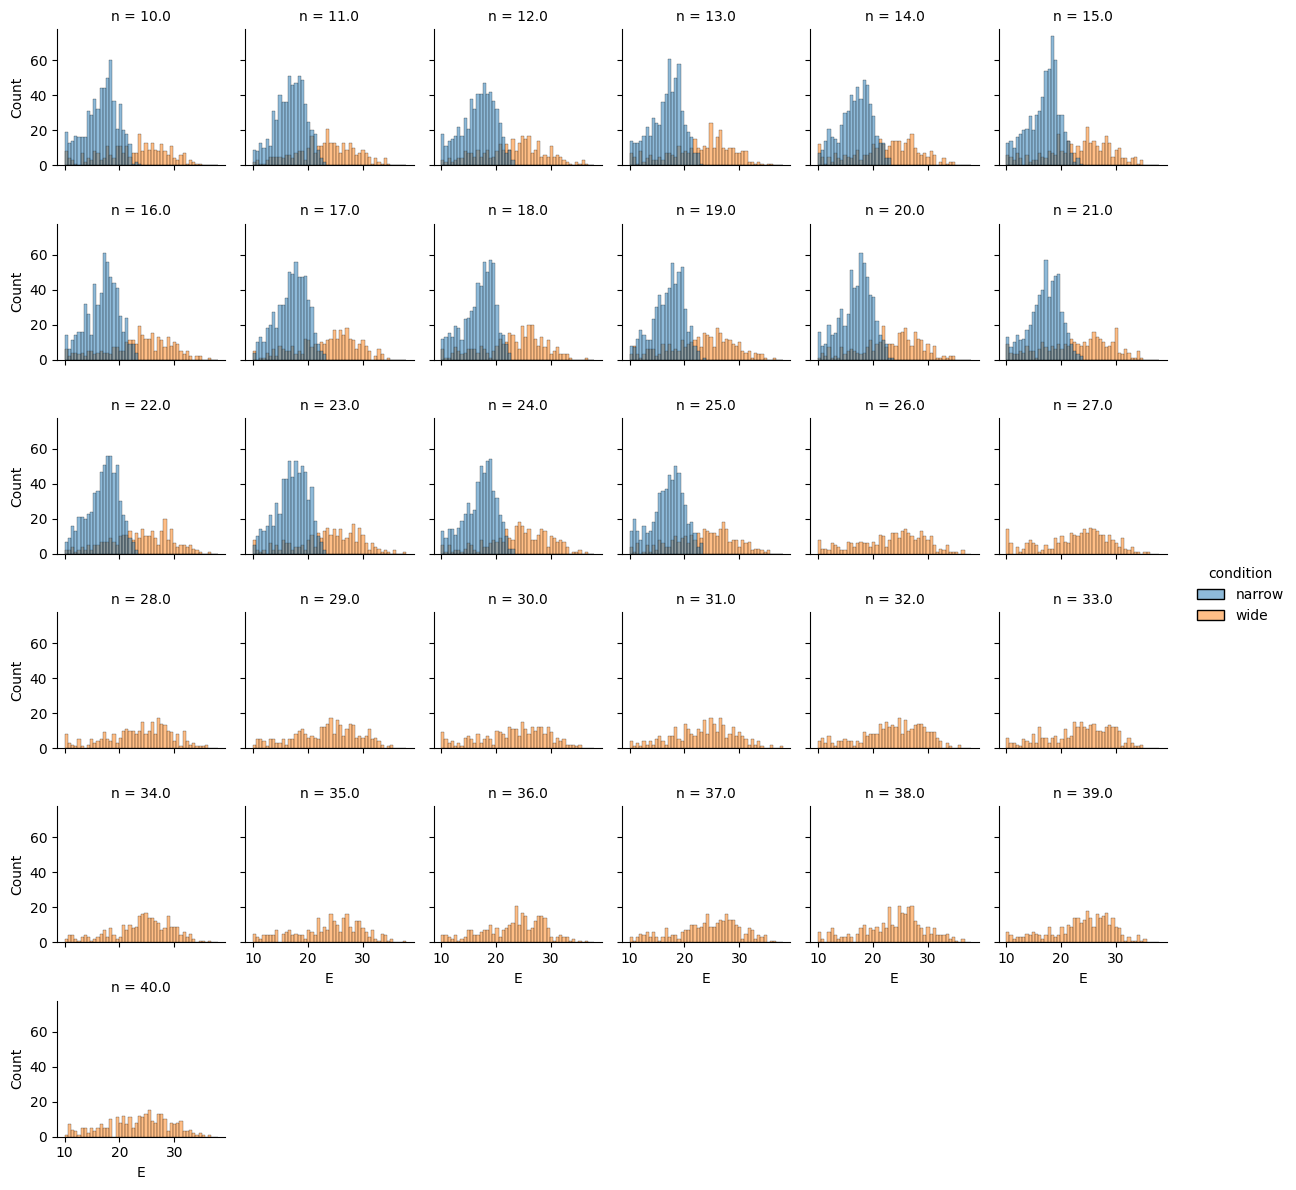

In [60]:
sns.displot(index_filter(fmri_trial_resps, spherical_noise=False), x='E', hue='condition', col='n', col_wrap=6, height=2 )

In [61]:
pg.corr(fmri_trial_resps.response - fmri_trial_resps.n, fmri_trial_resps.E- fmri_trial_resps.n)

,n,r,CI95%,p-val,BF10,power
pearson,36632,0.344781,"[0.34, 0.35]",0.0,inf,1.0


In [62]:
fmri_trial_resps

response     n  response_time  error  abs_error  squared_error          E        sd   E_narrow     E_wide  sd_narrow   sd_wide  \
spherical_noise subject condition t                                                                                                                                     
False           1       narrow    1         NaN  11.0            NaN    NaN        NaN            NaN  17.537264  5.247544  17.537264  28.895398   5.247544  6.506345   
                                  2        19.0  23.0       1.317963   -4.0        4.0           16.0  18.092014  2.777531  18.092014  22.410648   2.777531  6.116189   
                                  3        25.0  23.0       0.834244    2.0        2.0            4.0  17.128694  3.821620  17.128694  26.572495   3.821620  7.904282   
                                  4        24.0  22.0       1.701381    2.0        2.0            4.0  13.736838  2.043997  13.736838  14.762215   2.043997  3.323689   
                                  5        17.0  21.0       2.018881   -4.0        4.0           16.0  13.780057  2.001030  13.780057  14.782096   2.001030  3.248581   
...                                         ...   ...            ...    ...        ...            ...        ...       ...        ...        ...        ...       ...   
True            41      wide      236      29.0  24.0       0.283771    5.0        5.0           25.0  12.409954  0.526706  12.409954  12.409954   0.526706  0.526706   
                                  237      39.0  34.0       0.930894    5.0        5.0           25.0  39.976022  0.046817        NaN  39.976022        NaN  0.046817   
                                  238      39.0  32.0       0.817487    7.0        7.0           49.0  39.986598  0.026446        NaN  39.986598        NaN  0.026446   
                                  239      10.0  10.0       1.501680    0.0        0.0            0.0  20.269931  0.700548  20.269931  20.269931   0.700548  0.700548   
                                  240      29.0  24.0       2.085694    5.0        5.0           25.0  15.565216  0.621741  15.565216  15.565216   0.621741  0.621741   

                                      E_median_split sd_median_split  
spherical_noise subject condition t                                   
False           1       narrow    1              low            high  
                                  2              low             low  
                                  3              low            high  
                                  4              low             low  
                                  5              low             low  
...                                              ...             ...  
True            41      wide      236            low             low  
                                  237           high             low  
                                  238           high             low  
                                  239            low            high  
                                  240           high            high  

[37440 rows x 14 columns]

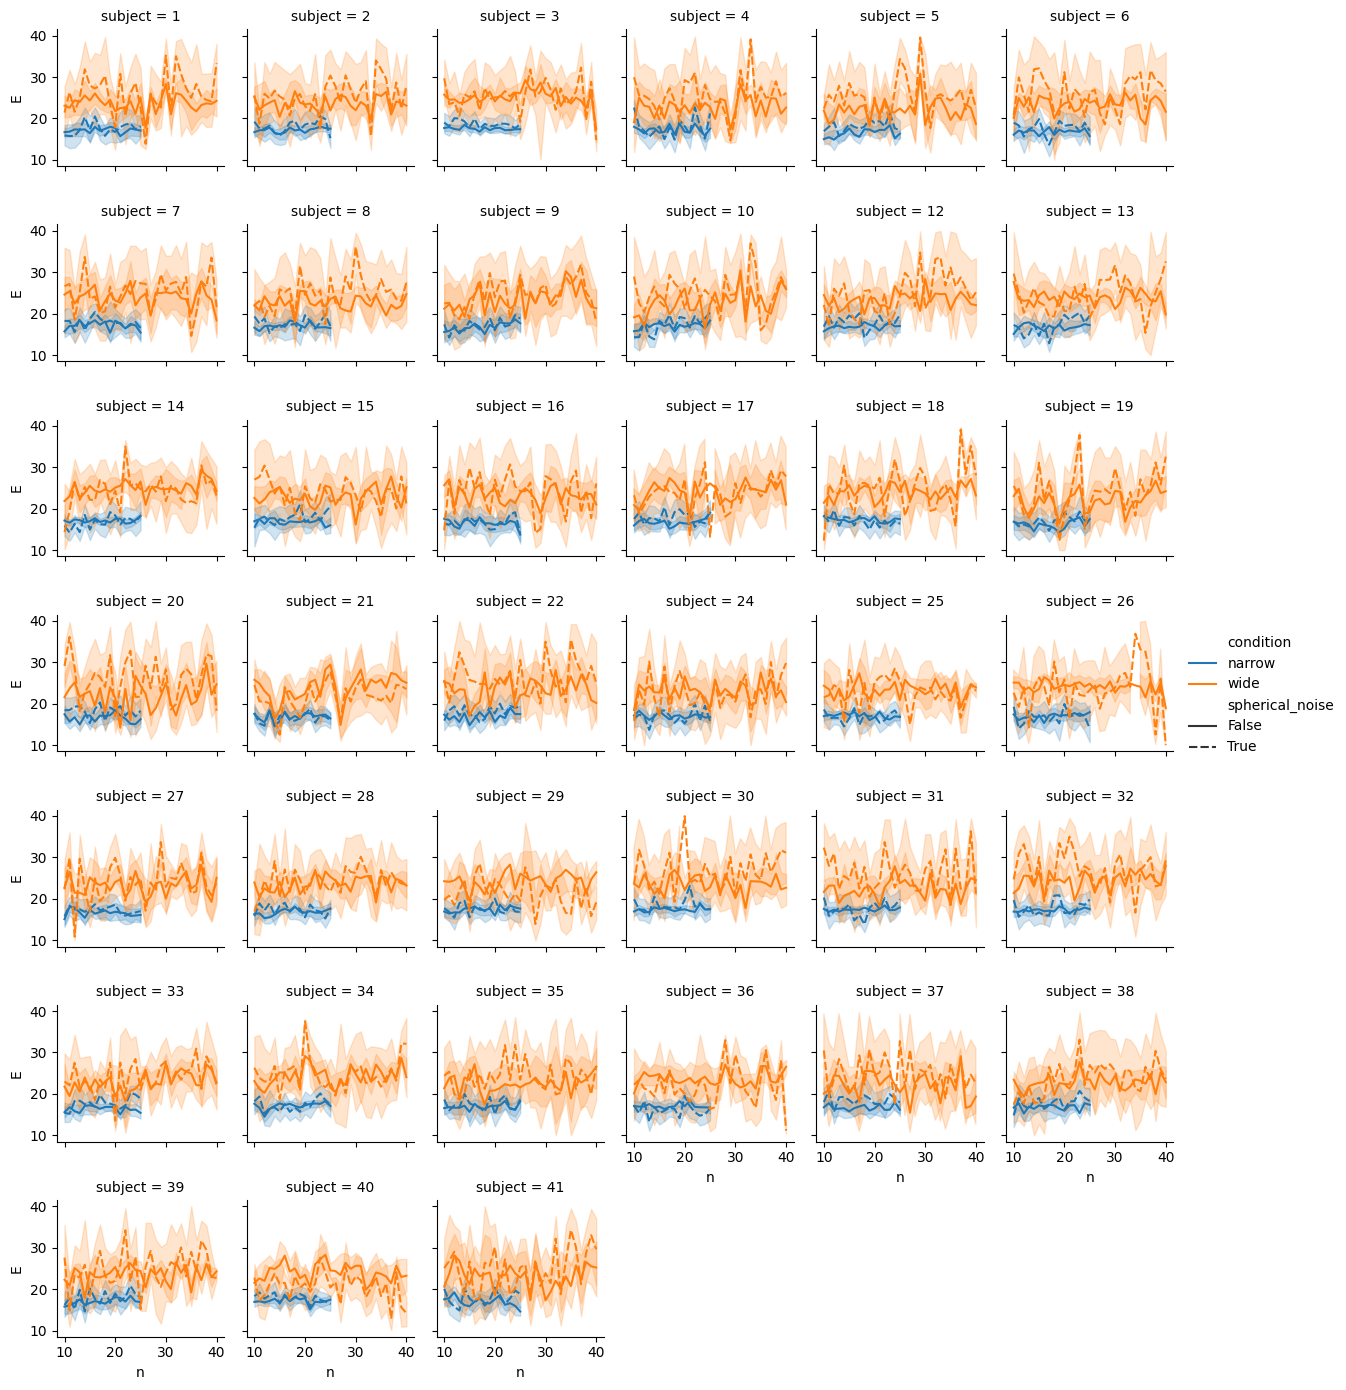

In [63]:
sns.relplot(fmri_trial_resps, x='n', y='E', col='subject', col_wrap=6, hue='condition', kind='line', style='spherical_noise', height=2)

In [64]:
fmri_trial_resps.groupby(['spherical_noise', 'subject', 'condition', 'n']).E.std().groupby(['spherical_noise', 'condition']).describe()

count       mean       std       min       25%        50%        75%        max
spherical_noise condition                                                                                  
False           narrow      624.0   2.751000  0.739734  1.092717  2.183299   2.755838   3.311370   4.562988
                wide       1206.0   5.377288  1.881534  0.177488  3.996001   5.403182   6.627117  11.550149
True            narrow      624.0   5.463510  0.825909  2.180790  4.922319   5.596368   6.088765   7.227569
                wide       1205.0  10.280070  2.648900  0.040281  9.157212  10.745091  12.042573  18.187642

### fMRI - trial posteriors

In [65]:
fmri_trial_pdfs = pd.read_csv('decoding/decoding_pdf.tsv', delimiter='\t', ) #index_col=[0,1,2,3,4,5,])
# fmri_trial_resps = fmri_trial_resps.drop(columns=['session', 'run', 'trial_nr', 'onset', 'phase', 'nr_frames', 'jitter', 'start_marker_position', 'onset_abs', 'duration'])
# fmri_trial_resps = fmri_trial_resps.rename(columns={'range':'condition'})
# fmri_trial_resps = fmri_trial_resps.set_index(['spherical_noise', 'subject', 'condition'])
# fmri_trial_resps['t'] = fmri_trial_resps.groupby(level=['spherical_noise', 'subject', 'condition']).cumcount() + 1
# fmri_trial_resps.set_index('t', append=True, inplace=True)
# fmri_trial_resps = fmri_trial_resps.sort_index()
fmri_trial_pdfs

/var/folders/jq/_79_qpxx3vd0thkqqmw37l1c0000gn/T/ipykernel_25884/4047400185.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  fmri_trial_pdfs = pd.read_csv('decoding/decoding_pdf.tsv', delimiter='\t', ) #index_col=[0,1,2,3,4,5,])


,n,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,10.0,10.0.1,11.0,11.0.1,12.0,12.0.1,13.0,13.0.1,14.0,14.0.1,15.0,15.0.1,16.0,16.0.1,17.0,17.0.1,18.0,18.0.1,19.0,19.0.1,20.0,20.0.1,21.0,21.0.1,22.0,22.0.1,23.0,23.0.1,24.0,24.0.1,25.0,25.0.1,26.0,26.0.1,27.0,27.0.1,28.0,28.0.1,29.0,29.0.1,30.0,30.0.1,31.0,31.0.1,32.0,32.0.1,33.0,33.0.1,34.0,34.0.1,35.0,35.0.1,36.0,36.0.1,37.0,37.0.1,38.0,38.0.1,39.0,39.0.1,40.0,40.0.1
0,range,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
1,subject,subject,session,run2,trial_nr,run,x,range,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01,01,1,1,1,1,11.0,0.0,8.613667e-09,1.305750e-07,1.429114e-09,2.465364e-08,9.132926e-10,6.984720e-09,1.443271e-09,3.721917e-09,3.545521e-09,3.352635e-09,1.224174e-08,3.998643e-09,5.551717e-08,5.625584e-09,3.045889e-07,9.044418e-09,1.861738e-06,1.637333e-08,1.176583e-05,3.283066e-08,7.210743e-05,7.157757e-08,4.064149e-04,1.664431e-07,2.019521e-03,4.053290e-07,8.569186e-03,1.016574e-06,3.035631e-02,2.586661e-06,8.854943e-02,6.590169e-06,2.113650e-01,1.662339e-05,4.129873e-01,4.111191e-05,6.642354e-01,9.887247e-05,8.881707e-01,2.296540e-04,1.000000e+00,5.123162e-04,9.623071e-01,1.092746e-03,8.042585e-01,2.220719e-03,5.934576e-01,4.289047e-03,3.929104e-01,7.858250e-03,2.370574e-01,1.364430e-02,1.322648e-01,2.244010e-02,6.916470e-02,3.496443e-02,3.431537e-02,5.163939e-02,1.633058e-02,7.236905e-02,7.526593e-03,9.635738e-02
3,01,01,1,1,2,1,23.0,0.0,1.158690e-13,4.995173e-13,3.836964e-14,2.743317e-13,2.956573e-14,1.531646e-13,4.397758e-14,1.143061e-13,1.153293e-13,1.137147e-13,5.673588e-13,1.338782e-13,4.626253e-12,1.915378e-13,5.347730e-11,3.467983e-13,7.688816e-10,7.872671e-13,1.231143e-08,2.161543e-12,1.991638e-07,6.903414e-12,2.985235e-06,2.478515e-11,3.845055e-05,9.718125e-11,3.994552e-04,4.059024e-10,3.182975e-03,1.766768e-09,1.875456e-02,7.856967e-09,7.986602e-02,3.507092e-08,2.434876e-01,1.546269e-07,5.327192e-01,6.637825e-07,8.472269e-01,2.739071e-06,1.000000e+00,1.074368e-05,8.996006e-01,3.966383e-05,6.357357e-01,1.366940e-04,3.643044e-01,4.366987e-04,1.747418e-01,1.286038e-03,7.232379e-02,3.476558e-03,2.657276e-02,8.599837e-03,8.892072e-03,1.942800e-02,2.772261e-03,4.004962e-02,8.214319e-04,7.534152e-02,2.352867e-04,1.294673e-01
4,01,01,1,1,3,1,23.0,0.0,1.675825e-35,2.968929e-34,3.463434e-36,6.401781e-35,2.571608e-36,2.282138e-35,5.095557e-36,1.439590e-35,2.111341e-35,1.487283e-35,1.683662e-34,2.175506e-35,2.302058e-33,4.254626e-35,4.838025e-32,1.083576e-34,1.429366e-30,3.480895e-34,5.506795e-29,1.363134e-33,2.592412e-27,6.310381e-33,1.408042e-25,3.364934e-32,8.380592e-24,2.021527e-31,5.218224e-22,1.342274e-30,3.258491e-20,9.687790e-30,1.963077e-18,7.487948e-29,1.101347e-16,6.116502e-28,5.571279e-15,5.218310e-27,2.467551e-13,4.600071e-26,9.321506e-12,4.150101e-25,2.934734e-10,3.798468e-24,7.550323e-09,3.498981e-23,1.562063e-07,3.220451e-22,2.566570e-06,2.941925e-21,3.320263e-05,2.651156e-20,3.365804e-04,2.343775e-19,2.670373e-03,2.021995e-18,1.662018e-02,1.69

### fMRI-Stan

In [66]:
#stan_fmri = pd.read_csv('stan/outputs/summaries_fmri_30/results_20250804221241.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10
#stan_fmri = pd.read_csv('stan/outputs/summaries_fmri_30/results_20250804230132.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10, prior tau, nu
stan_fmri_notspherical = pd.read_csv('stan/outputs/summaries_fmri_notspherical_30/results_20250805175119.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10, prior tau, nu
stan_fmri_spherical = pd.read_csv('stan/outputs/summaries_fmri_spherical_30/results_20250805174026.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10, prior tau, nu
stan_fmri_spherical

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-49162.500000,1.002330,46.994700,-49238.200000,-49163.200000,-49083.200000,2198.24,3.38221,1.005900
z_m_0_15[1],0.253463,0.000064,0.007964,0.240409,0.253435,0.266644,15700.90,24.15730,0.999709
z_m_0_15[2],0.204598,0.000063,0.007897,0.191687,0.204644,0.217618,15897.90,24.46040,1.000040
z_m_0_15[3],0.164896,0.000062,0.007952,0.151954,0.164928,0.177829,16401.20,25.23480,0.999713
z_m_0_15[4],0.130767,0.000064,0.007845,0.117550,0.130869,0.143387,15262.30,23.48250,1.000130
...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],1.303230,0.000255,0.032562,1.250050,1.303000,1.357030,16256.70,25.01240,0.999571
delta_avg_log_var_s_1322[36],1.302900,0.000260,0.032916,1.249120,1.302980,1.357430,16031.00,24.66530,0.999622
delta_avg_log_var_s_1322[37],1.303230,0.000259,0.032575,1.249660,1.303060,1.357020,15768.70,24.26170,0.999535
delta_avg_log_var_s_1322[38],1.303470,0.000262,0.032750,1.249810,1.302970,1.358280,15655.30,24.08720,0.999591


In [67]:
das = []
quantities = ['m_s', 'sigma_s', 'var_s', 'inv_sigma_s', 'log_var_s', ]
for qty in quantities:
    da = []
    for cond in CONDITIONS:
        cond_k = {NARROW: 15, WIDE: 30}[cond]
        for subject in range(1, 40):
            nmax = {NARROW: 17, WIDE: 32}[cond]
            for n in range(1, nmax):
                v = stan_fmri_spherical.loc[f'{qty}_{cond_k}[{subject},{n}]', 'Mean']
                da.append([subj_i_to_subj[subject], cond, n+9., True, v])
                v = stan_fmri_notspherical.loc[f'{qty}_{cond_k}[{subject},{n}]', 'Mean']
                da.append([subj_i_to_subj[subject], cond, n+9., False, v])
    da = pd.DataFrame(da, columns=['subject', 'condition', 'n', 'is_spherical', qty[:-2]]).set_index(['subject', 'condition', 'n', 'is_spherical'])
    das.append(da)
stan_fmri_subj_n = pd.concat(das, axis=1)
stan_fmri_subj_n['bias'] = stan_fmri_subj_n['m'] - stan_fmri_subj_n.index.get_level_values('n')
stan_fmri_subj_n['log_n'] = np.log(stan_fmri_subj_n.index.get_level_values('n'))
stan_fmri_subj_n

m     sigma        var  inv_sigma  log_var     bias     log_n
subject condition n    is_spherical                                                                     
1       narrow    10.0 True          17.4936   5.63029   31.72990   0.177777  3.45538   7.4936  2.302585
                       False         16.7592   2.51876    6.45596   0.403943  1.83018   6.7592  2.302585
                  11.0 True          17.0705   5.61109   31.51300   0.178381  3.44858   6.0705  2.397895
                       False         16.9291   2.41496    5.95679   0.422828  1.74238   5.9291  2.397895
                  12.0 True          16.8883   5.56703   31.02040   0.179795  3.43280   4.8883  2.484907
...                                      ...       ...        ...        ...      ...      ...       ...
41      wide      38.0 False         23.9553   6.32056   40.77050   0.161395  3.66757 -14.0447  3.637586
                  39.0 True          25.7054  11.00360  121.28300   0.091032  4.79476 -13.2946  3.663562
                       False         23.9600   6.12961   38.31490   0.166306  3.60693 -15.0400  3.663562
                  40.0 True          24.4963  11.05180  122.36900   0.090651  4.80333 -15.5037  3.688879
                       False         23.3781   7.07131   51.00120   0.144177  3.89263 -16.6219  3.688879

[3666 rows x 7 columns]

In [68]:
index_filter(stan_fmri_subj_n, condition=NARROW, n=10, is_spherical=True)

,m,sigma,var,inv_sigma,log_var,bias,log_n
subject,,,,,,,
1,17.4936,5.63029,31.7299,0.177777,3.45538,7.4936,2.302585
2,17.6701,5.63019,31.7291,0.177782,3.45534,7.6701,2.302585
3,17.6758,5.62926,31.7182,0.177810,3.45502,7.6758,2.302585
4,17.8188,5.63054,31.7330,0.177770,3.45547,7.8188,2.302585
5,17.5449,5.62731,31.6967,0.177874,3.45431,7.5449,2.302585
6,17.6756,5.63147,31.7433,0.177741,3.45580,7.6756,2.302585
7,17.6370,5.63043,31.7317,0.177773,3.45543,7.6370,2.302585
8,17.6578,5.63026,31.7299,0.177780,3.45537,7.6578,2.302585
9,17.5964,5.62970,31.7239,0.177799,3.45516,7.5964,2.302585


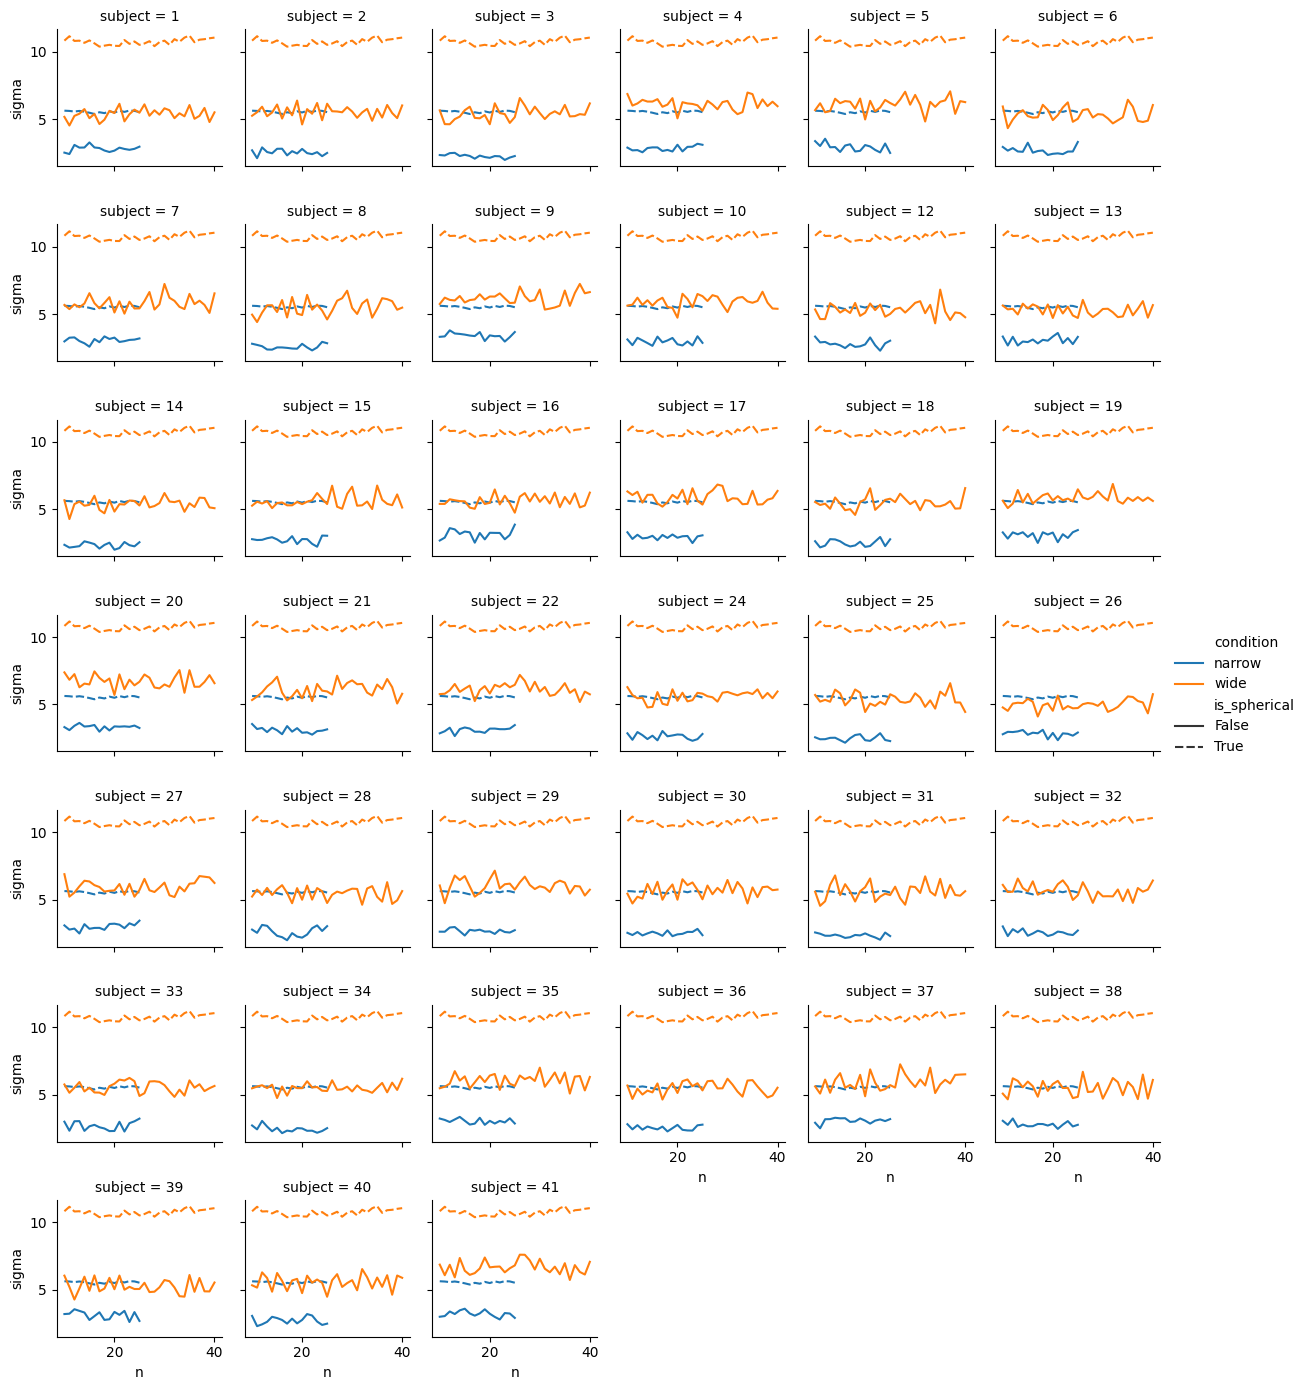

In [69]:
sns.relplot(stan_fmri_subj_n, x='n', y='sigma', hue='condition', kind='line', col='subject', col_wrap=6, height=2, style='is_spherical')

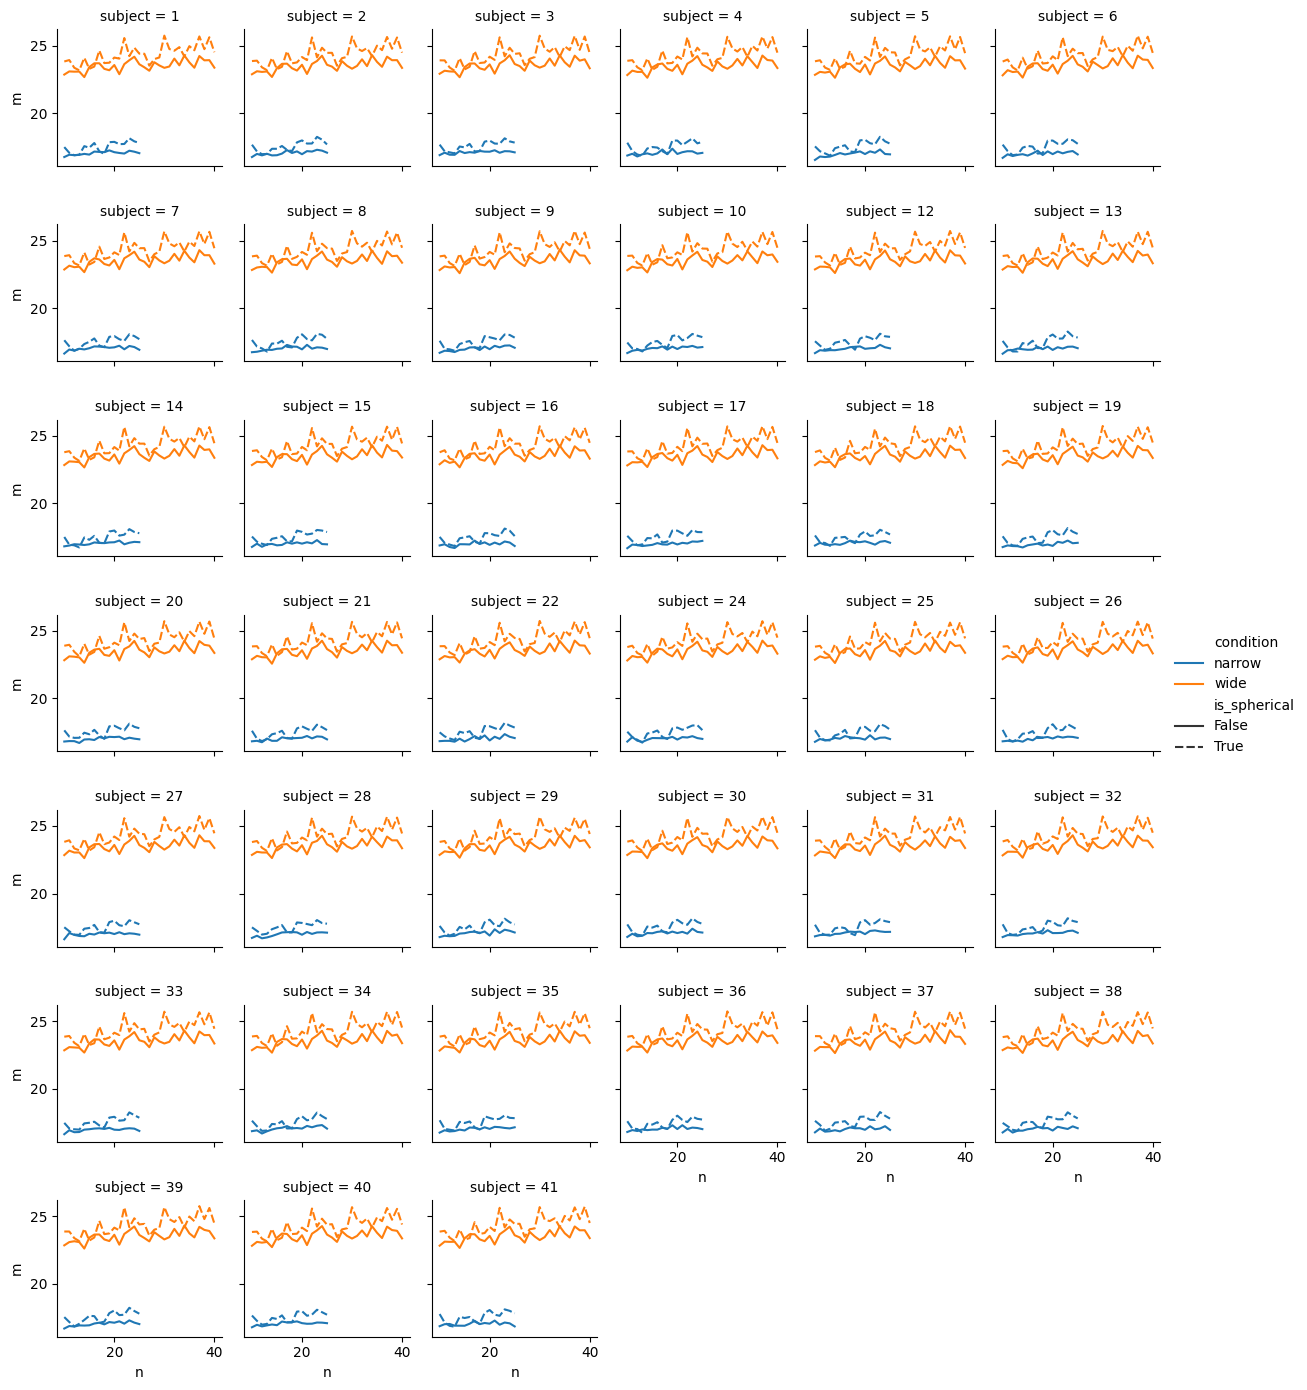

In [70]:
sns.relplot(stan_fmri_subj_n, x='n', y='m', hue='condition', kind='line', col='subject', col_wrap=6, height=2, style='is_spherical')

# fMRI across conditions

## Fisher info

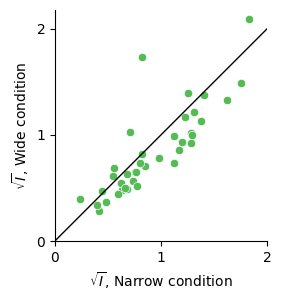

In [71]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect('equal')
#ax.set_xscale('log'); ax.set_yscale('log')
model_label = 31
subrange = 'narrowrange' # '1124'
qty = 'sqrt_fi'
label = '$\sqrt{I}$' # '$\langle \sqrt{I(x)}\\rangle$'
sns.scatterplot( x=index_filter(fisher_info_avgs, subrange=subrange, condition=NARROW, model_label=model_label)[qty].rename(f'{label}, {NARROW.capitalize()} condition'), # model_label=15,
             y=index_filter(fisher_info_avgs, subrange=subrange, condition=WIDE, model_label=model_label)[qty].rename(f'{label}, {WIDE.capitalize()} condition'), # model_label=15, 
            ax=ax, color=THIRD_COLOR)
ax.axline((1,1), slope=1, color='k', linestyle='-', lw=1)
#ax.set_xlim(0,2.25)
#ax.set_ylim(ax.get_xlim())
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.savefig(f'figures/{qty}_w_vs_n.pdf', bbox_inches='tight')

In [72]:
fisher_info_avgs.columns

Index(['fi', 'log_fi', 'sqrt_fi', 'inv_fi', 'inv_sqrt_fi'], dtype='object')

Paired t-test: t = -6.529, p = 5.37e-08, dof = 38


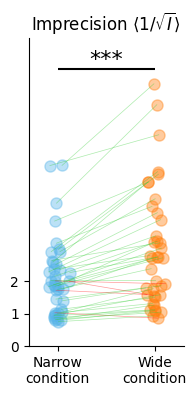

In [173]:
fig, ax = plt.subplots(figsize=(2, 4))
model_label = 31
subrange = 'narrowrange' # '1124'
qty = 'inv_sqrt_fi'
xx1 = index_filter(fisher_info_avgs, subrange=subrange, condition=NARROW, model_label=model_label)[qty].rename(NARROW)
xx2 = index_filter(fisher_info_avgs, subrange=subrange, condition=WIDE, model_label=model_label)[qty].rename(WIDE)
paired_strip_plot(ax, x1=1, x2=2, y1=xx1, y2=xx2,
                 color_decr_line='red', color_incr_line='limegreen', col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE])
ax.set_xlim(0.7, 2.3)
ax.set_ylim((0,9.5) if qty == 'inv_sqrt_fi' else (-3.75, 1.7) if qty == 'log_fi' else (0,2.49) if qty == 'sqrt_fi' else None)
ax.set_xticks([1, 2])
ax.set_yticks([0,1,2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title('Imprecision $\\langle 1/\sqrt{I} \\rangle$' if qty == 'inv_sqrt_fi' else "Log-Fisher information" if qty == 'log_fi' else
             #'fMRI-derived average $\sqrt{I}$' if qty == 'sqrt_fi' else qty
             'fMRI-derived $\sqrt{I}$' if qty == 'sqrt_fi' else qty
             )
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# paired test
paired_test = pg.ttest(xx1, xx2, paired=True, alternative='less' if qty in ['inv_sqrt_fi',] else 'greater')
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(ax.get_ylim()[0] + 0.9*(ax.get_ylim()[1]-ax.get_ylim()[0]), 1, 2, color='k', lw=1.5)
if (pv := paired_test['p-val'].iloc[0]) < 0.05:
    ax.text(1.5, ax.get_ylim()[0] + 0.93*(ax.get_ylim()[1]-ax.get_ylim()[0]), star_string(pv), ha='center', va='center', fontsize=16, color='k')

#fig.savefig(f'figures/delta_{qty}.pdf', bbox_inches='tight')

count    39.000000
mean     -0.088071
std       0.231144
min      -0.394936
25%      -0.252481
50%      -0.136482
75%      -0.034746
max       0.910485
Name: sqrt_fi_delta_wn, dtype: float64

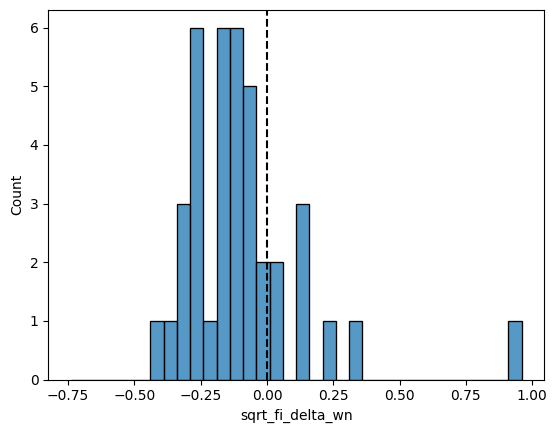

In [74]:
subrange = 'narrowrange'
model_label = 31
sns.histplot( index_filter(fisher_info_avgs_deltas, subrange=subrange, model_label=model_label).sqrt_fi_delta_wn, bins=np.arange(-.74, 1.,.05), ) # model_label=15,
axvline(0, color='k', linestyle='--')
index_filter(fisher_info_avgs_deltas, subrange=subrange, model_label=model_label).sqrt_fi_delta_wn.describe()

## Decoding

In [75]:
fmri_estimates_avgs

mean_E  mean_error      var_E  mean_abs_error     sigma      bias   log_var
subrange subject wide_prior condition model_label                                                                                
all      1       False      narrow    15           17.500120    0.000120   0.846384        0.644334  0.900933  0.000120 -0.258407
                                      18           17.488188   -0.011812   0.927790        0.717525  0.950007 -0.011812 -0.137512
                                      31           17.492390   -0.007611   0.699289        0.577567  0.821504 -0.007610 -0.434774
                            wide      15           17.479056   -0.020944   1.530476        0.887792  1.209011 -0.020944  0.329207
                                      18           17.481986   -0.018013   1.444085        0.891383  1.180976 -0.018014  0.292836
...                                                      ...         ...        ...             ...       ...       ...       ...
1322     40      True       wide      31           19.878653    2.378652  10.892675        2.626820  3.034281  2.378653  2.029172
         41      False      narrow    31           17.495076   -0.004924   0.073222        0.120924  0.269711 -0.004924 -2.627315
                            wide      31           17.507831    0.007831   0.197967        0.287254  0.443249  0.007830 -1.635689
                 True       narrow    31           17.501067    0.001067   0.075568        0.119520  0.273873  0.001067 -2.597698
                            wide      31           17.515928    0.015928   0.218519        0.298152  0.466768  0.015928 -1.526850

[1540 rows x 7 columns]

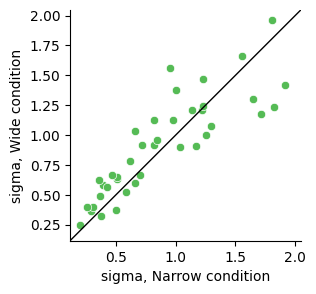

In [76]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect('equal')
#ax.set_xscale('log'); ax.set_yscale('log')
model_label = 31
subrange = 'narrowrange' # '1124'
wide_prior = False
qty = 'sigma'
label = qty #'var_E' # '$\langle \sqrt{I(x)}\\rangle$'
sns.scatterplot( x=index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=NARROW, wide_prior=wide_prior)[qty].rename(f'{label}, {NARROW.capitalize()} condition'), # model_label=15,
             y=index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=WIDE, wide_prior=wide_prior)[qty].rename(f'{label}, {WIDE.capitalize()} condition'),
            ax=ax, color=THIRD_COLOR)
ax.axline((1,1), slope=1, color='k', linestyle='-', lw=1)
xmin, xmax = (lambda x: (min(x[0]), max(x[1])))(list(zip( ax.get_xlim(), ax.get_ylim() )))
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)
#ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#fig.savefig('figures/sqrt_I_w_vs_n.pdf', bbox_inches='tight')

In [77]:
fmri_estimates_avgs.columns

Index(['mean_E', 'mean_error', 'var_E', 'mean_abs_error', 'sigma', 'bias', 'log_var'], dtype='object')

Paired t-test: t = -7.490, p = 2.7e-09, dof = 38


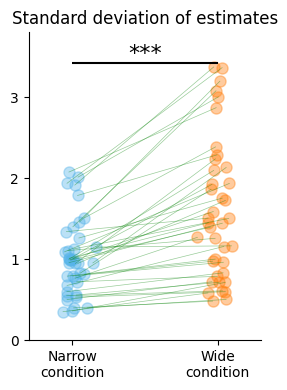

In [78]:
fig, ax = plt.subplots(figsize=(3, 4))
model_label = 31
subrange = 'all' # 'narrowrange' # '1124'
wide_prior = True
qty = 'sigma'
xx1 = index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=NARROW, wide_prior=wide_prior)[qty].rename(NARROW)
xx2 = index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=WIDE, wide_prior=wide_prior)[qty].rename(WIDE)
paired_strip_plot(gca(), x1=1, x2=2, y1=xx1, y2=xx2,
                 color_decr_line='red', color_incr_line='g', col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE],)
ax.set_xlim(0.7, 2.3)
ax.set_ylim(0,3.8)
ax.set_yticks([0,1,2,3])
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Standard deviation of estimates' if qty == 'sigma' else qty)

# paired test
paired_test = pg.ttest(xx1, xx2, paired=True, alternative='less')
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(ax.get_ylim()[0] + 0.9*(ax.get_ylim()[1]-ax.get_ylim()[0]), 1, 2, color='k', lw=1.5)
if (pv := paired_test['p-val'].iloc[0]) < 0.05:
    ax.text(1.5, ax.get_ylim()[0] + 0.93*(ax.get_ylim()[1]-ax.get_ylim()[0]), star_string(pv), ha='center', va='center', fontsize=16, color='k')

#fig.savefig(f'figures/delta_{qty}.pdf', bbox_inches='tight')

count    39.000000
mean      0.414214
std       0.340741
min      -0.100514
25%       0.145155
50%       0.325690
75%       0.604266
max       1.294466
Name: sigma_diff, dtype: float64

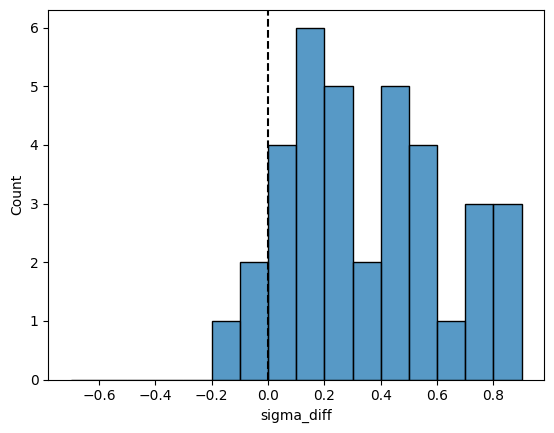

In [79]:
subrange = 'narrowrange'
model_label = 31
wide_prior = True
qty = 'sigma_diff'
sns.histplot( index_filter(fmri_ests_avgs_deltas, subrange=subrange, model_label=model_label, wide_prior=wide_prior)[qty], bins=np.arange(-.7, 1.,.1), ) # model_label=15,
axvline(0, color='k', linestyle='--')
index_filter(fmri_ests_avgs_deltas, subrange=subrange, model_label=model_label, wide_prior=wide_prior)[qty].describe()

# fMRI across x

## Fisher info

In [80]:
fisher_info['one_over_n'] = 1./fisher_info.index.get_level_values('n')
fisher_info

fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n  one_over_n
subject model_label n    condition                                                                           
1       31          10.0 narrow     6.035191  1.797608  2.456663  0.165695     0.407056  2.302585    0.100000
                    11.0 narrow     3.724520  1.314938  1.929902  0.268491     0.518161  2.397895    0.090909
                    12.0 narrow     1.117674  0.111250  1.057201  0.894715     0.945894  2.484907    0.083333
                    13.0 narrow     1.006050  0.006032  1.003020  0.993986     0.996989  2.564949    0.076923
                    14.0 narrow     0.460209 -0.776076  0.678387  2.172928     1.474085  2.639057    0.071429
...                                      ...       ...       ...       ...          ...       ...         ...
41      18          36.0 wide       0.278386 -1.278748  0.527623  3.592138     1.895294  3.583519    0.027778
                    37.0 wide       0.260428 -1.345428  0.510322  3.839830     1.959548  3.610918    0.027027
                    38.0 wide       0.243548 -1.412443  0.493505  4.105973     2.026320  3.637586    0.026316
                    39.0 wide       0.227707 -1.479694  0.477187  4.391601     2.095615  3.663562    0.025641
                    40.0 wide       0.212865 -1.547096  0.461373  4.697809     2.167443  3.688879    0.025000

[6084 rows x 7 columns]

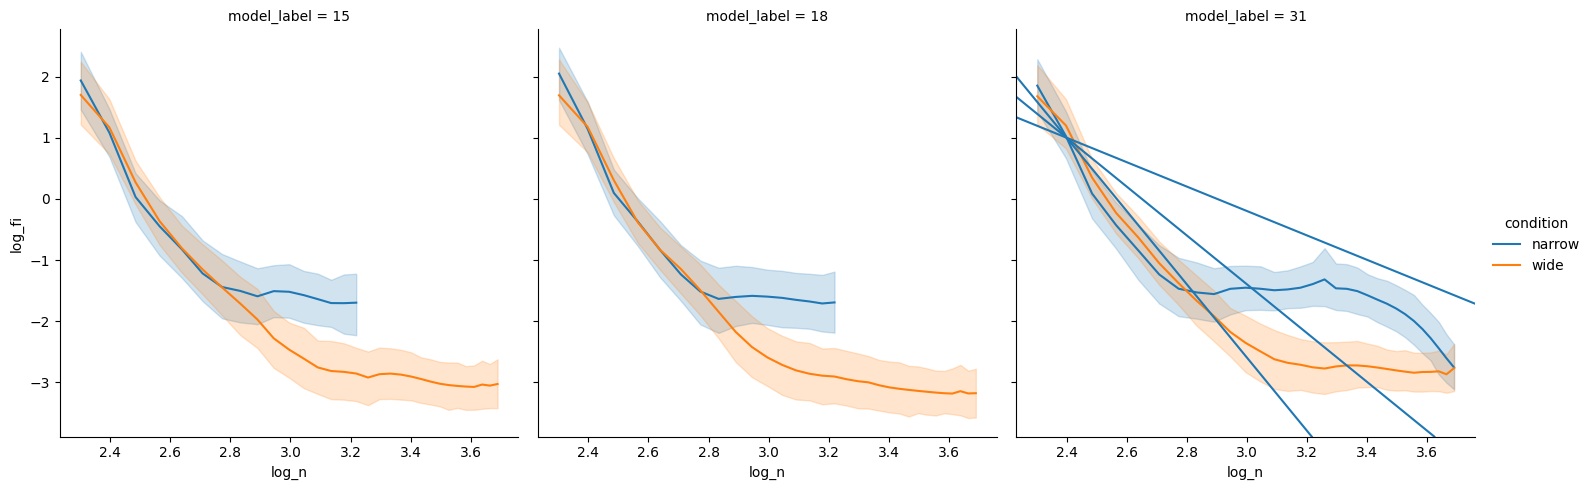

In [81]:
sns.relplot( fisher_info, x='log_n', y='log_fi', hue='condition', kind='line', col='model_label') # index_filter(fisher_info, model_label=15)
gca().axline((2.4, 1), slope=-2)
gca().axline((2.4, 1), slope=-4)
gca().axline((2.4, 1), slope=-6)

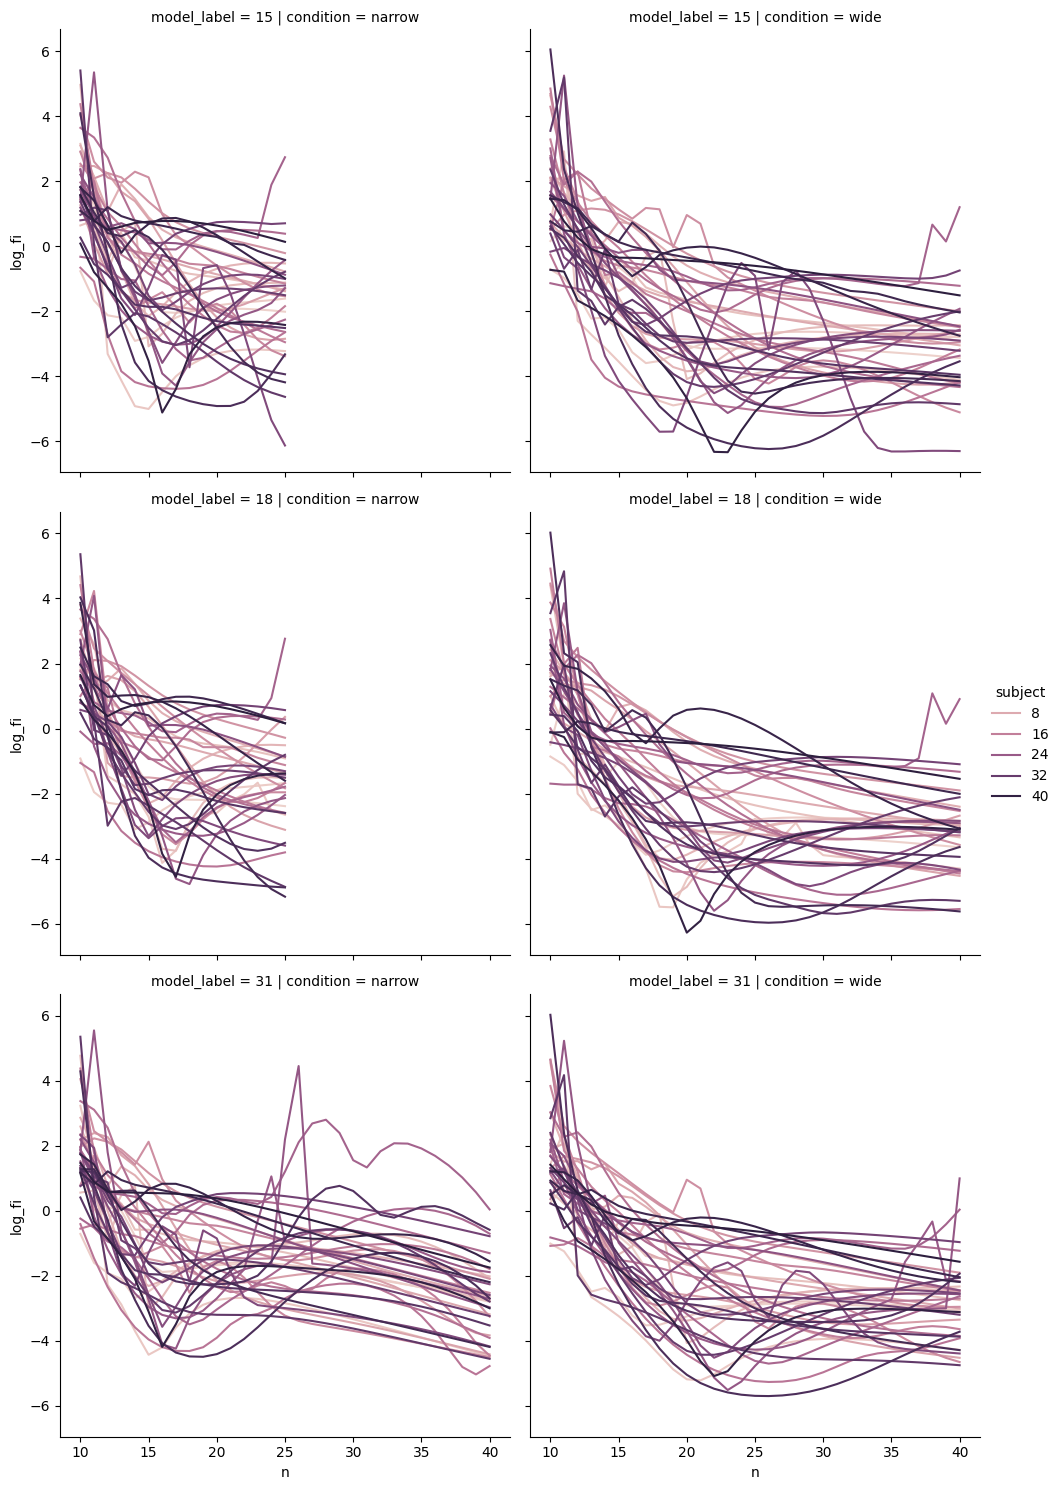

In [82]:
sns.relplot( index_filter(fisher_info), x='n', y='log_fi', hue='subject', kind='line', col='condition', row='model_label') # model_label=15

## Decoding

In [83]:
fmri_estimates_stats

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide_prior condition n                                                                                            
1       31          False      narrow    10.0  10.497773    0.497774  1.135848        0.497774  1.065762  0.497773  0.127380  2.302585
                                         11.0  11.106773    0.106774  0.225290        0.164888  0.474647  0.106773 -1.490367  2.397895
                                         12.0  12.152911    0.152911  0.320103        0.280951  0.565777  0.152911 -1.139112  2.484907
                                         13.0  13.158963    0.158963  0.735248        0.526162  0.857466  0.158963 -0.307547  2.564949
                                         14.0  14.232490    0.232489  0.641316        0.594400  0.800822  0.232490 -0.444234  2.639057
...                                                  ...         ...       ...             ...       ...       ...       ...       ...
40      18          False      wide      21.0  20.284681   -0.715318  1.085669        0.888804  1.041954 -0.715319  0.082196  3.044522
                                         22.0  20.323923   -1.676076  1.244854        1.710050  1.115730 -1.676077  0.219018  3.091042
                                         23.0  20.410765   -2.589235  1.564157        2.591409  1.250663 -2.589235  0.447347  3.135494
                                         24.0  20.319063   -3.680938  2.342525        3.680938  1.530531 -3.680937  0.851229  3.178054
                                         25.0  20.261852   -4.738148  3.050201        4.738148  1.746482 -4.738148  1.115207  3.218876

[6098 rows x 8 columns]

In [84]:
index_filter(fmri_estimates_stats, model_label=31, condition=cond, n=range(10,MAX_COND[cond]+1))

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject wide_prior n                                                                                            
1       False      10.0  10.348520    0.348521  1.320488        0.348521  1.149125  0.348520  0.278001  2.302585
                   11.0  11.192401    0.192401  0.502973        0.215815  0.709206  0.192401 -0.687219  2.397895
                   12.0  12.223511    0.223510  0.475474        0.341286  0.689546  0.223511 -0.743444  2.484907
                   13.0  13.365149    0.365150  0.681279        0.534276  0.825396  0.365149 -0.383784  2.564949
                   14.0  14.165733    0.165733  0.830125        0.585008  0.911112  0.165733 -0.186178  2.639057
...                            ...         ...       ...             ...       ...       ...       ...       ...
41      True       36.0  35.989860   -0.010141  0.394477        0.475371  0.628074 -0.010140 -0.930194  3.583519
                   37.0  36.994663   -0.005337  0.432053        0.496666  0.657308 -0.005337 -0.839206  3.610918
                   38.0  37.933020   -0.066975  0.400793        0.469463  0.633082 -0.066980 -0.914310  3.637586
                   39.0  38.805088   -0.194910  0.317602        0.424634  0.563562 -0.194912 -1.146957  3.663562
                   40.0  39.474987   -0.525012  0.239361        0.525012  0.489245 -0.525013 -1.429782  3.688879

[1833 rows x 8 columns]

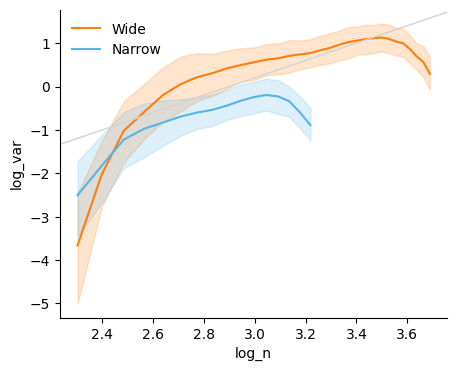

In [85]:
#sns.relplot(index_filter(fmri_estimates_stats, model_label=31), x='n', y='sigma', hue='condition', kind='line',) #  model_label=15
fig, ax = plt.subplots(figsize=(5, 4))
for cond in [WIDE, NARROW]:
    sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, condition=cond, n=range(10,MAX_COND[cond]+1), wide_prior=cond==WIDE),
                 x='log_n', y='log_var', label=cond.capitalize(), color=COLORS_COND[cond], ax=ax)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axline((2.4, -1), slope=2, color='lightgrey', lw=1, )
# ax.set_xlim(10, 40)
# ax.set_ylim(0, 2.5)
# ax.set_xlabel('Number')
# ax.set_ylabel(None)
# ax.set_title('Standard deviation of fMRI-derived estimates')

In [ ]:
COLORS_COND[NARROW]
"#78BEE7"

'#56B4E9'

Text(0.5, 1.0, 'Standard deviation of fMRI-derived estimates')

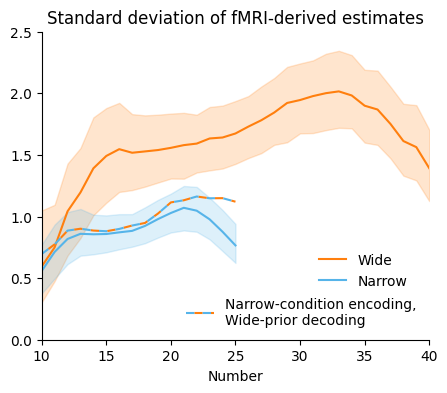

In [404]:
#sns.relplot(index_filter(fmri_estimates_stats, model_label=31), x='n', y='sigma', hue='condition', kind='line',) #  model_label=15
fig, ax = plt.subplots(figsize=(5, 4))
for cond in [WIDE, NARROW]:
    sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide_prior=cond==WIDE, condition=cond, n=range(10, 41)), x='n', y='sigma', label=cond.capitalize(), color=COLORS_COND[cond], ax=ax)
    #sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide_prior=cond!=WIDE, condition=cond, n=range(10,41)), x='n', y='sigma', label=cond.capitalize(), color=COLORS_COND[cond], ax=ax, ls=':')
#sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide_prior=False, condition=WIDE, n=range(10,41)), x='n', y='sigma', label=WIDE.capitalize(), color=COLORS_COND[WIDE], ax=ax, ls=':')
sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide_prior=True, condition=NARROW, n=range(10,26)), x='n', y='sigma',
             label='Narrow-condition encoding,\nWide-prior decoding', 
             color=COLORS_COND[NARROW], errorbar=None, ax=ax, dashes=[4, 4], gapcolor=COLORS_COND[WIDE])
# sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide_prior=True, condition=NARROW, n=range(10,26)), x='n', y='sigma',
#              color=COLORS_COND[WIDE], errorbar=None, ax=ax, ls=':')
leg_hands = list(zip( *ax.get_legend_handles_labels() ))
leg1 = ax.legend( *zip( *leg_hands[:2] ), loc=(.7, .15) )
leg2 = ax.legend( *zip( *leg_hands[2:] ), loc='lower right' )
ax.add_artist(leg1) 
#ax.add_artist(leg2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(10, 40)
ax.set_ylim(0, 2.5)
ax.set_xlabel('Number')
ax.set_ylabel(None)
ax.set_title('Standard deviation of fMRI-derived estimates')

In [382]:
leg2.get_texts()

<a list of 0 Text objects>

In [373]:
list( zip( *list(zip( *ax.get_legend_handles_labels() ))[:2] ) )

[(<matplotlib.lines.Line2D at 0x33c593ee0>,
  <matplotlib.lines.Line2D at 0x33c5ca4a0>),
 ('Wide', 'Narrow')]

In [87]:
index_filter(fmri_estimates_stats, model_label=31, wide_prior=True, condition=NARROW)

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject n                                                                                            
1       10.0  10.476123    0.476123  1.055120        0.476123  1.027190  0.476123  0.053655  2.302585
        11.0  11.102278    0.102277  0.226197        0.161752  0.475602  0.102278 -1.486347  2.397895
        12.0  12.135842    0.135843  0.222560        0.270570  0.471763  0.135842 -1.502556  2.484907
        13.0  13.167693    0.167693  0.601260        0.497615  0.775410  0.167693 -0.508727  2.564949
        14.0  14.264460    0.264460  0.627663        0.598814  0.792252  0.264460 -0.465753  2.639057
...                 ...         ...       ...             ...       ...       ...       ...       ...
41      36.0  36.040240    0.040241  0.419236        0.492639  0.647484  0.040240 -0.869322  3.583519
        37.0  37.033882    0.033881  0.462194        0.495027  0.679849  0.033882 -0.771770  3.610918
        38.0  37.960120   -0.039878  0.377232        0.471308  0.614192 -0.039880 -0.974894  3.637586
        39.0  38.804688   -0.195312  0.319548        0.419453  0.565286 -0.195312 -1.140847  3.663562
        40.0  39.421150   -0.578851  0.284618        0.578851  0.533496 -0.578850 -1.256606  3.688879

[1209 rows x 8 columns]

Paired t-test: t = -7.490, p = 2.7e-09, dof = 38


Text(0.0, 1.0, 'fMRI-derived standard deviation of estimates')

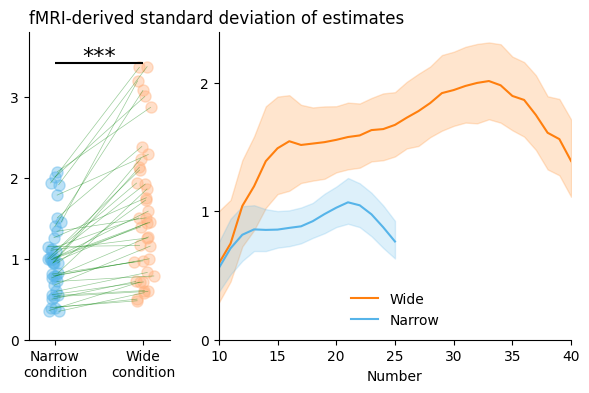

In [88]:
fig, axs = plt.subplots(figsize=(7, 4), ncols=2, width_ratios=(2,5),) # sharey=True)
model_label = 31
subrange = 'all' # '1124'
qty = 'sigma'

#####
ax = axs[1]
ax.set_ylim(0, 2.4)

for cond in [WIDE, NARROW]:
    sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide_prior=cond==WIDE, condition=cond, n=range(10,MAX_COND[cond]+1)), x='n', y='sigma', label=cond.capitalize(),
                 color=COLORS_COND[cond], ax=ax)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(10, 40)
ax.set_xlabel('Number')
ax.set_ylabel(None)
ax.legend(loc='lower center', )
ax.set_yticks([0, 1, 2])
#ax.set_title('Standard deviation of fMRI-derived estimates', x=.55)

####
ax = axs[0]
xx1 = index_filter(fmri_estimates_avgs, model_label=model_label, wide_prior=True, subrange=subrange, condition=NARROW)[qty].rename(NARROW)
xx2 = index_filter(fmri_estimates_avgs, model_label=model_label, wide_prior=True, subrange=subrange, condition=WIDE)[qty].rename(WIDE)
paired_strip_plot(ax, x1=1, x2=2, y1=xx1, y2=xx2,
                 color_decr_line='red', color_incr_line='g', col1=COLORS_COND[NARROW], col2='xkcd:peach') #COLORS_COND[WIDE],)
ax.set_xlim(0.7, 2.3)
ax.set_ylim(0,3.8)
ax.set_yticks([0,1,2,3])
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.set_title('Standard deviation of fMRI-derived estimates', x=.5, ha='left')

# paired test
paired_test = pg.ttest(xx1, xx2, paired=True, alternative='less')
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(ax.get_ylim()[0] + .9*(ax.get_ylim()[1]-ax.get_ylim()[0]), 1, 2, color='k', lw=1.5, clip_on=False)
if (pv := paired_test['p-val'].iloc[0]) < 0.05:
    #ax.text(1.5, ax.get_ylim()[0] + 1.04*(ax.get_ylim()[1]-ax.get_ylim()[0]), star_string(pv), ha='center', va='center', fontsize=16, color='k')
    ax.text(1.5, ax.get_ylim()[0] + .92*(ax.get_ylim()[1]-ax.get_ylim()[0]), star_string(pv), ha='center', va='center', fontsize=16, color='k')

axs[0].set_title('fMRI-derived standard deviation of estimates', x=0., ha='left' )

#fig.savefig(f'figures/fmri_{qty}.pdf', bbox_inches='tight')

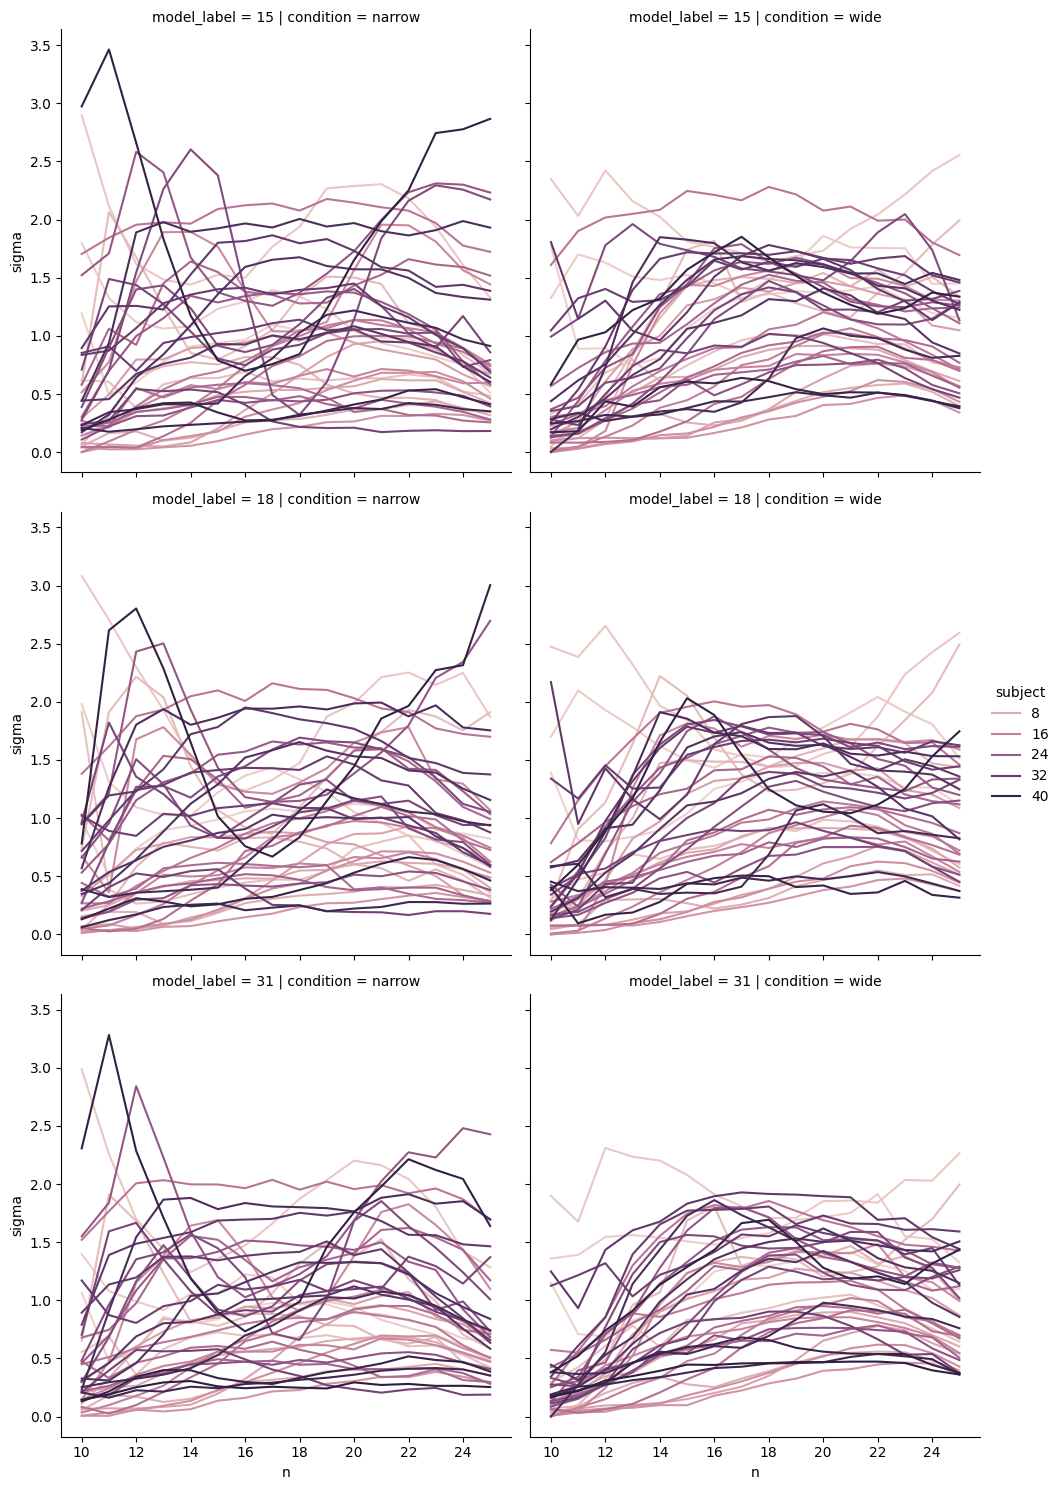

In [89]:
sns.relplot(index_filter(fmri_estimates_stats, wide_prior=False), x='n', y='sigma', hue='subject', kind='line', col='condition', row='model_label') # model_label=15

## deltas

In [90]:
fisher_info_deltas

fi_diff  log_fi_diff  sqrt_fi_diff  inv_fi_diff  inv_sqrt_fi_diff     log_n
subject model_label n                                                                                 
1       15          10.0 -4.517753    -1.578028     -1.302013     0.675507          0.503465  2.302585
                    11.0 -1.851967    -0.693541     -0.563848     0.270302          0.215412  2.397895
                    12.0  0.759647     0.574263      0.329114    -0.446183         -0.252230  2.484907
                    13.0 -0.642712    -0.780934     -0.352006     0.998097          0.438661  2.564949
                    14.0 -0.162006    -0.358384     -0.120318     0.801324          0.267589  2.639057
...                            ...          ...           ...          ...               ...       ...
41      31          36.0  0.004423     0.016310      0.004247    -0.060139         -0.015659  3.583519
                    37.0  0.014591     0.058820      0.014647    -0.237189         -0.059056  3.610918
                    38.0  0.022645     0.099737      0.023760    -0.439636         -0.104689  3.637586
                    39.0  0.028919     0.139042      0.031699    -0.669591         -0.152532  3.663562
                    40.0  0.033701     0.176723      0.038574    -0.929131         -0.202541  3.688879

[3627 rows x 6 columns]

Index(['fi_diff', 'log_fi_diff', 'sqrt_fi_diff', 'inv_fi_diff', 'inv_sqrt_fi_diff', 'log_n'], dtype='object')


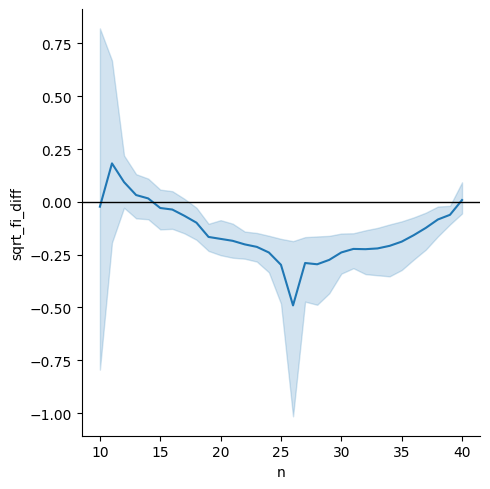

In [91]:
print(fisher_info_deltas.columns)
model_label = 31
sns.relplot( index_filter(fisher_info_deltas, model_label=model_label), x='n', y='sqrt_fi_diff', kind='line',) # model_label=15
axhline(0, color='k', linestyle='-', lw=1)
#ylim(-5,5)

Index(['mean_E_diff', 'mean_error_diff', 'var_E_diff', 'mean_abs_error_diff', 'sigma_diff', 'bias_diff', 'log_var_diff', 'log_n'], dtype='object')


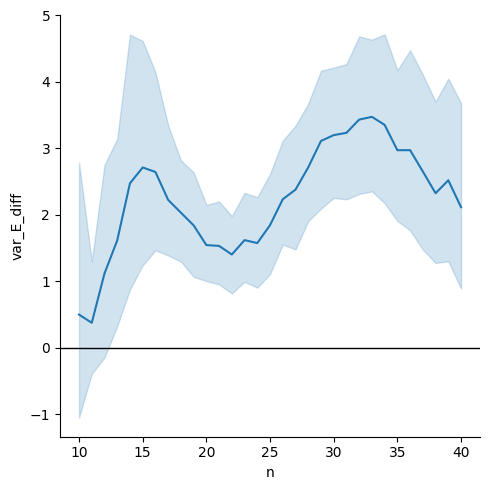

In [92]:
print(fmri_estimates_deltas.columns)
model_label = 31
wide_prior = True
sns.relplot( index_filter(fmri_estimates_deltas, model_label=model_label, wide_prior=wide_prior), x='n', y='var_E_diff', kind='line',) # model_label=15
axhline(0, color='k', linestyle='-', lw=1)
#ylim(-5,5)

# Comparisons Stan/fMRI

## Stan vs. fMRI-decoding-quantities

### Variability across x

In [228]:
fmri_estimates_stats

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide_prior condition n                                                                                            
1       31          False      narrow    10.0  10.497773    0.497774  1.135848        0.497774  1.065762  0.497773  0.127380  2.302585
                                         11.0  11.106773    0.106774  0.225290        0.164888  0.474647  0.106773 -1.490367  2.397895
                                         12.0  12.152911    0.152911  0.320103        0.280951  0.565777  0.152911 -1.139112  2.484907
                                         13.0  13.158963    0.158963  0.735248        0.526162  0.857466  0.158963 -0.307547  2.564949
                                         14.0  14.232490    0.232489  0.641316        0.594400  0.800822  0.232490 -0.444234  2.639057
...                                                  ...         ...       ...             ...       ...       ...       ...       ...
40      18          False      wide      21.0  20.284681   -0.715318  1.085669        0.888804  1.041954 -0.715319  0.082196  3.044522
                                         22.0  20.323923   -1.676076  1.244854        1.710050  1.115730 -1.676077  0.219018  3.091042
                                         23.0  20.410765   -2.589235  1.564157        2.591409  1.250663 -2.589235  0.447347  3.135494
                                         24.0  20.319063   -3.680938  2.342525        3.680938  1.530531 -3.680937  0.851229  3.178054
                                         25.0  20.261852   -4.738148  3.050201        4.738148  1.746482 -4.738148  1.115207  3.218876

[6098 rows x 8 columns]

In [229]:
MAX_COND

{'narrow': 25, 'wide': 40}

In [487]:
z = []
for boundary_buffer in [0,1,2]:
    for model_label in [15, 18, 31]:
        for wide_prior in [False, True]:
            for subject in index_filter(fmri_estimates_stats, model_label=model_label, wide_prior=wide_prior).index.get_level_values('subject').unique():
                for cond in CONDITIONS:
                    a, b = 10+boundary_buffer, MAX_COND[cond]-boundary_buffer
                    dat = index_filter(fmri_estimates_stats, subject=subject, condition=cond, model_label=model_label, n=range(a, b+1), wide_prior=wide_prior)
                    res = quick_ols(y=dat.log_var, x=dat.log_n)
                    z.append([boundary_buffer, subject, wide_prior, model_label, cond, res.params.log_n, res.params.const, res.rsquared, res.pvalues.log_n])
fmri_log_var_n_ols = pd.DataFrame(z, columns=['boundary_buffer', 'subject', 'wide_prior', 'model_label', 'condition', 'slope', 'intercept', 'r2', 'pval']).set_index(['boundary_buffer', 'subject', 'wide_prior', 'model_label', 'condition'])
fmri_log_var_n_ols

/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1734: RuntimeWarning: invalid value encountered in subtract
  return np.sum(weights * (model.endog - mean)**2)


slope  intercept        r2          pval
boundary_buffer subject wide_prior model_label condition                                             
0               1       False      15          narrow     0.314474  -1.146830  0.035250  4.862326e-01
                                               wide       0.601389  -1.369783  0.132599  1.655723e-01
                2       False      15          narrow    -1.543772   4.502688  0.563044  8.123388e-04
                                               wide       0.207109   0.307356  0.085742  2.710685e-01
                3       False      15          narrow    -0.192330   1.768478  0.015673  6.441043e-01
...                                                            ...        ...       ...           ...
2               39      True       31          wide       1.571967  -5.650852  0.744331  7.134360e-09
                40      True       31          narrow     0.844136  -1.635527  0.051493  4.781696e-01
                                               wide      -0.166003   2.661417  0.005312  7.179013e-01
                41      True       31          narrow     0.289025  -3.404873  0.118043  2.742015e-01
                                               wide       0.874392  -4.089454  0.838614  2.148371e-11

[924 rows x 4 columns]

In [484]:
index_filter(fmri_log_var_n_ols, boundary_buffer=0, model_label=31, wide_prior=True, condition=WIDE).r2.describe()

count    39.000000
mean      0.456872
std       0.282153
min       0.000042
25%       0.225024
50%       0.466961
75%       0.710893
max       0.924231
Name: r2, dtype: float64

In [491]:
print( (index_filter(fmri_log_var_n_ols, boundary_buffer=0, model_label=31, wide_prior=True, condition=WIDE).pval < 0.01).mean() )
index_filter(fmri_log_var_n_ols, boundary_buffer=0, model_label=31, wide_prior=True, condition=WIDE).pval.describe(percentiles=[.75, .8, .9])

0.7948717948717948


count    3.900000e+01
mean     7.671057e-02
std      2.298594e-01
min      8.622485e-18
50%      2.267577e-05
75%      7.016824e-03
80%      1.101254e-02
90%      1.596715e-01
max      9.724111e-01
Name: pval, dtype: float64

In [486]:
res.pvalues.log_n

2.148371239300588e-11

In [231]:
res.params.const

-4.089453616150487

In [97]:
fmri_log_var_n_ols.groupby(['boundary_buffer', 'model_label', 'wide_prior', 'condition']).describe()

/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


slope                                                                        intercept                        \
                                                 count      mean       std       min       25%       50%       75%        max     count       mean        std   
boundary_buffer model_label wide_prior condition                                                                                                                
0               15          False      narrow     38.0  1.921284  2.787403 -2.061918  0.105054  1.061725  2.434502  10.093276      38.0  -6.169607   8.711087   
                                       wide       38.0       inf       NaN -0.043502  1.444701  2.670128  4.037185        inf      38.0       -inf        NaN   
                18          False      narrow     38.0  1.689448  2.440754 -2.160425  0.235480  1.178299  2.568469   8.185821      38.0  -5.495574   7.706504   
                                       wide       38.0  3.248712  3.260815 -0.423041  1.642596  2.502514  3.701971  14.779106      38.0  -9.745268  10.065993   
                31          False      narrow     39.0  1.737459  2.509710 -1.850504  0.137829  1.111011  2.273291   8.499500      39.0  -5.686581   7.925885   
                                       wide       39.0  3.587959  2.702874 -0.027031  1.817012  2.796218  4.433321  12.015660      39.0 -10.871929   8.306268   
                            True       narrow     39.0  2.087011  2.704861 -1.277202  0.247963  1.491050  2.654036   9.163981      39.0  -6.494754   8.474324   
                                       wide       39.0  1.968549  1.731581 -0.567190  0.800990  1.822765  2.386128   6.646101      39.0  -5.815919   6.052982   
1               15          False      narrow     38.0  1.630620  2.720374 -2.953211  0.129687  0.704495  2.176837   8.766490      38.0  -5.223505   8.480593   
                                       wide       38.0  2.392069  1.945590 -0.192043  1.168259  2.008311  3.379240   7.104711      38.0  -7.209658   6.369607   
                18          False      narrow     38.0  1.595594  2.668650 -3.262545 -0.005194  0.906344  2.398204   8.717013      38.0  -5.132561   8.333076   
                                       wide       38.0  2.352809  1.928617 -0.273249  1.119845  1.816522  2.758733   7.906036      38.0  -7.082162   6.385661   
                31          False      narrow     39.0  1.575817  2.577422 -2.894591  0.227151  0.798654  2.049013   8.333730      39.0  -5.113160   8.076822   
                                       wide       39.0  2.607934  1.866761 -0.069835  1.473189  2.306602  3.164533   7.536035      39.0  -7.958769   6.085478   
                            True       narrow     39.0  1.875026  2.769708 -2.807523  0.372383  0.908333  2.439191   9.099882      39.0  -5.834662   8.578850   
                                       wide       39.0  1.604204  1.572639 -0.505797  0.602106  1.229795  2.120121   5.873353      39.0  -4.544225   5.629893   
2               15          False      narrow     38.0  1.567337  3.054533 -4.273935 -0.002273  0.797846  2.090090  10.292457      38.0  -4.975288   9.376624   
                                       wide       38.0  1.756400  1.846022 -0.453357  0.571485  1.180853  2.470978   6.636689      38.0  -5.305345   6.140738   
                18          False      narrow     38.0  1.501820  2.902351 -4.198739 -0.136437  0.617592  2.491627   9.274669      38.0  -4.790724   8.966720   
                                       wide       38.0  1.697504  1.803389 -0.154272  0.476670  1.203918  1.944739   6.540123      38.0  -5.119026   6.095842   
                31          False      narrow     39.0  1.469426  2.557620 -3.625340  0.083970  0.792545  1.857278   9.181473      39.0  -4.728767   7.922412   
                                       wide       39.0  1.886155  1.815553 -0.307691  0.612812  1.372733  2.350196   6.580132      39.0  -5.796491   6.005786   
                        

In [232]:
stan_subj_n

m    sigma       var  inv_sigma  log_var    bias     log_n
subject condition n                                                                     
1       narrow    10.0  11.6204  2.06285   4.31974   0.491927  1.43340  1.6204  2.302585
                  11.0  12.9499  1.69757   2.95769   0.604200  1.03283  1.9499  2.397895
                  12.0  14.6868  2.40350   5.90082   0.424829  1.73286  2.6868  2.484907
                  13.0  14.9618  2.12623   4.63126   0.481492  1.48500  1.9618  2.564949
                  14.0  16.8867  2.08295   4.44199   0.491202  1.44447  2.8867  2.639057
...                         ...      ...       ...        ...      ...     ...       ...
41      wide      36.0  35.7106  3.63340  13.90460   0.290382  2.52729 -0.2894  3.583519
                  37.0  35.2801  3.63474  13.76590   0.286455  2.54049 -1.7199  3.610918
                  38.0  36.1881  3.44828  12.46470   0.304084  2.42838 -1.8119  3.637586
                  39.0  36.6927  3.29484  11.28060   0.315145  2.34683 -2.3073  3.663562
                  40.0  37.2799  3.07692   9.98379   0.342776  2.19463 -2.7201  3.688879

[1833 rows x 7 columns]

In [492]:
z = []
for boundary_buffer in [0,1,2]:
    for subject in fmri_estimates_stats.index.get_level_values('subject').unique():
        for cond in CONDITIONS:
            a, b = 10+boundary_buffer, MAX_COND[cond]-boundary_buffer
            dat = index_filter(stan_subj_n, subject=subject, condition=cond, n=range(a, b+1))
            res = quick_ols(y=dat.log_var, x=dat.log_n)
            z.append([boundary_buffer, subject, cond, res.params.log_n, res.params.const, res.rsquared, res.pvalues.log_n])
stan_log_var_n_ols = pd.DataFrame(z, columns=['boundary_buffer', 'subject', 'condition', 'slope', 'intercept', 'r2', 'pval']).set_index(['boundary_buffer', 'subject', 'condition'])
stan_log_var_n_ols

slope  intercept        r2          pval
boundary_buffer subject condition                                             
0               1       narrow     0.185212   0.921380  0.064748  3.415808e-01
                        wide       0.571195   0.357566  0.555026  1.531311e-06
                2       narrow    -0.195029   2.130673  0.067468  3.312893e-01
                        wide       0.673819   0.098594  0.476177  1.745750e-05
                3       narrow     0.512888   0.376639  0.220839  6.624716e-02
...                                     ...        ...       ...           ...
2               39      wide       0.966207  -0.863171  0.658509  2.809240e-07
                40      narrow    -0.093521   1.658505  0.014419  7.101032e-01
                        wide       0.553559   0.409881  0.432156  1.947661e-04
                41      narrow    -0.448796   2.606895  0.204470  1.399732e-01
                        wide       0.687136   0.263698  0.376977  6.579496e-04

[234 rows x 4 columns]

In [493]:
index_filter(stan_log_var_n_ols, boundary_buffer=0, condition=WIDE).r2.describe()

count    39.000000
mean      0.570950
std       0.155184
min       0.007799
25%       0.495572
50%       0.605013
75%       0.674985
max       0.815332
Name: r2, dtype: float64

In [494]:
print( (index_filter(stan_log_var_n_ols, boundary_buffer=0, condition=WIDE).pval < 0.01).mean() )
index_filter(stan_log_var_n_ols, boundary_buffer=0, condition=WIDE).pval.describe(percentiles=[.75, .8, .9])

0.9743589743589743


count    3.900000e+01
mean     1.637989e-02
std      1.019323e-01
min      3.723026e-12
50%      2.617126e-07
75%      9.964346e-06
80%      2.037587e-05
90%      2.224936e-04
max      6.366238e-01
Name: pval, dtype: float64

In [235]:
stan_log_var_n_ols.groupby(['boundary_buffer', 'condition']).describe()

slope                                                                       intercept                                                    \
                          count      mean       std       min       25%       50%       75%       max     count      mean       std       min       25%       50%   
boundary_buffer condition                                                                                                                                           
0               narrow     39.0  0.478246  0.499223 -0.492902  0.177146  0.512888  0.853203  1.747911      39.0 -0.006694  1.498927 -3.718280 -1.054079 -0.254098   
                wide       39.0  0.866146  0.252451 -0.062316  0.722733  0.901338  1.025353  1.274628      39.0 -0.460446  0.836974 -1.744151 -1.100455 -0.561603   
1               narrow     39.0  0.306458  0.478261 -0.665901 -0.075024  0.325790  0.668651  1.305325      39.0  0.528790  1.412127 -2.359477 -0.606243  0.424992   
                wide       39.0  0.731095  0.243897 -0.043508  0.567525  0.752230  0.893223  1.164604      39.0  0.000787  0.803490 -1.424944 -0.465179 -0.023845   
2               narrow     39.0  0.207388  0.483785 -0.922550 -0.238037  0.192830  0.572760  1.031590      39.0  0.838950  1.419591 -1.551370 -0.303529  0.849910   
                wide       39.0  0.710084  0.244220 -0.117337  0.589064  0.692598  0.878121  1.206048      39.0  0.076383  0.800703 -1.494061 -0.427036  0.063749   

                                               
                                75%       max  
boundary_buffer condition                      
0               narrow     0.827614  2.902874  
                wide       0.027903  2.773315  
1               narrow     1.708498  3.577347  
                wide       0.488329  2.735603  
2               narrow     1.992335  4.220078  
                wide       0.415124  2.953869

••• Model label: 18
  Wide prior: False
          n         r         CI95%     p-val   BF10     power
pearson  38  0.163063  [-0.11, 1.0]  0.163994  0.532  0.255575
           n        r         CI95%     p-val    power
spearman  38  0.16446  [-0.11, 1.0]  0.161901  0.25835
          n         r       CI95%     p-val   BF10    power
pearson  38  0.357302  [0.1, 1.0]  0.013824  4.112  0.72457
           n         r        CI95%     p-val     power
spearman  38  0.316337  [0.05, 1.0]  0.026501  0.625426
  Wide prior: True
  Wide prior: cond
          n         r         CI95%     p-val   BF10     power
pearson  38  0.163063  [-0.11, 1.0]  0.163994  0.532  0.255575
           n        r         CI95%     p-val    power
spearman  38  0.16446  [-0.11, 1.0]  0.161901  0.25835
••• Model label: 31
  Wide prior: False
          n         r         CI95%     p-val   BF10     power
pearson  39  0.154047  [-0.12, 1.0]  0.174551  0.499  0.242074
           n         r         CI95%     p-val     p

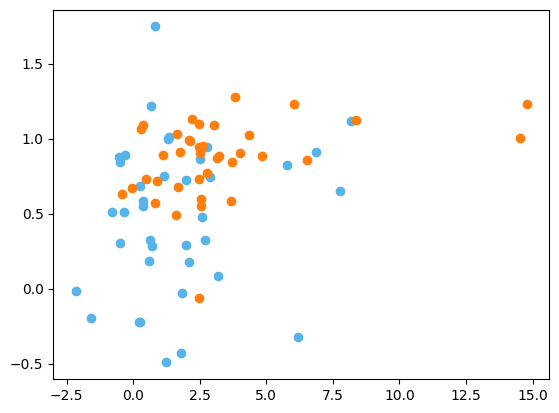

<Figure size 640x480 with 0 Axes>

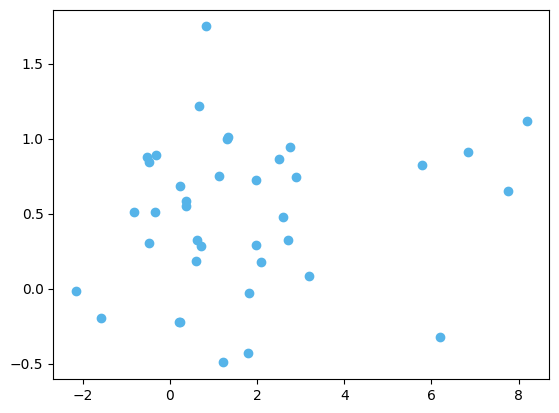

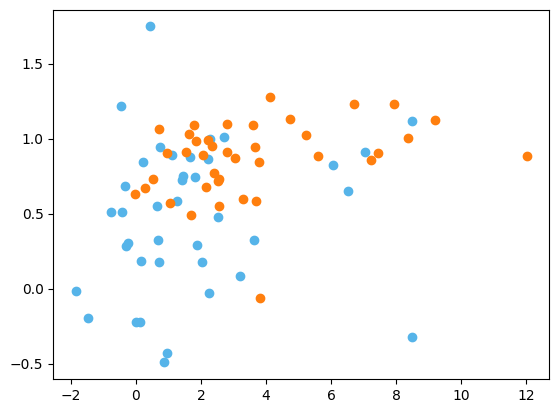

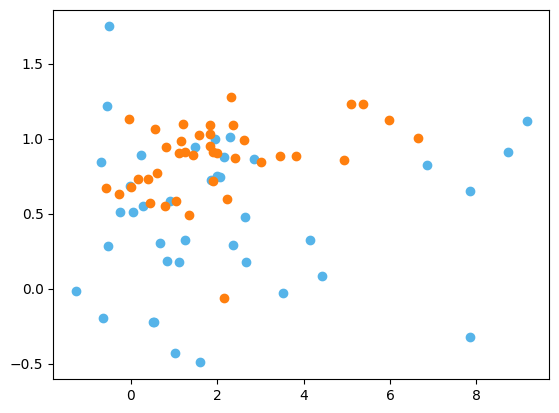

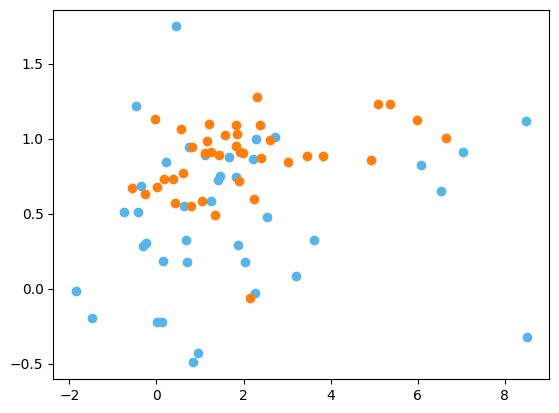

In [495]:
boundary_buffer = 0
for model_label in [18, 31]:
    print(f"••• Model label: {model_label}")
    for wide_prior in [False, True, 'cond']:
        print(f"  Wide prior: {wide_prior}")
        figure()
        for cond in CONDITIONS:
            subjs = set(index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique()).intersection(
                index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique())
            wp = wide_prior if wide_prior != 'cond' else cond == WIDE
            xxx = index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, subject=subjs, boundary_buffer=boundary_buffer, wide_prior=wp).slope
            yyy = index_filter(stan_log_var_n_ols, condition=cond, subject=subjs, boundary_buffer=boundary_buffer).slope
            if len(xxx) != len(yyy):
                continue
            print( pg.corr(xxx, yyy, alternative='greater' )) # method='spearman'
            print( pg.corr(xxx, yyy, method='spearman', alternative='greater' ) )
            scatter(xxx, yyy, c=COLORS_COND[cond], )

Subject 24: -0.062316493691103564
Other subjects: Mean = 0.891, SD = 0.204
Subject 24 is -4.68 SD away from the mean of other subjects.
          n         r        CI95%     p-val   BF10   power
pearson  39  0.366487  [0.11, 1.0]  0.010874  4.988  0.7554
           n         r        CI95%     p-val     power
spearman  39  0.371862  [0.12, 1.0]  0.009876  0.767104


Text(0.65, 0.1, '$r = 0.37$*')

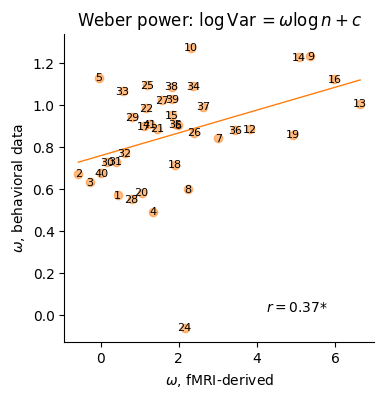

In [498]:
model_label = 31
cond = WIDE
boundary_buffer = 0
wide_prior = True
c = COLORS_COND[cond] # FOURTH_COLOR
fig, ax = plt.subplots(figsize=(4, 4))
subjs = set(index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique()).intersection(
    index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique())
#subjs = set(subjs) - set((24,))
xxx = index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, subject=subjs, boundary_buffer=boundary_buffer, wide_prior=wide_prior).slope
yyy = index_filter(stan_log_var_n_ols, condition=cond, subject=subjs, boundary_buffer=boundary_buffer).slope
if 24 in yyy:
    mm, sd = yyy.drop(24).describe()[['mean', 'std']]
    print('Subject 24:', yyy[24])
    print(f"Other subjects: Mean = {mm:.3f}, SD = {sd:.3f}")
    print(f"Subject 24 is {((yyy[24] - mm) / sd):.2f} SD away from the mean of other subjects.")
r_pearsons = pg.corr(xxx, yyy, alternative='greater')
print( r_pearsons ) # method='spearman'
print( pg.corr(xxx, yyy, alternative='greater', method='spearman' ) )
ax.scatter(x=xxx, y=yyy, color=c, alpha=.5)
for subj in subjs:
    ax.text(xxx[subj], yyy[subj], str(subj), color='k', fontsize=8, ha='center', va='center')
#sns.regplot(x=xxx, y=yyy, color=c, ax=ax, scatter_kws={'color': c, 'alpha': .5}, )
res_odr = odr_1dregression(x=xxx, y=yyy)
x_vals = np.linspace(xxx.min(), xxx.max(), 100)
ax.plot(x_vals, odr_pred(res_odr, x_vals), color=c, lw=1,)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Weber power: $\log \operatorname{Var} = \omega \log n + c$')
ax.set_xlabel('$\omega$, fMRI-derived')
ax.set_ylabel('$\omega$, behavioral data')
pv = r_pearsons['p-val'].iloc[0]
ax.text(0.65, 0.1, f'$r = {r_pearsons.r.iloc[0]:.2f}${star_string(pv)}', transform=ax.transAxes)
#fig.savefig(f'figures/weber_power.pdf', bbox_inches='tight')


In [238]:
fmri_estimates_stats

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide_prior condition n                                                                                            
1       31          False      narrow    10.0  10.497773    0.497774  1.135848        0.497774  1.065762  0.497773  0.127380  2.302585
                                         11.0  11.106773    0.106774  0.225290        0.164888  0.474647  0.106773 -1.490367  2.397895
                                         12.0  12.152911    0.152911  0.320103        0.280951  0.565777  0.152911 -1.139112  2.484907
                                         13.0  13.158963    0.158963  0.735248        0.526162  0.857466  0.158963 -0.307547  2.564949
                                         14.0  14.232490    0.232489  0.641316        0.594400  0.800822  0.232490 -0.444234  2.639057
...                                                  ...         ...       ...             ...       ...       ...       ...       ...
40      18          False      wide      21.0  20.284681   -0.715318  1.085669        0.888804  1.041954 -0.715319  0.082196  3.044522
                                         22.0  20.323923   -1.676076  1.244854        1.710050  1.115730 -1.676077  0.219018  3.091042
                                         23.0  20.410765   -2.589235  1.564157        2.591409  1.250663 -2.589235  0.447347  3.135494
                                         24.0  20.319063   -3.680938  2.342525        3.680938  1.530531 -3.680937  0.851229  3.178054
                                         25.0  20.261852   -4.738148  3.050201        4.738148  1.746482 -4.738148  1.115207  3.218876

[6098 rows x 8 columns]

In [239]:
stan_subj_n

m    sigma       var  inv_sigma  log_var    bias     log_n
subject condition n                                                                     
1       narrow    10.0  11.6204  2.06285   4.31974   0.491927  1.43340  1.6204  2.302585
                  11.0  12.9499  1.69757   2.95769   0.604200  1.03283  1.9499  2.397895
                  12.0  14.6868  2.40350   5.90082   0.424829  1.73286  2.6868  2.484907
                  13.0  14.9618  2.12623   4.63126   0.481492  1.48500  1.9618  2.564949
                  14.0  16.8867  2.08295   4.44199   0.491202  1.44447  2.8867  2.639057
...                         ...      ...       ...        ...      ...     ...       ...
41      wide      36.0  35.7106  3.63340  13.90460   0.290382  2.52729 -0.2894  3.583519
                  37.0  35.2801  3.63474  13.76590   0.286455  2.54049 -1.7199  3.610918
                  38.0  36.1881  3.44828  12.46470   0.304084  2.42838 -1.8119  3.637586
                  39.0  36.6927  3.29484  11.28060   0.315145  2.34683 -2.3073  3.663562
                  40.0  37.2799  3.07692   9.98379   0.342776  2.19463 -2.7201  3.688879

[1833 rows x 7 columns]

In [240]:
def smooth_ys(conv_w, dat_xs, dat_ys, xs=None, with_stdy=False):
    '''For each x' in xs, this considers all the occurences in which dat_xs = x, and computes the weighted average
    of all the dat_ys, each weighted by exp(-(x-x')^2/(2*conv_w^2)).
    If xs is None, it will be the (ordered) set of values encountered in dat_xs.
    Returns both xs and ys.
    If with_stdy is True, also returns '''
    assert dat_xs.shape == dat_ys.shape
    if xs is None:
        xs = np.array(sorted(list(set(dat_xs))))
    ys = np.ones(xs.shape)*np.nan
    if with_stdy:
        stdy = np.ones(xs.shape)*np.nan
    for ix,x in enumerate(xs):
        weights = np.exp(-(dat_xs-x)**2 / (2*conv_w**2))
        wsum = weights.sum()
        ys[ix] = (weights*dat_ys).sum() / wsum
        if with_stdy:
            stdy[ix] = np.sqrt( (weights*(dat_ys-ys[ix])**2).sum()  / wsum )
    if with_stdy:
        return xs, ys, stdy
    return xs, ys

In [241]:
index_filter(fmri_log_var_n_ols, model_label=model_label, condition=cond, boundary_buffer=boundary_buffer).loc[5]

,slope,intercept
wide_prior,,
False,4.752274,-13.475004
True,-0.039784,1.548797


{1, 31}
{16, 9}


Text(0.5, 1.0, 'Response variability, behavioral data')

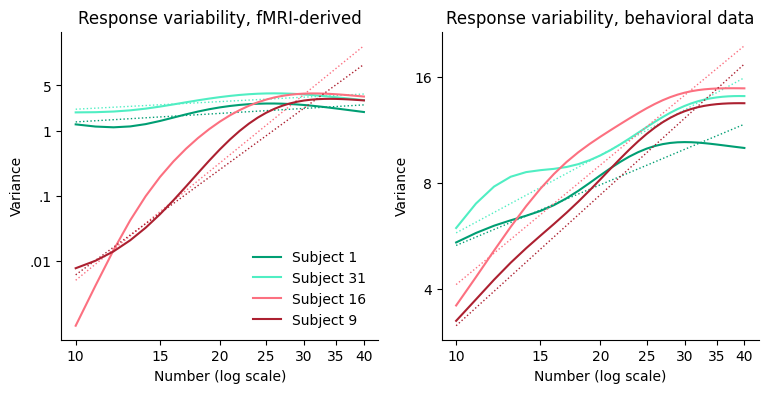

In [242]:
model_label = 31
cond = WIDE
boundary_buffer = 0
wide_prior = True
c = COLORS_COND[cond] # FOURTH_COLOR
# fig, ax = plt.subplots(figsize=(4, 4))
subjs = set(index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique()).intersection(
    index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique())
subjs = set(subjs) - set((24,))
xxx = index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, subject=subjs, boundary_buffer=boundary_buffer, wide_prior=wide_prior).slope
yyy = index_filter(stan_log_var_n_ols, condition=cond, subject=subjs, boundary_buffer=boundary_buffer).slope
ind = (xxx>=0) & (xxx<=2) & (yyy<=.8)
#print( xxx[ind], yyy[ind] )
ns = np.arange(10, MAX_COND[cond]+1)
ilow = ind[ind].index
ilow = set(ilow) - set([18,32,40,28,30,20,  4])
print(ilow)
ind = (xxx>=4) & (yyy>=.95)
#print( xxx[ind], yyy[ind] )
ihi = ind[ind].index
ihi = set(ihi) - set([14, 13])
print(ihi)
log_ns = np.log(ns)
fig, axs = plt.subplots(ncols=2, figsize=(9, 4))
cols = ['#009E73', '#50EEC3', '#FC7080', '#aC2030', ] # sns.color_palette('colorblind')
conv_w = 0.2
lw = 1.5
qtyFMRI = 'log_var'
qtyStan = 'log_var'
xs = log_ns
ls_reg = ':'
for k,ii in enumerate(ilow):
    xs, ys = smooth_ys(conv_w, xs, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, subject=ii, wide_prior=wide_prior)[qtyFMRI], xs=xs)
    axs[0].plot(xs, ys, c=cols[k], label=f'Subject {ii}', lw=lw)
    slope, intercept = index_filter(fmri_log_var_n_ols, model_label=model_label, condition=cond, boundary_buffer=boundary_buffer, wide_prior=wide_prior).loc[ii][['slope', 'intercept']]
    axs[0].plot(xs, slope*xs + intercept, ls=ls_reg, c=cols[k], lw=1)
    #axs[0].axline((np.log(20), slope*np.log(20) + intercept), slope=slope, c=cols[k], ls=ls_reg, lw=1)
    xs, ys = smooth_ys(conv_w, xs, index_filter(stan_subj_n, condition=cond, subject=ii)[qtyStan], xs=xs)
    axs[1].plot(xs, ys , ls='-', c=cols[k], lw=lw)
    slope, intercept = index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).loc[ii][['slope', 'intercept']]
    axs[1].plot(xs, slope*xs + intercept, ls=ls_reg, c=cols[k], lw=1)
    #axs[1].axline((np.log(20), slope*np.log(20) + intercept), slope=slope, c=cols[k], ls=ls_reg, lw=1)
for k,ij in enumerate(ihi):
    xs, ys = smooth_ys(conv_w, xs, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, subject=ij, wide_prior=wide_prior)[qtyFMRI], xs=xs)
    axs[0].plot(xs,  ys, c=cols[k+2], label=f'Subject {ij}', lw=lw)
    slope, intercept = index_filter(fmri_log_var_n_ols, model_label=model_label, condition=cond, boundary_buffer=boundary_buffer, wide_prior=wide_prior).loc[ij][['slope', 'intercept']]
    axs[0].plot(xs, slope*xs + intercept, ls=ls_reg, c=cols[k+2], lw=1)
    xs, ys = smooth_ys(conv_w, xs, index_filter(stan_subj_n, condition=cond, subject=ij)[qtyStan], xs=xs)
    axs[1].plot(xs, ys , ls='-', c=cols[k+2], lw=lw)
    slope, intercept = index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).loc[ij][['slope', 'intercept']]
    axs[1].plot(xs, slope*xs + intercept, ls=ls_reg, c=cols[k+2], lw=1)
    #axs[0].set_ylim(0,None)
    #axs[1].set_ylim(0,None)
axs[0].legend()
#axs[0].set_yticks([.5, 1, 1.5, 2, ])
for ax in axs:
    ax.set_xlabel('Number (log scale)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Variance')
    xticks = np.array([10, 15, 20, 25, 30, 35, 40])
    ax.set_xticks(np.log(xticks))
    ax.set_xticklabels(xticks)
yticks = np.array(['.01', '.1', 1, 5])
axs[0].set_yticks(np.log([float(y) for y in yticks]))
axs[0].set_yticklabels(yticks)
yticks = np.array([4, 8, 16])
axs[1].set_yticks(np.log(yticks))
axs[1].set_yticklabels(yticks)
axs[0].set_title('Response variability, fMRI-derived')
axs[1].set_title('Response variability, behavioral data')

In [243]:
xs

array([2.30258509, 2.39789527, 2.48490665, 2.56494936, 2.63905733, 2.7080502 , 2.77258872, 2.83321334, 2.89037176, 2.94443898, 2.99573227,
       3.04452244, 3.09104245, 3.13549422, 3.17805383, 3.21887582, 3.25809654, 3.29583687, 3.33220451, 3.36729583, 3.40119738, 3.4339872 ,
       3.4657359 , 3.49650756, 3.52636052, 3.55534806, 3.58351894, 3.61091791, 3.63758616, 3.66356165, 3.68887945])

[31, 1]
[16, 9]
          n         r         CI95%     p-val    BF10     power
pearson  38  0.473496  [0.18, 0.69]  0.002677  15.515  0.868343
           n         r         CI95%     p-val     power
spearman  38  0.415253  [0.11, 0.65]  0.009528  0.753104


Text(0.5, 1.0, 'Response variability, behavioral data')

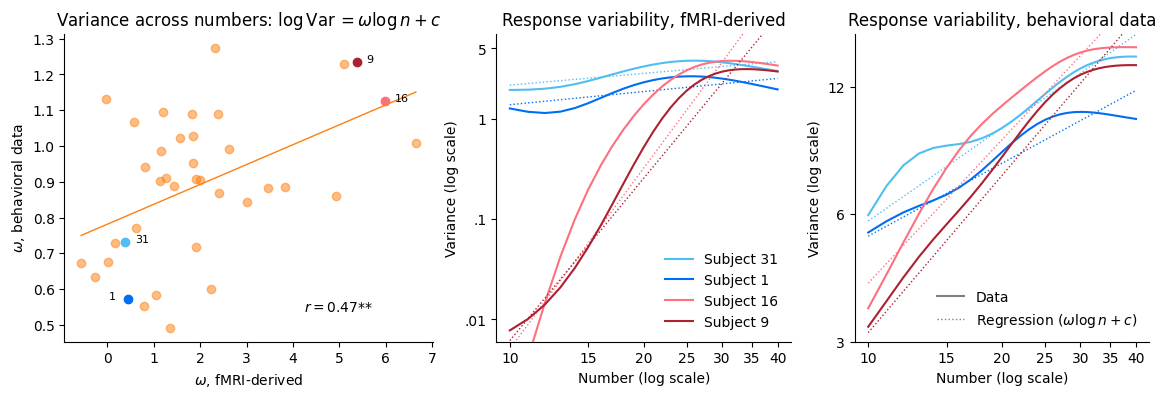

In [244]:
model_label = 31
cond = WIDE
boundary_buffer = 0
wide_prior = True
c = COLORS_COND[cond] # FOURTH_COLOR
fig, axs = plt.subplots(ncols=3, figsize=(14, 4), width_ratios=(5,4,4))
subjs = set(index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique()).intersection(
    index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique())
subjs = set(subjs) - set((24,))
xxx = index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, subject=subjs, boundary_buffer=boundary_buffer, wide_prior=wide_prior).slope
yyy = index_filter(stan_log_var_n_ols, condition=cond, subject=subjs, boundary_buffer=boundary_buffer).slope
if 24 in yyy:
    mm, sd = yyy.drop(24).describe()[['mean', 'std']]
    print('Subject 24:', yyy[24])
    print(f"Other subjects: Mean = {mm:.3f}, SD = {sd:.3f}")
    print(f"Subject 24 is {((yyy[24] - mm) / sd):.2f} SD away from the mean of other subjects.")
ind = (xxx>=0) & (xxx<=2) & (yyy<=.8)
#print( xxx[ind], yyy[ind] )
ns = np.arange(10, MAX_COND[cond]+1)
ilow = ind[ind].index
ilow = set(ilow) - set([18,32,40,28,30,20,  4])
ilow = [31, 1]
print(ilow)
ind = (xxx>=4) & (yyy>=.95)
#print( xxx[ind], yyy[ind] )
ihi = ind[ind].index
ihi = set(ihi) - set([14, 13])
ihi = [16, 9]
print(ihi)
#####
cols = ['#50EEC3', '#009E73', '#FC7080', '#aC2030', ]
cols = ['#50BEF3', '#006EA3', '#FC7080', '#aC2030', ]
cols = ['#50BEF3', '#006EF3', '#FC7080', '#aC2030', ]
cols_sid = {sid:col for sid, col in zip(ilow+ihi, cols)}

#####
ax = axs[0]
r_pearsons = pg.corr(xxx, yyy)
print( r_pearsons ) # method='spearman'
print( pg.corr(xxx, yyy, method='spearman' ) )
ax.scatter(x=xxx[~np.isin(xxx.index, ilow+ihi)], y=yyy[~np.isin(yyy.index, ilow+ihi)], color=c, alpha=.5)
for subj in ilow+ihi:
    ax.scatter(x=xxx[subj], y=yyy[subj], color=cols_sid[subj], alpha=1., label=f'Subject {subj}',) #ec='k', lw=1)
ax.text(xxx.loc[31]+.2, yyy.loc[31], '31', color='k', fontsize=8,)
ax.text(xxx.loc[ 1]-.4, yyy.loc[ 1],  '1', color='k', fontsize=8,)
ax.text(xxx.loc[16]+.2, yyy.loc[16], '16', color='k', fontsize=8,)
ax.text(xxx.loc[ 9]+.2, yyy.loc[ 9],  '9', color='k', fontsize=8,)
# for subj in subjs:
#     ax.text(xxx[subj], yyy[subj], str(subj), color='k', fontsize=8, ha='center', va='center')
#sns.regplot(x=xxx, y=yyy, color=c, ax=ax, scatter_kws={'color': c, 'alpha': .5}, )
res_odr = odr_1dregression(x=xxx, y=yyy)
x_vals = np.linspace(xxx.min(), xxx.max(), 100)
ax.plot(x_vals, odr_pred(res_odr, x_vals), color=c, lw=1,)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Variance across numbers: $\log \operatorname{Var} = \omega \log n + c$')
ax.set_xlabel('$\omega$, fMRI-derived')
ax.set_ylabel('$\omega$, behavioral data')
pv = r_pearsons['p-val'].iloc[0]
ax.text(0.65, 0.1, f'$r = {r_pearsons.r.iloc[0]:.2f}${star_string(pv)}', transform=ax.transAxes)

######
log_qties = True
conv_w = .2 if log_qties else 3
lw = 1.5
ns = np.arange(10+boundary_buffer, MAX_COND[cond]+1-boundary_buffer)
xs = np.log(ns) if log_qties else ns
qtyFMRI = 'log_var' if log_qties else 'sigma'
qtyStan = 'log_var' if log_qties else 'sigma'
for k,ii in enumerate(ilow+ihi):
    xs, ys = smooth_ys(conv_w, xs, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, subject=ii, n=ns, wide_prior=wide_prior)[qtyFMRI], xs=xs)
    axs[1].plot(xs, ys, c=cols[k], label=f'Subject {ii}', lw=lw)
    xs, ys = smooth_ys(conv_w, xs, index_filter(stan_subj_n, condition=cond, subject=ii, n=ns)[qtyStan], xs=xs)
    axs[2].plot(xs, ys , ls='-', c=cols[k], lw=lw)
    if log_qties:
        slope, intercept = index_filter(fmri_log_var_n_ols, model_label=model_label, condition=cond, boundary_buffer=boundary_buffer, wide_prior=wide_prior).loc[ii][['slope', 'intercept']]
        axs[1].plot(xs, slope*xs + intercept, ls=':', c=cols[k], lw=1)
        slope, intercept = index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).loc[ii][['slope', 'intercept']]
        axs[2].plot(xs, slope*xs + intercept, ls=':', c=cols[k], lw=1)
axs[1].legend()
for ax in axs[1:]:
    ax.set_xlabel('Number' + (' (log scale)' if log_qties else ''))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Variance (log scale)' if log_qties else 'Standard deviation')
    if log_qties:
        xticks = np.array([10, 15, 20, 25, 30, 35, 40])
        ax.set_xticks(np.log(xticks))
        ax.set_xticklabels(xticks)
if log_qties:        
    yticks = np.array(['.01', '.1', 1, 5])
    axs[1].set_yticks(np.log([float(y) for y in yticks]))
    axs[1].set_yticklabels(yticks)
    yticks = np.array([3, 6, 12])
    axs[2].set_yticks(np.log(yticks))
    axs[2].set_yticklabels(yticks)
    axs[1].set_ylim(np.log(.006), np.log(7))
    axs[2].set_ylim(np.log(3), np.log(16))
    axs[2].legend([Line2D([0], [0], c='grey', lw=lw), Line2D([0], [0], c='grey', ls=ls_reg, lw=1)],
                  ['Data', 'Regression ($\omega \log n + c$)'], loc='lower right')
else:
    axs[1].set_yticks([.5, 1, 1.5, 2, ])
axs[1].set_title('Response variability, fMRI-derived')
axs[2].set_title('Response variability, behavioral data')
#fig.suptitle('Data from 2025-07-24', x=.1, ha='left')
#fig.savefig(f'figures/variability_across_x.pdf', bbox_inches='tight')

### Average variability per subject in the two conditions

In [245]:
fmri_estimates_avgs

mean_E  mean_error      var_E  mean_abs_error     sigma      bias   log_var
subrange subject wide_prior condition model_label                                                                                
all      1       False      narrow    15           17.500120    0.000120   0.846384        0.644334  0.900933  0.000120 -0.258407
                                      18           17.488188   -0.011812   0.927790        0.717525  0.950007 -0.011812 -0.137512
                                      31           17.492390   -0.007611   0.699289        0.577567  0.821504 -0.007610 -0.434774
                            wide      15           17.479056   -0.020944   1.530476        0.887792  1.209011 -0.020944  0.329207
                                      18           17.481986   -0.018013   1.444085        0.891383  1.180976 -0.018014  0.292836
...                                                      ...         ...        ...             ...       ...       ...       ...
1322     40      True       wide      31           19.878653    2.378652  10.892675        2.626820  3.034281  2.378653  2.029172
         41      False      narrow    31           17.495076   -0.004924   0.073222        0.120924  0.269711 -0.004924 -2.627315
                            wide      31           17.507831    0.007831   0.197967        0.287254  0.443249  0.007830 -1.635689
                 True       narrow    31           17.501067    0.001067   0.075568        0.119520  0.273873  0.001067 -2.597698
                            wide      31           17.515928    0.015928   0.218519        0.298152  0.466768  0.015928 -1.526850

[1540 rows x 7 columns]

In [246]:
stan_avgs

avg_var  avg_sigma  avg_inv_sigma  avg_log_var
subrange condition subject                                                 
all      narrow    1         4.51945    2.09239       0.493517      1.44462
                   2         5.16586    2.23781       0.461120      1.57969
                   3         6.72287    2.54261       0.410002      1.82561
                   4         5.60384    2.33301       0.441210      1.66530
                   5         4.06089    1.95980       0.544212      1.28437
...                              ...        ...            ...          ...
1337     wide      37       11.42540    3.27336       0.326354      2.30604
                   38       12.15280    3.36937       0.318670      2.35911
                   39       10.45430    3.12674       0.344825      2.20760
                   40        9.44498    2.98951       0.353995      2.13403
                   41       13.40340    3.54295       0.302830      2.46118

[507 rows x 4 columns]

In [247]:
index_filter(fmri_estimates_stats, model_label=31, condition=NARROW, wide_prior=True)

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject n                                                                                            
1       10.0  10.476123    0.476123  1.055120        0.476123  1.027190  0.476123  0.053655  2.302585
        11.0  11.102278    0.102277  0.226197        0.161752  0.475602  0.102278 -1.486347  2.397895
        12.0  12.135842    0.135843  0.222560        0.270570  0.471763  0.135842 -1.502556  2.484907
        13.0  13.167693    0.167693  0.601260        0.497615  0.775410  0.167693 -0.508727  2.564949
        14.0  14.264460    0.264460  0.627663        0.598814  0.792252  0.264460 -0.465753  2.639057
...                 ...         ...       ...             ...       ...       ...       ...       ...
41      36.0  36.040240    0.040241  0.419236        0.492639  0.647484  0.040240 -0.869322  3.583519
        37.0  37.033882    0.033881  0.462194        0.495027  0.679849  0.033882 -0.771770  3.610918
        38.0  37.960120   -0.039878  0.377232        0.471308  0.614192 -0.039880 -0.974894  3.637586
        39.0  38.804688   -0.195312  0.319548        0.419453  0.565286 -0.195312 -1.140847  3.663562
        40.0  39.421150   -0.578851  0.284618        0.578851  0.533496 -0.578850 -1.256606  3.688879

[1209 rows x 8 columns]

In [248]:
index_filter(fmri_estimates_avgs, subrange='all', model_label=31, condition=WIDE, wide_prior=True)

,mean_E,mean_error,var_E,mean_abs_error,sigma,bias,log_var
subject,,,,,,,
1,24.973908,-0.026091,2.157140,1.036317,1.441556,-0.026092,0.685164
2,25.003316,0.003317,2.584188,1.194203,1.586023,0.003316,0.890787
3,25.029654,0.029654,12.048363,2.834360,3.361231,0.029654,2.369016
4,24.984281,-0.015719,1.065748,0.765755,0.998666,-0.015719,-0.106171
5,24.962560,-0.037440,4.878005,1.354795,2.129339,-0.037440,1.423647
6,24.987428,-0.012572,1.487439,0.875143,1.154530,-0.012572,-0.049001
7,24.987649,-0.012351,0.439393,0.455888,0.606936,-0.012351,-1.315784
8,24.980415,-0.019586,1.043692,0.755708,0.960074,-0.019585,-0.287205
9,24.963411,-0.036589,1.895561,0.947382,1.162503,-0.036589,-0.562172


narrow
          n         r        CI95%     p-val    BF10     power
pearson  39  0.482789  [0.25, 1.0]  0.000926  42.514  0.939943
           n         r       CI95%     p-val     power
spearman  39  0.440081  [0.2, 1.0]  0.002527  0.889754
wide
          n         r        CI95%     p-val   BF10     power
pearson  39  0.340508  [0.08, 1.0]  0.016955  3.424  0.695456
           n         r        CI95%     p-val     power
spearman  39  0.339879  [0.08, 1.0]  0.017132  0.693942


Text(0, 0.5, 'Standard deviation, behavioral data')

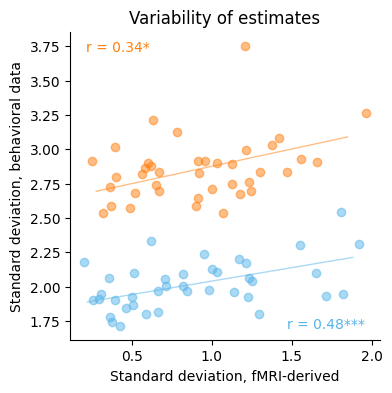

In [279]:
model_label = 31
subrange_per_cond = {NARROW:'narrowrange', WIDE:'narrowrange'} #'narrowrange' # '1124'
wide_prior = False #'cond'
qtyFMRI = 'sigma'; qtySTAN = 'avg_sigma'
#qtyFMRI = 'var_E'; qtySTAN = 'avg_var'
fig, ax = plt.subplots(figsize=(4, 4))
subjs = set(index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label).index.get_level_values('subject').unique()).intersection(
        index_filter(stan_avgs, subrange=subrange).index.get_level_values('subject').unique())
for cond in CONDITIONS:
    subrange = subrange_per_cond[cond]
    wp = (cond==WIDE) if wide_prior == 'cond' else wide_prior  #wp = wide_prior if wide_prior != 'cond' else (cond == WIDE)
    xxx = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition=cond, subject=subjs, wide_prior=wp)[qtyFMRI]
    yyy = index_filter(stan_avgs, subrange=subrange, condition=cond, subject=subjs)[qtySTAN]
    plt.scatter(xxx, yyy, alpha=0.5, color=COLORS_COND[cond], )
    res_odr = odr_1dregression(x=xxx, y=yyy)
    x_vals = np.array([np.percentile(xxx, 1), np.percentile(xxx, 99)])
    plt.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=COLORS_COND[cond], )
    print(cond)
    r_pearson = pg.corr(xxx, yyy, alternative='greater')
    print(r_pearson)
    print(pg.corr(xxx, yyy, method='spearman', alternative='greater' ))
    pv = r_pearson['p-val'].iloc[0]
    ax.text({NARROW:.95, WIDE:.05}[cond], {NARROW:.05, WIDE:.95}[cond], f"r = {r_pearson.r.iloc[0]:.2f}{star_string(pv)}", transform=ax.transAxes, va='center', color=COLORS_COND[cond],
            ha='right' if cond == NARROW else 'left',  )

# for subj in subjs:
#     x1 = obvious_index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition='narrow')[qtyFMRI][subj]
#     x2 = obvious_index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition='wide')[qtyFMRI][subj]
#     y1 = index_filter(stan_avgs, subrange=subrange, condition='narrow')[qtySTAN][subj]
#     y2 = index_filter(stan_avgs, subrange=subrange, condition='wide')[qtySTAN][subj]
#     plt.plot([x1, x2], [y1, y2],
#         #color='limegreen' if (x2 > x1 and y2 > y1) else "#F75656", # if (x2 < x1 and y2 < y1) else 'gray',
#         color='grey',
#         alpha=0.5, linewidth=1
#     )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Variability of estimates')
ax.set_xlabel('Standard deviation, fMRI-derived')
ax.set_ylabel('Standard deviation, behavioral data')

#fig.savefig(f'figures/std_dev_fmri_vs_behavior.pdf', bbox_inches='tight')

narrow
          n         r        CI95%     p-val    BF10     power
pearson  39  0.482789  [0.25, 1.0]  0.000926  42.514  0.939943
wide
          n         r        CI95%     p-val   BF10     power
pearson  39  0.340508  [0.08, 1.0]  0.016955  3.424  0.695456


Text(1.1, 2, 'r = 0.34*')

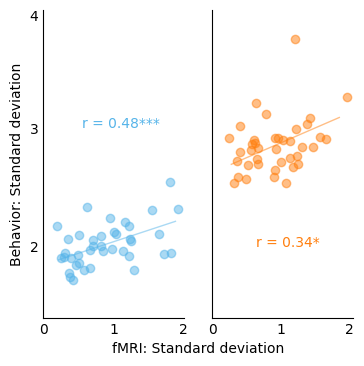

In [447]:
model_label = 31
subrange = 'narrowrange' # '1124'
qtyFMRI = 'sigma'; qtySTAN = 'avg_sigma'
wide_prior = False
#qtyFMRI = 'var_E'; qtySTAN = 'avg_var'
fig, axs = plt.subplots(figsize=(4,4), ncols=2, sharey=True)
subjs = set(index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label).index.get_level_values('subject').unique()).intersection(
        index_filter(stan_avgs, subrange=subrange).index.get_level_values('subject').unique())
rs = {}
for ic,cond in enumerate(CONDITIONS):
    ax = axs[ic]
    xxx = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition=cond, subject=subjs, wide_prior=wide_prior)[qtyFMRI]
    yyy = index_filter(stan_avgs, subrange=subrange, condition=cond, subject=subjs)[qtySTAN]
    ax.scatter(xxx, yyy, alpha=0.5, color=COLORS_COND[cond], )
    res_odr = odr_1dregression(x=xxx, y=yyy)
    x_vals = np.array([np.percentile(xxx, 1), np.percentile(xxx, 99)])
    ax.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=COLORS_COND[cond], )
    print(cond)
    r_pearson = pg.corr(xxx, yyy, alternative='greater')
    rs[cond] = r_pearson
    print(r_pearson)
    #print(pg.corr(xxx, yyy, method='spearman', alternative='greater' ))
    ax.tick_params(axis='both', length=0)
    ax.set_xlim(0,None)
sns.despine(fig)
axs[0].set_ylabel('Behavior: Standard deviation')
axs[0].set_yticks([2, 3, 4])
axs[0].get_yticklabels()[2].set_va('top')
axs[0].set_ylim(1.4, 4)
axs[0].set_xlabel('fMRI: Standard deviation', x=1.1)
axs[0].text(1.1, 3, f"r = {rs[NARROW].r.iloc[0]:.2f}{star_string(rs[NARROW]['p-val'].iloc[0])}", color=COLORS_COND[NARROW], ha='center')
axs[1].text(1.1, 2, f"r = {rs[WIDE].r.iloc[0]:.2f}{star_string(rs[WIDE]['p-val'].iloc[0])}", color=COLORS_COND[WIDE], ha='center')

In [433]:
axs[0].set_yticks([2, 3, 4])[2]

### Delta of variability across conditions

In [116]:
stan_delta_avgs

avg_var_delta_wn  avg_sigma_delta_wn  avg_inv_sigma_delta_wn  avg_log_var_delta_wn
subrange subject                                                                                    
all      1                 5.15763            0.930260               -0.142391              0.708770
         2                 5.30707            0.899574               -0.118359              0.638659
         3                 7.49721            1.102880               -0.115140              0.690660
         4                 6.19574            1.007780               -0.121979              0.686574
         5                 8.78271            1.480780               -0.219505              1.088590
...                            ...                 ...                     ...                   ...
1322     37                3.33320            0.634901               -0.109107              0.511716
         38                3.86734            0.758189               -0.133972              0.623126
         39                4.27522            0.851334               -0.167210              0.728464
         40                3.06131            0.597327               -0.105037              0.489369
         41                7.36404            1.255340               -0.186879              0.931208

[195 rows x 4 columns]

In [117]:
fmri_ests_avgs_deltas

mean_E_diff  mean_error_diff  var_E_diff  mean_abs_error_diff  sigma_diff  bias_diff  log_var_diff
subrange subject wide_prior model_label                                                                                                    
all      1       False      15             -0.021064        -0.021064    0.684092             0.243458    0.308078  -0.021064      0.587614
                            18             -0.006202        -0.006201    0.516294             0.173858    0.230969  -0.006202      0.430348
                            31             -0.026616        -0.026616    0.620749             0.251902    0.304715  -0.026616      0.625707
                 True       31             -0.014349        -0.014349    1.214108             0.330676    0.485950  -0.014349      0.816711
         2       False      15             -0.071168        -0.071167    1.160393             0.300292    0.455214  -0.071168      0.751102
...                                              ...              ...         ...                  ...         ...        ...           ...
1322     40      False      18              0.747404         0.747405   -0.100500             0.083888    0.023001   0.747404      0.137162
                            31              0.727333         0.727333   -0.321273            -0.257752   -0.048860   0.727333      0.029743
                 True       31              2.591344         2.591343    8.592989             1.232115    1.602125   2.591344      1.435584
         41      False      31              0.012754         0.012755    0.124746             0.166330    0.173538   0.012754      0.991627
                 True       31              0.014861         0.014861    0.142951             0.178632    0.192895   0.014861      1.070848

[770 rows x 7 columns]

In [118]:
fmri_ests_avgs_deltas.columns, stan_delta_avgs.columns

(Index(['mean_E_diff', 'mean_error_diff', 'var_E_diff', 'mean_abs_error_diff', 'sigma_diff', 'bias_diff', 'log_var_diff'], dtype='object'),
 Index(['avg_var_delta_wn', 'avg_sigma_delta_wn', 'avg_inv_sigma_delta_wn', 'avg_log_var_delta_wn'], dtype='object'))

In [500]:
zz = []
model_label = 18
wide_prior = False
subjects = index_filter(fmri_ests_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
subjects = set(subjects) - set((24,))
for subrange in ['narrowrange', '1124', '1223', '1322']: # 'all', 
    for (a,b) in [
                (f'var_E_diff', 'avg_var_delta_wn'),
                (f'sigma_diff', 'avg_sigma_delta_wn'),
                (f'log_var_diff', 'avg_log_var_delta_wn'),
                ]:
        #print(a,b)
        cc = pg.corr(index_filter(fmri_ests_avgs_deltas, subrange=subrange, model_label=model_label, subject=subjects, wide_prior=wide_prior)[a], # model_label=15
                     index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[b],
                     #method='spearman',
                     alternative='greater'
                     )
        if cc.r.values[0] < 0:
            continue
        #print( cc )
        cc.insert(0, 'stan_deltas', b)
        cc.insert(0, 'fmri_deltas', a)
        cc.insert(0, 'subrange', subrange)
        zz.append(cc)
        #print()
pd.concat(zz).sort_values(by='p-val')

,subrange,fmri_deltas,stan_deltas,n,r,CI95%,p-val,BF10,power
pearson,1124,sigma_diff,avg_sigma_delta_wn,37,0.397211,"[0.14, 1.0]",0.007460,7.025,0.799460
pearson,1223,sigma_diff,avg_sigma_delta_wn,37,0.380115,"[0.12, 1.0]",0.010153,5.401,0.764508
pearson,1124,log_var_diff,avg_log_var_delta_wn,37,0.361096,"[0.1, 1.0]",0.014055,4.099,0.722665
pearson,1223,log_var_diff,avg_log_var_delta_wn,37,0.359630,"[0.09, 1.0]",0.014401,4.016,0.719323
pearson,narrowrange,sigma_diff,avg_sigma_delta_wn,37,0.325473,"[0.06, 1.0]",0.024666,2.556,0.637724
pearson,1322,log_var_diff,avg_log_var_delta_wn,37,0.295971,"[0.02, 1.0]",0.037651,1.799,0.563389
pearson,1124,var_E_diff,avg_var_delta_wn,37,0.288592,"[0.01, 1.0]",0.041614,1.656,0.544556
pearson,1322,sigma_diff,avg_sigma_delta_wn,37,0.272002,"[-0.0, 1.0]",0.051698,1.385,0.502230
pearson,1223,var_E_diff,avg_var_delta_wn,37,0.265200,"[-0.01, 1.0]",0.056332,1.291,0.484961
pearson,narrowrange,log_var_diff,avg_log_var_delta_wn,37,0.261562,"[-0.01, 1.0]",0.058935,1.244,0.475761


          n         r        CI95%     p-val   BF10     power
pearson  37  0.325473  [0.06, 1.0]  0.024666  2.556  0.637724
           n         r        CI95%    p-val    power
spearman  37  0.340683  [0.07, 1.0]  0.01954  0.67486


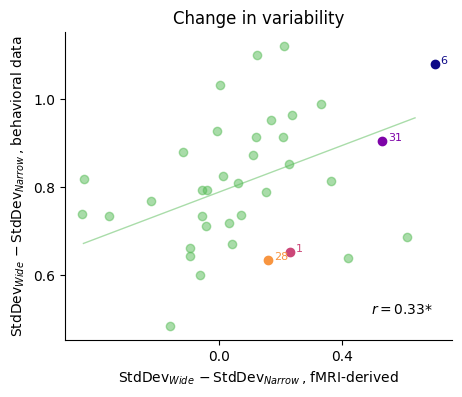

In [524]:
subrange = 'narrowrange'
model_label = 18
wide_prior = False
fig, ax = plt.subplots(figsize=(5,4))
subjects = index_filter(fmri_ests_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
subjects = set(subjects) - set((24,))
qtyX, qtyY = 'sigma_diff', 'avg_sigma_delta_wn'
#qtyX, qtyY = 'var_E_diff', 'avg_var_delta_wn'
xxx = index_filter(fmri_ests_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label, wide_prior=wide_prior)[qtyX] # model_label=15,
yyy = index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[qtyY]
if 24 in yyy:
    mm, sd = yyy.drop(24).describe()[['mean', 'std']]
    print('Subject 24:', yyy[24])
    print(f"Other subjects: Mean = {mm:.3f}, SD = {sd:.3f}")
    print(f"Subject 24 is {((yyy[24] - mm) / sd):.2f} SD away from the mean of other subjects.")
iis = [6, 31, 1, 28 ]
ax.scatter(x=xxx[~np.isin(xxx.index, iis)], y=yyy[~np.isin(yyy.index, iis)], color=THIRD_COLOR, alpha=.5)
# for subj in subjects:
#     ax.text(xxx[subj], yyy[subj], str(subj), color='k', fontsize=8, ha='center', va='center')
cols = cm.plasma
for k, i in enumerate(iis):
    ax.scatter(x=xxx.loc[i], y=yyy.loc[i], color=cols(k / len(iis)),)
    ax.text(xxx[i]+.02, yyy[i], str(i), color=cols(k / len(iis)), fontsize=8,)
#sns.regplot(x=xxx, y=yyy, color=THIRD_COLOR, ax=ax)
res_odr = odr_1dregression(x=xxx, y=yyy)
x_vals = np.array([np.percentile(xxx, 2), np.percentile(xxx, 98)])
ax.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=THIRD_COLOR, )
p_corr_res = pg.corr(xxx, yyy, alternative='greater');
print(p_corr_res)
s_corr_res = pg.corr(xxx, yyy, method='spearman', alternative='greater')
print(s_corr_res)
#ax.set_title(f"Pearson r = {p_corr_res.r.iloc[0]:.2f} (pv = {p_corr_res['p-val'].iloc[0]:.3f})\n"
#          f"Spearman r = {s_corr_res.r.iloc[0]:.2f} (pv = {s_corr_res['p-val'].iloc[0]:.3f}) ({subrange})")
#suptitle(f"Model {model_label}", y=1.05)
ax.set_title('Change in variability')
ax.set_xlabel('$\operatorname{StdDev}_{Wide} - \operatorname{StdDev}_{Narrow}$, fMRI-derived')
ax.set_ylabel('$\operatorname{StdDev}_{Wide} - \operatorname{StdDev}_{Narrow}$, behavioral data')
pv = p_corr_res['p-val'].iloc[0]
ax.text(0.95, 0.1, f"$r = {p_corr_res.r.iloc[0]:.2f}${star_string(pv)}", transform=ax.transAxes, va='center', ha='right', ) #fontsize=12, )
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([0, .4])
ax.set_yticks([.6, .8, 1])
#fig.savefig(f'figures/delta_stddev_fmri_vs_behavior.pdf', bbox_inches='tight')


Text(0.5, 1.0, 'Response variability, behavioral data')

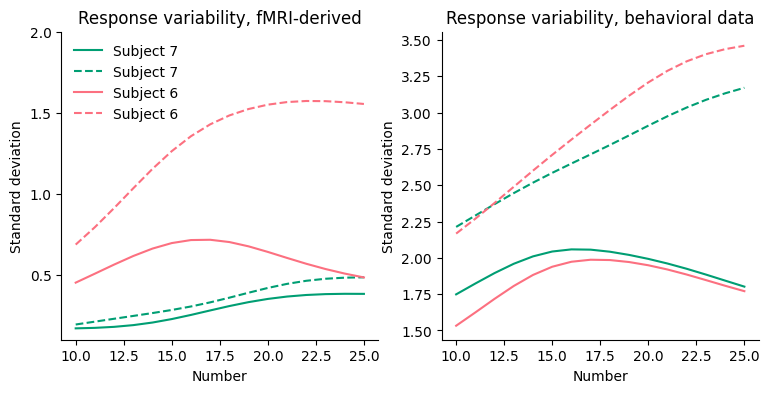

In [121]:
subrange = '1124'
model_label = 18
wide_prior = False
subjects = index_filter(fmri_ests_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
subjects = set(subjects) - set((24,))
qtyX, qtyY = 'sigma_diff', 'avg_sigma_delta_wn'
#qtyX, qtyY = 'var_E_diff', 'avg_var_delta_wn'
xxx = index_filter(fmri_ests_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label, wide_prior=wide_prior)[qtyX] # model_label=15,
yyy = index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[qtyY]
# ind = (xxx>=0) & (xxx<=2) & (yyy<=.8)
# #print( xxx[ind], yyy[ind] )
# ns = np.arange(10, MAX_COND[cond]+1)
# ilow = ind[ind].index
# ilow = set(ilow) - set([18,32,40,28,30,20,  4])
# print(ilow)
ilow = [7,]
# ind = (xxx>=4) & (yyy>=.95)
# #print( xxx[ind], yyy[ind] )
# ihi = ind[ind].index
# ihi = set(ihi) - set([14, 13])
# print(ihi)
ihi = [6,]
ns = np.arange(10, 25+1)
#logns = np.log(ns)
fig, axs = plt.subplots(ncols=2, figsize=(9, 4))
cols = ['#009E73', '#50EEC3', '#FC7080', '#aC2030', ] # sns.color_palette('colorblind')
conv_w = 3
lw = 1.5
for k,ii in enumerate(ilow):
    for cond in CONDITIONS:
        ls = '-' if cond == NARROW else '--'
        xs, ys = smooth_ys(conv_w, ns, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, n=ns, subject=ii).sigma, xs=ns)
        axs[0].plot(ns, ys, c=cols[k], label=f'Subject {ii}', lw=lw, ls=ls)
        xs, ys = smooth_ys(conv_w, ns, index_filter(stan_subj_n, condition=cond, n=ns, subject=ii).sigma, xs=ns)
        axs[1].plot(xs, ys , c=cols[k], lw=lw, ls=ls)
for k,ij in enumerate(ihi):
    for cond in CONDITIONS:
        ls = '-' if cond == NARROW else '--'
        xs, ys = smooth_ys(conv_w, ns, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, n=ns, subject=ij).sigma, xs=ns)
        axs[0].plot(ns,  ys, c=cols[k+2], label=f'Subject {ij}', lw=lw, ls=ls)
        xs, ys = smooth_ys(conv_w, ns, index_filter(stan_subj_n, condition=cond, n=ns, subject=ij).sigma, xs=ns)
        #print(xs)
        axs[1].plot(xs, ys , c=cols[k+2], lw=lw, ls=ls)
    #axs[0].set_ylim(0,None)
    #axs[1].set_ylim(0,None)
axs[0].legend()
axs[0].set_yticks([.5, 1, 1.5, 2, ])
for ax in axs:
    ax.set_xlabel('Number')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Standard deviation')
axs[0].set_title('Response variability, fMRI-derived')
axs[1].set_title('Response variability, behavioral data')

In [122]:
index_filter(fmri_ests_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label)[qtyX]

subject  wide_prior
1        False         0.213351
2        False         0.654539
3        False         0.027667
4        False         0.271453
5        False        -0.005073
6        False         0.717576
7        False         0.070646
8        False         0.230557
9        False        -0.099252
10       False         0.433390
12       False         0.069483
13       False        -0.058842
14       False         0.056267
15       False         0.119993
16       False        -0.014769
17       False         0.015045
18       False        -0.196697
19       False        -0.135336
20       False         0.357782
21       False        -0.045303
22       False         0.247028
25       False        -0.370763
26       False         0.130845
27       False        -0.187617
28       False         0.136972
29       False        -0.035868
30       False         0.400579
31       False         0.524127
32       False         0.217499
33       False        -0.159036
34       False      

Index([9, 13, 16, 18, 19, 21, 25, 27, 29, 33, 36, 37, 39, 40], dtype='int64', name='subject')


Text(0.5, 1.0, 'Change in variability, behavioral data')

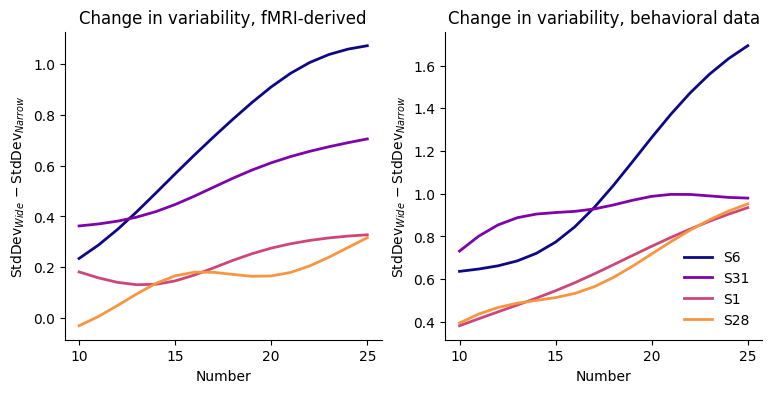

In [514]:
subrange = 'narrowrange'
model_label = 18
wide_prior = False
subjects = index_filter(fmri_ests_avgs_deltas, model_label=model_label, wide_prior=wide_prior).index.get_level_values('subject').unique()
subjects = set(subjects) - set((24,))
qtyX, qtyY = 'sigma_diff', 'avg_sigma_delta_wn'
#qtyX, qtyY = 'var_E_diff', 'avg_var_delta_wn'
xxx = index_filter(fmri_ests_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label, wide_prior=wide_prior)[qtyX] # model_label=15,
print(xxx[xxx<0].index)
iis =  [6, 7, 30]
iis = [1,2,6,7,8,12,17,22,28,30,31,38,]
iis = [6, 31, 1, 28 ] # 2, 30
#iis += [7,8,12,17,38,]
ns = np.arange(10, 25+1)
fig, axs = plt.subplots(ncols=2, figsize=(9, 4))
#cols = ['#009E73', '#50EEC3', '#FC7080', '#aC2030', ] # sns.color_palette('colorblind')
#cols = ['#50BEF3', '#006EF3', '#FC7080', '#aC2030', '#FFB300', '#D55E00', ] # sns.color_palette('colorblind')
cols = cm.plasma
conv_w = 3
lw = 2.
ls = '-' # 
for k,ii in enumerate(iis):
    xs, ys = smooth_ys(conv_w, ns, index_filter(fmri_estimates_deltas, model_label=model_label, n=ns, wide_prior=wide_prior, subject=ii).sigma_diff, xs=ns)
    axs[0].plot(ns, ys, c=cols(k/(len(iis))), label=f'S{ii}', lw=lw, ls=ls)
    #axs[0].text(ns[-1]+.5, ys[-1], str(ii), color=cols(k/(len(iis))), fontsize=8, ha='left', va='center')
    xs, ys = smooth_ys(conv_w, ns, index_filter(stan_deltas_subj_n, n=ns, subject=ii).delta_sigma, xs=ns)
    axs[1].plot(xs, ys , c=cols(k/(len(iis))), label=f'S{ii}', lw=lw, ls=ls)
    #axs[1].text(xs[-1]+.5, ys[-1], str(ii), color=cols(k/(len(iis))), fontsize=8, ha='left', va='center')
axs[1].legend(loc='lower right', )
#axs[0].set_yticks([.5, 1, 1.5, 2, ])
for ax in axs:
    ax.set_xlabel('Number')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('$\operatorname{StdDev}_{Wide} - \operatorname{StdDev}_{Narrow}$')
    ax.set_xticks([10,15,20,25])
    #ax.set_ylim(0,None)
axs[0].set_title('Change in variability, fMRI-derived')
axs[1].set_title('Change in variability, behavioral data')
#fig.savefig(f'figures/delta_stddev_across_x_examples.pdf', bbox_inches='tight')

In [510]:
index_filter(fmri_ests_avgs_deltas, model_label=model_label)

mean_E_diff  mean_error_diff  var_E_diff  mean_abs_error_diff  sigma_diff  bias_diff  log_var_diff
subrange subject wide_prior                                                                                                    
all      1       False         -0.006202        -0.006201    0.516294             0.173858    0.230969  -0.006202      0.430348
         2       False         -0.064784        -0.064783    1.686322             0.402890    0.613765  -0.064784      0.944242
         3       False         -0.119071        -0.119071    0.053845             0.889576    0.031338  -0.119071      0.051404
         4       False         -0.040410        -0.040410    0.091755             0.275384    0.152241  -0.040410      0.648340
         5       False         -0.088557        -0.088557    0.086196             0.533991    0.003568  -0.088557     -0.071766
...                                  ...              ...         ...                  ...         ...        ...           ...
1337     36      False          0.069362         0.069362   -0.966886             0.018001   -0.278015   0.069362     -0.321609
         37      False          0.025934         0.025934   -0.250941            -0.173632   -0.153470   0.025934     -0.419289
         38      False         -0.011636        -0.011636    0.149742             0.206373    0.211313  -0.011636      1.243999
         39      False          0.022953         0.022953   -0.054752            -0.088324   -0.050596   0.022953     -0.193992
         40      False          0.082391         0.082392   -1.045301             0.530153   -0.217893   0.082391     -0.133399

[304 rows x 7 columns]

In [124]:
print( index_filter(stan_delta_avgs, subrange='1124').loc[24].avg_sigma_delta_wn )
stan.loc['delta_avg_sigma_s_1124[22]']

1.65704


Mean           1.657040
MCSE           0.001674
StdDev         0.193311
5%             1.347320
50%            1.652260
95%            1.976020
N_Eff      13330.100000
N_Eff/s       18.635500
R_hat          1.000310
Name: delta_avg_sigma_s_1124[22], dtype: float64

In [125]:
stan

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-27492.900000,1.445580,64.076200,-27598.500000,-27492.700000,-27387.400000,1964.75,2.74674,1.005410
z_m_0_15[1],0.114643,0.000610,0.022097,0.078647,0.114326,0.150892,1313.64,1.83648,1.006480
z_m_0_15[2],0.099765,0.000491,0.021970,0.063631,0.099903,0.135862,2005.60,2.80384,1.002830
z_m_0_15[3],0.116497,0.000451,0.022825,0.077950,0.116756,0.153092,2565.87,3.58710,1.004710
z_m_0_15[4],0.101402,0.000490,0.022985,0.063149,0.101322,0.139929,2202.59,3.07923,1.003830
...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],0.511716,0.001204,0.155589,0.254324,0.512230,0.766236,16711.80,23.36320,0.999623
delta_avg_log_var_s_1322[36],0.623126,0.001238,0.153333,0.369549,0.623440,0.874242,15338.40,21.44320,1.000040
delta_avg_log_var_s_1322[37],0.728464,0.001248,0.157262,0.470623,0.728124,0.988688,15884.40,22.20650,0.999400
delta_avg_log_var_s_1322[38],0.489369,0.001246,0.158180,0.232830,0.489670,0.753400,16118.80,22.53420,0.999705


### Mixed effects

In [126]:
model_label = 31
df = index_filter(fmri_estimates_deltas, model_label=model_label, n=range(10,26), wide_prior=False).join( stan_deltas_subj_n, )
df.reset_index(inplace=True)
df

,subject,n,mean_E_diff,mean_error_diff,var_E_diff,mean_abs_error_diff,sigma_diff,bias_diff,log_var_diff,log_n,delta_inv_sigma,delta_log_var,delta_sigma,delta_var
0,1,10.0,-0.149253,-0.149253,0.184640,-0.149253,0.083363,-0.149253,0.150622,2.302585,0.039617,-0.143989,-0.132369,-0.49171
1,1,11.0,0.085628,0.085627,0.277683,0.050928,0.234558,0.085628,0.803148,2.397895,-0.179151,0.703384,0.714987,3.01231
2,1,12.0,0.070600,0.070600,0.155371,0.060335,0.123770,0.070600,0.395669,2.484907,-0.037559,0.201584,0.276887,1.56000
3,1,13.0,0.206186,0.206187,-0.053970,0.008114,-0.032070,0.206186,-0.076237,2.564949,-0.110814,0.527151,0.646630,3.27560
4,1,14.0,-0.066757,-0.066756,0.188810,-0.009392,0.110290,-0.066757,0.258055,2.639057,-0.100433,0.480595,0.596936,3.08593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,41,21.0,-0.016954,-0.016954,0.149305,0.179475,0.200552,-0.016954,1.104820,3.044522,-0.370047,1.855090,2.576320,15.77880
620,41,22.0,-0.015706,-0.015705,0.144728,0.171930,0.192030,-0.015706,1.042124,3.091042,-0.141453,0.591072,0.645295,2.95215
621,41,23.0,-0.015842,-0.015843,0.142645,0.174090,0.196835,-0.015842,1.114406,3.135494,-0.184015,0.872922,1.086330,5.69239
622,41,24.0,-0.038348,-0.038347,0.088001,0.126154,0.132808,-0.038348,0.812713,3.178054,-0.308549,1.537040,2.069030,12.01060


In [127]:
#qty_beh = 'delta_log_inv_var'; qty_fmri = 'log_var_diff'
qty_beh = 'delta_sigma'; qty_fmri = 'sigma_diff'
model = smf.mixedlm(f"{qty_beh} ~ {qty_fmri}", df, groups="n",
                    #re_formula=f"~ {qty_fmri}"
                    #re_formula=f"~ log_n"
                    #re_formula=f"~ {qty_fmri} + n"
                    )
result = model.fit()
print( result.summary() )

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: delta_sigma
No. Observations: 624     Method:             REML       
No. Groups:       16      Scale:              0.2184     
Min. group size:  39      Log-Likelihood:     -437.9520  
Max. group size:  39      Converged:          Yes        
Mean group size:  39.0                                   
----------------------------------------------------------
             Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept    0.836     0.087  9.629  0.000   0.666   1.006
sigma_diff   0.039     0.049  0.809  0.419  -0.056   0.135
n Var        0.115     0.096                              



In [128]:
# Regress out the effect of x (categorical) from both variables
resid_beh = smf.ols(f"{qty_beh} ~ C(n)", data=df).fit().resid
resid_fmri = smf.ols(f"{qty_fmri} ~ C(n)", data=df).fit().resid
df[f'{qty_beh}_adj'] = resid_beh
df[f'{qty_fmri}_adj'] = resid_fmri
model = smf.mixedlm(f"{qty_beh}_adj ~ {qty_fmri}_adj", df,
                    groups="subject",
                    re_formula=f"~ {qty_fmri}_adj")
result = model.fit()
result.summary()


/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  wa

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Mixed Linear Model Regression Results
=======================================================================
Model:                MixedLM    Dependent Variable:    delta_sigma_adj
No. Observations:     624        Method:                REML           
No. Groups:           39         Scale:                 0.1868         
Min. group size:      16         Log-Likelihood:        -389.0929      
Max. group size:      16         Converged:             Yes            
Mean group size:      16.0                                             
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                    -0.001    0.032 -0.016 0.987 -0.063  0.062
sigma_diff_adj               -0.027    0.057 -0.471 0.637 -0.138  0.084
subject Var                   0.028    0.022                           
subject x sigma_diff_adj Cov  0.002    0.023                           
sigma_diff_adj Var            0.000                                    
=======================================================================

"""

## Stan vs fMRI-Fisher-information

### Avg variability

In [129]:
fisher_info_avgs

fi    log_fi   sqrt_fi     inv_fi  inv_sqrt_fi
subrange subject model_label condition                                                      
all      1       15          narrow     0.855621 -1.172242  0.706231   5.068577     2.080115
                             wide       0.251763 -2.447645  0.377351  18.130914     3.942094
                 18          narrow     0.843114 -1.413441  0.656623   6.623666     2.375812
                             wide       0.274819 -2.578914  0.368716  21.365276     4.262218
                 31          narrow     0.516915 -1.606773  0.541309   6.827314     2.467959
...                                          ...       ...       ...        ...          ...
1322     41      15          wide       0.701192 -0.361723  0.835927   1.444619     1.200130
                 18          narrow     2.052164  0.713177  1.430516   0.493025     0.701097
                             wide       0.666308 -0.407681  0.815933   1.505791     1.226607
                 31          narrow     1.587406  0.455942  1.258020   0.638048     0.797441
                             wide       0.772112 -0.283385  0.873105   1.356512     1.158676

[1170 rows x 5 columns]

In [130]:
stan_avgs

avg_var  avg_sigma  avg_inv_sigma  avg_log_var
subrange condition subject                                                 
all      narrow    1         4.52248    2.09302       0.493399      1.44517
                   2         5.15975    2.23632       0.461476      1.57824
                   3         6.71746    2.54162       0.410169      1.82483
                   4         5.60873    2.33398       0.441039      1.66610
                   5         4.05996    1.95986       0.544047      1.28471
...                              ...        ...            ...          ...
1322     wide      37        8.01352    2.75677       0.381774      1.97627
                   38        8.17100    2.79339       0.375312      2.00766
                   39        7.74027    2.67513       0.404783      1.88849
                   40        7.38971    2.64592       0.398512      1.89267
                   41       11.39140    3.22656       0.338764      2.25291

[390 rows x 4 columns]

In [131]:
index_filter(stan_avgs, subrange='all', condition='narrow') #.loc[1]

,avg_var,avg_sigma,avg_inv_sigma,avg_log_var
subject,,,,
1,4.52248,2.09302,0.493399,1.44517
2,5.15975,2.23632,0.461476,1.57824
3,6.71746,2.54162,0.410169,1.82483
4,5.60873,2.33398,0.441039,1.66610
5,4.05996,1.95986,0.544047,1.28471
6,3.52560,1.81879,0.596176,1.12221
7,3.88444,1.91209,0.562066,1.22884
8,4.56418,2.09629,0.495748,1.44203
9,3.89088,1.92620,0.546332,1.26130


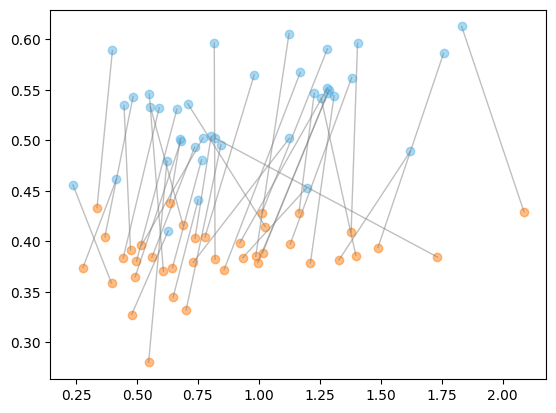

In [133]:
model_label = 31
subrange = 'narrowrange'
for cond in CONDITIONS:
    plt.scatter(index_filter(fisher_info_avgs, subrange=subrange, model_label=model_label, condition=cond).sqrt_fi,
                index_filter(stan_avgs, subrange=subrange, condition=cond).avg_inv_sigma, alpha=0.5, color=COLORS_COND[cond], )
for subj in stan_avgs.index.get_level_values('subject').unique():
    plt.plot(
        [index_filter(fisher_info_avgs, subrange=subrange, model_label=model_label, condition='narrow').sqrt_fi[subj],
         index_filter(fisher_info_avgs, subrange=subrange, model_label=model_label, condition='wide').sqrt_fi[subj]],
        [index_filter(stan_avgs, subrange=subrange, condition='narrow').avg_inv_sigma[subj], index_filter(stan_avgs, subrange=subrange, condition='wide').avg_inv_sigma[subj]],
        color='gray', alpha=0.5, linewidth=1
    )

### Deltas

In [134]:
fisher_info_avgs_deltas.columns, stan_delta_avgs.columns

(Index(['fi_delta_wn', 'log_fi_delta_wn', 'sqrt_fi_delta_wn', 'inv_fi_delta_wn', 'inv_sqrt_fi_delta_wn'], dtype='object'),
 Index(['avg_var_delta_wn', 'avg_sigma_delta_wn', 'avg_inv_sigma_delta_wn', 'avg_log_var_delta_wn'], dtype='object'))

In [135]:
zz = []
model_label = 18
subjects = index_filter(fisher_info_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
# /!\ Filtering out subject
#subjects = set(subjects) - set((36,)) # 24, 33, 36
for subrange in ['narrowrange', '1124', '1223', '1322']: # 'all', 
    for (a,b) in [(f'inv_fi_delta_wn', 'avg_var_delta_wn'),
                  (f'inv_sqrt_fi_delta_wn', 'avg_sigma_delta_wn'),
                  (f'log_fi_delta_wn', 'avg_log_var_delta_wn'),
                  (f'sqrt_fi_delta_wn', 'avg_inv_sigma_delta_wn'),
        ]:
        #print(a,b)
        cc = pg.corr(index_filter(fisher_info_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label)[a], # model_label=15, 
                     index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[b],
                     #method='spearman', #'pearson', #'spearman', #
                     method='pearson',
                     alternative='greater' 
                     )
        if cc.r.values[0] < 0:
             continue
        #print( cc )
        cc.insert(0, 'stan_deltas', b)
        cc.insert(0, 'fmri_deltas', a)
        cc.insert(0, 'subrange', subrange)
        zz.append(cc)
pd.concat(zz).sort_values(by='p-val')

,subrange,fmri_deltas,stan_deltas,n,r,CI95%,p-val,BF10,power
pearson,1223,sqrt_fi_delta_wn,avg_inv_sigma_delta_wn,39,0.225647,"[-0.04, 1.0]",0.083608,0.912,0.402026
pearson,1322,sqrt_fi_delta_wn,avg_inv_sigma_delta_wn,39,0.216940,"[-0.05, 1.0]",0.092325,0.841,0.380668
pearson,1124,sqrt_fi_delta_wn,avg_inv_sigma_delta_wn,39,0.191834,"[-0.08, 1.0]",0.121014,0.674,0.321711
pearson,narrowrange,sqrt_fi_delta_wn,avg_inv_sigma_delta_wn,39,0.184565,"[-0.09, 1.0]",0.130336,0.634,0.305478


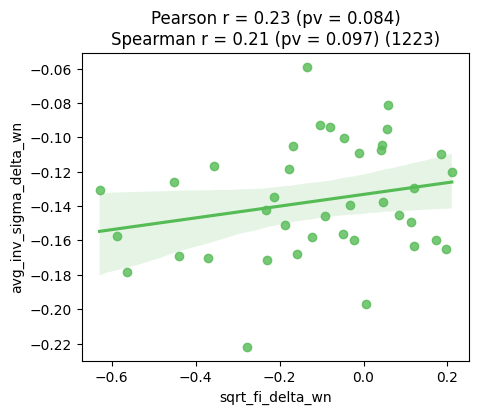

In [136]:
subrange = '1223' # 'narrowrange', '1124', '1223', '1322'
model_label = 18
subjects = index_filter(fisher_info_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
#subjects = set(subjects) - set((36,)) # 24, 33, 36
for (x_fi, y_stan) in [ ('sqrt_fi_delta_wn', 'avg_inv_sigma_delta_wn'),
                       ]:
    plt.figure(figsize=(5,4))
    xxx = index_filter(fisher_info_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label)[x_fi] # model_label=model_label, 
    yyy = index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[y_stan] 
    sns.regplot(x=xxx, y=yyy, color=THIRD_COLOR)
    p_corr_res = pg.corr(xxx, yyy, method='pearson', alternative='greater') # stats.spearmanr(xxx, yyy)
    s_corr_res = pg.corr(xxx, yyy, method='spearman', alternative='greater')
    plt.title(f"Pearson r = {p_corr_res.r.iloc[0]:.2f} (pv = {p_corr_res['p-val'].iloc[0]:.3f})\n"
            f"Spearman r = {s_corr_res.r.iloc[0]:.2f} (pv = {s_corr_res['p-val'].iloc[0]:.3f}) ({subrange})")

### Variability across x

In [137]:
index_filter(fisher_info, model_label=15)

fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n  one_over_n
subject n    condition                                                                           
1       10.0 narrow     5.692601  1.739167  2.385917  0.175667     0.419126  2.302585    0.100000
        11.0 narrow     3.702477  1.309002  1.924182  0.270089     0.519701  2.397895    0.090909
        12.0 narrow     0.979151 -0.021069  0.989521  1.021293     1.010590  2.484907    0.083333
        13.0 narrow     1.185767  0.170390  1.088929  0.843336     0.918333  2.564949    0.076923
        14.0 narrow     0.537878 -0.620123  0.733402  1.859156     1.363509  2.639057    0.071429
...                          ...       ...       ...       ...          ...       ...         ...
41      36.0 wide       0.289024 -1.241244  0.537610  3.459915     1.860085  3.583519    0.027778
        37.0 wide       0.270477 -1.307566  0.520074  3.697166     1.922802  3.610918    0.027027
        38.0 wide       0.253010 -1.374326  0.503001  3.952413     1.988068  3.637586    0.026316
        39.0 wide       0.236594 -1.441408  0.486410  4.226645     2.055881  3.663562    0.025641
        40.0 wide       0.221195 -1.508711  0.470314  4.520899     2.126241  3.688879    0.025000

[1833 rows x 7 columns]

If $\mu(x) = \log(x)$, then $I(x) = (\mu'(x)/\sigma)^2$, i.e., $\log I(x) = -2 \log x - \log \sigma^2$.

In [138]:
z = []
model_label = 31
subjs = index_filter(fisher_info, model_label=model_label).index.get_level_values('subject').unique()
for subject in subjs:
    for cond in CONDITIONS:
        dat = index_filter(fisher_info, subject=subject,condition=cond, model_label=model_label)
        res = quick_ols(y=dat.log_fi, x=dat.log_n)
        z.append([subject, cond, res.params.log_n])
fi_log_I_n_slopes = pd.DataFrame(z, columns=['subject', 'condition', 'slope']).set_index(['subject', 'condition'])
fi_log_I_n_slopes

slope
subject condition          
1       narrow    -2.261165
        wide      -2.582113
2       narrow    -0.559262
        wide      -0.721642
3       narrow    -2.433253
...                     ...
39      wide      -2.130958
40      narrow    -0.935793
        wide      -1.890423
41      narrow    -1.994930
        wide      -1.646614

[78 rows x 1 columns]

In [139]:
#sns.histplot(fi_log_I_n_slopes, x='slope', hue='condition', cumulative=False, element='step', kde=True )
fi_log_I_n_slopes.describe()

,slope
count,78.000000
mean,-2.380600
std,1.432373
min,-5.499747
25%,-3.240333
50%,-2.367059
75%,-1.533794
max,1.301140


In [140]:
stan_log_var_n_ols.index.get_level_values('subject').unique()

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject')

In [141]:
stan_log_var_n_ols

slope  intercept
boundary_buffer subject condition                     
0               1       narrow     0.181748   0.931709
                        wide       0.570174   0.360301
                2       narrow    -0.192697   2.122635
                        wide       0.674359   0.095526
                3       narrow     0.513708   0.373544
...                                     ...        ...
2               39      wide       0.967233  -0.866895
                40      narrow    -0.092619   1.656020
                        wide       0.551357   0.415716
                41      narrow    -0.445457   2.597044
                        wide       0.689094   0.259118

[234 rows x 2 columns]

          n         r          CI95%     p-val   BF10    power
pearson  39  0.067109  [-0.25, 0.37]  0.684803  0.216  0.06884
          n         r         CI95%     p-val   BF10     power
pearson  39  0.439925  [0.14, 0.66]  0.005072  8.788  0.817047


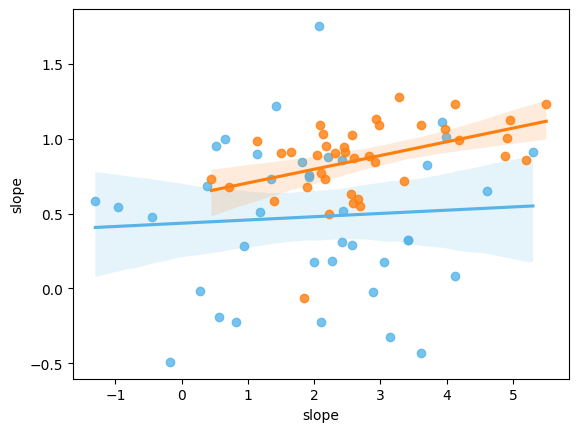

In [142]:
for cond in CONDITIONS:
    xxx = index_filter(-fi_log_I_n_slopes, condition=cond, subject=stan_log_var_n_ols.index.get_level_values('subject').unique()).slope
    yyy = index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=0).slope
    print(pg.corr(xxx, yyy)) # method='spearman'
    sns.regplot(x=xxx, y=yyy, color=COLORS_COND[cond], )

          n        r           CI95%     p-val      BF10     power
pearson  39 -0.65959  [-0.81, -0.43]  0.000005  4584.671  0.997753
          n         r           CI95%         p-val       BF10     power
pearson  39 -0.761393  [-0.87, -0.59]  1.823964e-08  8.261e+05  0.999979


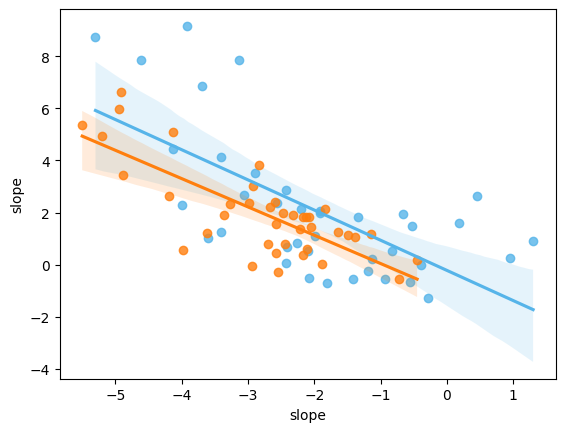

In [143]:
for cond in CONDITIONS:
    xxx = index_filter(fi_log_I_n_slopes, condition=cond, subject=stan_log_var_n_ols.index.get_level_values('subject').unique()).slope
    yyy = index_filter(fmri_log_var_n_ols, condition=cond, model_label=31, boundary_buffer=0, wide_prior=True).slope
    print( pg.corr(xxx, yyy) )
    sns.regplot(x=xxx, y=yyy, color=COLORS_COND[cond], )

# Actual trials fMRI-derived estimates and posteriors

In [144]:
beh.groupby(['subject', 'range', 'n']).response.std().groupby('range').describe()

,count,mean,std,min,25%,50%,75%,max
range,,,,,,,,
narrow,624.0,1.973409,0.578030,0.0,1.601282,1.926321,2.332247,3.777464
wide,1206.0,3.019566,1.237478,0.0,2.168589,2.939195,3.753699,8.895067


In [145]:
fmri_trial_resps

response     n  response_time  error  abs_error  squared_error          E        sd   E_narrow     E_wide  sd_narrow   sd_wide  \
spherical_noise subject condition t                                                                                                                                     
False           1       narrow    1         NaN  11.0            NaN    NaN        NaN            NaN  17.537264  5.247544  17.537264  28.895398   5.247544  6.506345   
                                  2        19.0  23.0       1.317963   -4.0        4.0           16.0  18.092014  2.777531  18.092014  22.410648   2.777531  6.116189   
                                  3        25.0  23.0       0.834244    2.0        2.0            4.0  17.128694  3.821620  17.128694  26.572495   3.821620  7.904282   
                                  4        24.0  22.0       1.701381    2.0        2.0            4.0  13.736838  2.043997  13.736838  14.762215   2.043997  3.323689   
                                  5        17.0  21.0       2.018881   -4.0        4.0           16.0  13.780057  2.001030  13.780057  14.782096   2.001030  3.248581   
...                                         ...   ...            ...    ...        ...            ...        ...       ...        ...        ...        ...       ...   
True            41      wide      236      29.0  24.0       0.283771    5.0        5.0           25.0  12.409954  0.526706  12.409954  12.409954   0.526706  0.526706   
                                  237      39.0  34.0       0.930894    5.0        5.0           25.0  39.976022  0.046817        NaN  39.976022        NaN  0.046817   
                                  238      39.0  32.0       0.817487    7.0        7.0           49.0  39.986598  0.026446        NaN  39.986598        NaN  0.026446   
                                  239      10.0  10.0       1.501680    0.0        0.0            0.0  20.269931  0.700548  20.269931  20.269931   0.700548  0.700548   
                                  240      29.0  24.0       2.085694    5.0        5.0           25.0  15.565216  0.621741  15.565216  15.565216   0.621741  0.621741   

                                      E_median_split sd_median_split  
spherical_noise subject condition t                                   
False           1       narrow    1              low            high  
                                  2              low             low  
                                  3              low            high  
                                  4              low             low  
                                  5              low             low  
...                                              ...             ...  
True            41      wide      236            low             low  
                                  237           high             low  
                                  238           high             low  
                                  239            low            high  
                                  240           high            high  

[37440 rows x 14 columns]

## Bambi -- see dedicated notebook

## Excursions

In [153]:
excursions = beh.groupby(['subject', 'range', 'n'])[['response','range','n']].apply(lambda x: 
                x.response - stan_subj_n.loc[(int(x.index.get_level_values('subject').unique()[0]), x.range.unique()[0], x.n.unique()[0])].m
                )
excursions = excursions.droplevel([0,1,2])
excursions

subject  session  run  trial_nr
01       1        1    7          -1.6191
                       22          0.3809
                       29         -1.6191
                  2    7          -1.6191
                       14         -1.6191
                                    ...  
41       1        7    19          1.7074
         2        1    16          2.7074
                       28          2.7074
                       29          2.7074
                  4    4           0.7074
Name: response, Length: 18720, dtype: float64

In [154]:
beh['excursion'] = excursions
beh

onset  phase  response  nr_frames     n  jitter  start_marker_position  response_time   onset_abs  duration   range  error  \
subject session run trial_nr                                                                                                                                    
01      1       1   1          68.826307      5       NaN       30.0  11.0     6.0                   24.0            NaN   76.378611  0.500457  narrow    NaN   
                    2          76.016292      5      19.0       31.0  23.0     4.0                   14.0       1.317963   83.568595  0.517188  narrow   -4.0   
                    3          87.026471      5      25.0       30.0  23.0     6.0                   11.0       0.834244   94.578775  0.500469  narrow    2.0   
                    4          97.085656      5      24.0       30.0  22.0     5.0                   22.0       1.701381  104.637959  0.500559  narrow    2.0   
                    5         106.744768      5      17.0       31.0  21.0     5.0                   22.0       2.018881  114.297072  0.517009  narrow   -4.0   
...                                  ...    ...       ...        ...   ...     ...                    ...            ...         ...       ...     ...    ...   
41      2       8   26        275.797056      5      25.0       30.0  24.0     4.0                   12.0       1.635028  278.746204  0.500532  narrow    1.0   
                    27        286.857371      5      24.0       30.0  19.0     6.0                   15.0       1.701679  289.806518  0.500510  narrow    5.0   
                    28        296.683059      5      22.0       30.0  17.0     5.0                   15.0       0.100000  299.632207  0.500525  narrow    5.0   
                    29        307.476458      5      19.0       30.0  19.0     6.0                   20.0       1.751607  310.425606  0.500458  narrow    0.0   
                    30        317.202043      5      19.0       30.0  19.0     5.0                   24.0       0.049945  320.151190  0.500598  narrow    0.0   

                              abs_error  squared_error  excursion  
subject session run trial_nr                                       
01      1       1   1               NaN            NaN        NaN  
                    2               4.0           16.0    -3.0545  
                    3               2.0            4.0     2.9455  
                    4               2.0            4.0     1.7868  
                    5               4.0           16.0    -3.2159  
...                                 ...            ...        ...  
41      2       8   26              1.0            1.0     1.2473  
                    27              5.0           25.0     3.1821  
                    28              5.0           25.0     2.8540  
                    29              0.0            0.0    -1.8179  
                    30              0.0            0.0    -1.8179  

[18720 rows x 15 columns]

In [157]:
excursions_fmri = fmri_trial_resps.groupby(['spherical_noise', 'subject', 'condition', 'n'])[['response', 'n']].apply(lambda x: 
                x.response - stan_fmri_subj_n.loc[(int(x.index.get_level_values('subject').unique()[0]),
                                                   x.index.get_level_values('condition').unique()[0],
                                                   x.n.unique()[0],
                                                   x.index.get_level_values('spherical_noise').unique()[0])].m
                )
excursions_fmri = excursions_fmri.droplevel([0,1,2,3])
excursions_fmri

spherical_noise  subject  condition  t  
False            1        narrow     7      -6.7592
                                     22     -4.7592
                                     29     -6.7592
                                     37     -6.7592
                                     44     -6.7592
                                             ...   
True             41       wide       79     14.5037
                                     136    15.5037
                                     148    15.5037
                                     149    15.5037
                                     214    13.5037
Name: response, Length: 37440, dtype: float64

In [159]:
fmri_trial_resps['excursion'] = excursions_fmri
fmri_trial_resps

response     n  response_time  error  abs_error  squared_error          E        sd   E_narrow     E_wide  sd_narrow   sd_wide  \
spherical_noise subject condition t                                                                                                                                     
False           1       narrow    1         NaN  11.0            NaN    NaN        NaN            NaN  17.537264  5.247544  17.537264  28.895398   5.247544  6.506345   
                                  2        19.0  23.0       1.317963   -4.0        4.0           16.0  18.092014  2.777531  18.092014  22.410648   2.777531  6.116189   
                                  3        25.0  23.0       0.834244    2.0        2.0            4.0  17.128694  3.821620  17.128694  26.572495   3.821620  7.904282   
                                  4        24.0  22.0       1.701381    2.0        2.0            4.0  13.736838  2.043997  13.736838  14.762215   2.043997  3.323689   
                                  5        17.0  21.0       2.018881   -4.0        4.0           16.0  13.780057  2.001030  13.780057  14.782096   2.001030  3.248581   
...                                         ...   ...            ...    ...        ...            ...        ...       ...        ...        ...        ...       ...   
True            41      wide      236      29.0  24.0       0.283771    5.0        5.0           25.0  12.409954  0.526706  12.409954  12.409954   0.526706  0.526706   
                                  237      39.0  34.0       0.930894    5.0        5.0           25.0  39.976022  0.046817        NaN  39.976022        NaN  0.046817   
                                  238      39.0  32.0       0.817487    7.0        7.0           49.0  39.986598  0.026446        NaN  39.986598        NaN  0.026446   
                                  239      10.0  10.0       1.501680    0.0        0.0            0.0  20.269931  0.700548  20.269931  20.269931   0.700548  0.700548   
                                  240      29.0  24.0       2.085694    5.0        5.0           25.0  15.565216  0.621741  15.565216  15.565216   0.621741  0.621741   

                                      E_median_split sd_median_split  excursion  
spherical_noise subject condition t                                              
False           1       narrow    1              low            high        NaN  
                                  2              low             low     1.7735  
                                  3              low            high     7.7735  
                                  4              low             low     6.9846  
                                  5              low             low    -0.0594  
...                                              ...             ...        ...  
True            41      wide      236            low             low     4.2404  
                                  237           high             low    14.8018  
                                  238           high             low    14.3647  
                                  239            low            high   -13.8570  
                                  240           high            high     4.2404  

[37440 rows x 15 columns]

In [160]:
pd.concat([
    pg.corr( index_filter(fmri_trial_resps, spherical_noise=True).excursion, beh.excursion, method='pearson'),
    pg.corr( index_filter(fmri_trial_resps, spherical_noise=False).excursion, beh.excursion, method='pearson'),
], keys=['spherical_noise', 'no_spherical_noise'])

,,n,r,CI95%,p-val,BF10,power
spherical_noise,pearson,18097,0.157959,"[0.14, 0.17]",1.948061e-101,1.747e+97,1.0
no_spherical_noise,pearson,18097,0.154414,"[0.14, 0.17]",5.753577e-97,6.058e+92,1.0


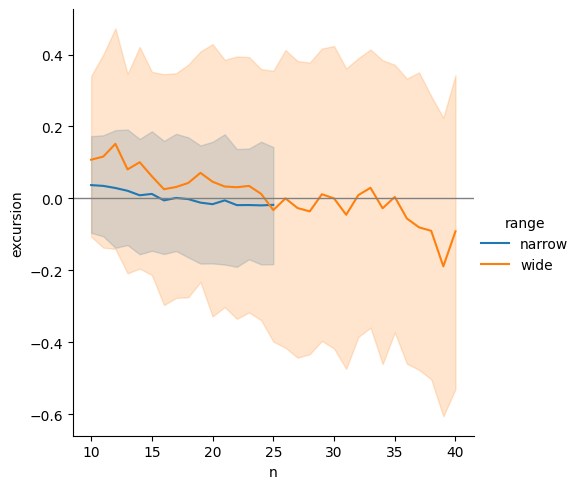

In [161]:
sns.relplot(data=beh, x='n', y='excursion', hue='range', kind='line', )
axhline(0, color='grey', ls='-', lw=1)

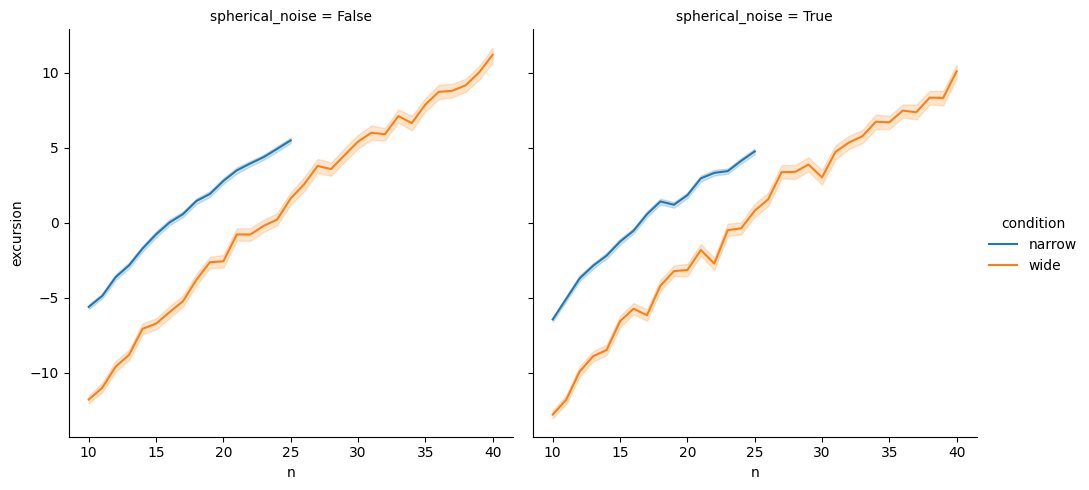

In [162]:
sns.relplot(data=index_filter(fmri_trial_resps), x='n', y='excursion', hue='condition', kind='line', col='spherical_noise')

<Axes: xlabel='excursion', ylabel='Count'>

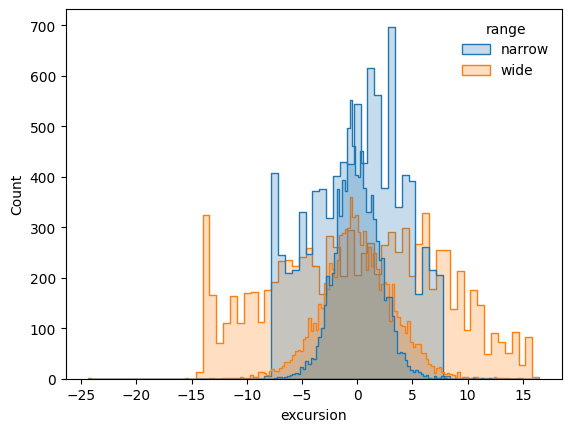

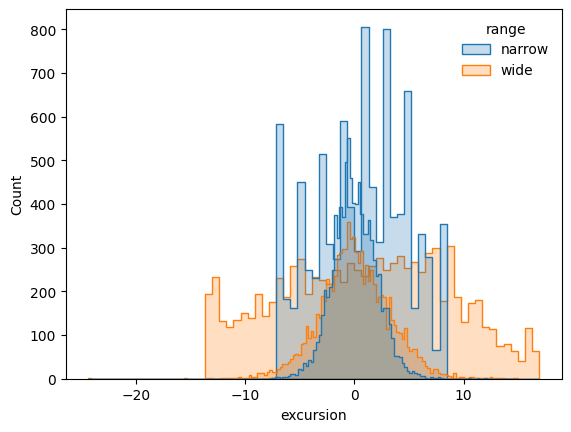

In [165]:
sns.histplot(index_filter(fmri_trial_resps, spherical_noise=True), x='excursion', element='step', hue='condition',)
sns.histplot(beh, x='excursion', element='step', hue='range')
figure()
sns.histplot(index_filter(fmri_trial_resps, spherical_noise=False), x='excursion', element='step', hue='condition',)
sns.histplot(beh, x='excursion', element='step', hue='range')

## Posterior

# ⭐️ FIGURE

• inv_sqrt_fi
Paired t-test: t = -6.529, p = 5.37e-08, dof = 38
• mean_abs_error
Narrow 0.6852998230717119 Wide 0.8001156633343451
Paired t-test: t = -3.561, p = 0.000506, dof = 38
• Variability, fMRI vs behavior
narrow
          n         r        CI95%     p-val    BF10     power
pearson  39  0.482789  [0.25, 1.0]  0.000926  42.514  0.939943
wide
          n         r        CI95%     p-val   BF10     power
pearson  39  0.340508  [0.08, 1.0]  0.016955  3.424  0.695456
• Variability, across x
          n         r         CI95%     p-val    BF10     power
pearson  38  0.473496  [0.18, 0.69]  0.002677  15.515  0.868343
           n         r         CI95%     p-val     power
spearman  38  0.415253  [0.11, 0.65]  0.009528  0.753104
• Change in variability
          n         r        CI95%     p-val   BF10     power
pearson  37  0.325473  [0.06, 1.0]  0.024666  2.556  0.637724
           n         r        CI95%    p-val    power
spearman  37  0.340683  [0.07, 1.0]  0.01954  0.67486


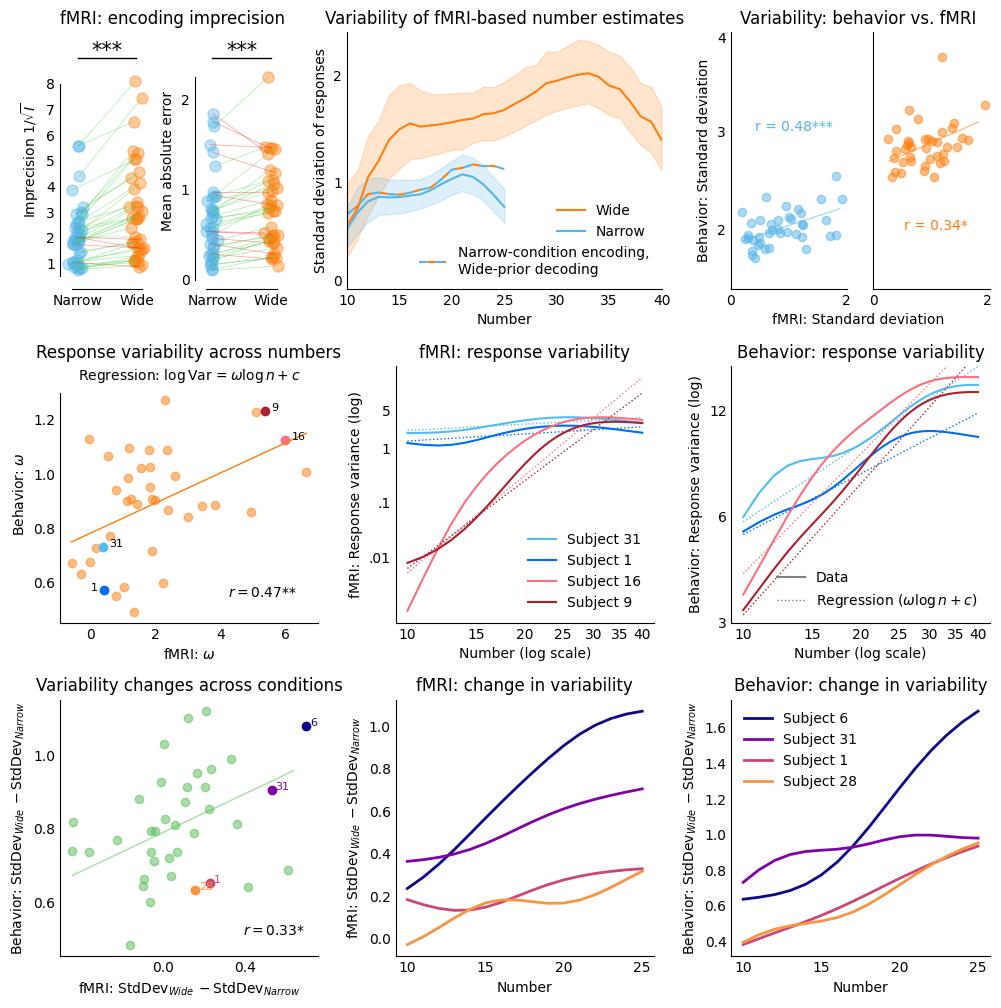

In [475]:
fig, axs = plt.subplots(figsize=(12, 12), nrows=3, ncols=3, gridspec_kw=dict(hspace=.3, wspace=0.3))
#fig = plt.figure(figsize=(12, 12))
#gs_toprow = GridSpec(nrows=3, ncols=4, figure=fig, width_ratios=[.4, .4, 1.2, 1.], hspace=.3,) # wspace=.3*4/3)

##### sqrt{I}
#ax = fig.add_subplot(gs_toprow[0, 0])
gs = GridSpec(nrows=3, ncols=4, figure=fig, hspace=.3, width_ratios=[.35,.35,1.3,1])
ax = fig.add_subplot( gs[0,0] )
axs[0, 0].remove()
model_label = 31
subrange = 'narrowrange' # '1124' # 'all'
qty = 'inv_sqrt_fi' # 'log_fi'
xx1 = index_filter(fisher_info_avgs, subrange=subrange, condition=NARROW, model_label=model_label)[qty].rename(NARROW)
xx2 = index_filter(fisher_info_avgs, subrange=subrange, condition=WIDE, model_label=model_label)[qty].rename(WIDE)
paired_strip_plot(ax, x1=1, x2=2, y1=xx1, y2=xx2, color_decr_line='red', color_incr_line='limegreen', col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE])
ax.set_xlim(0.7, 2.3)
ax.set_ylim({'sqrt_fi':(-.1,2.3), 'inv_sqrt_fi':(0,10)}.get(qty, (None,None)))
ax.set_xticks([1, 2])
ax.set_yticks({'sqrt_fi':[0,1,2], 'inv_sqrt_fi':[1,2,3,4,5,6,7,8]}.get(qty, [0,1]))
#ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_xticklabels(['Narrow', 'Wide'])
###ax.set_title('fMRI: Fisher information')
ax.set_title('fMRI: encoding imprecision', ha='left', x=0)
# paired test
paired_test = pg.ttest(xx1, xx2, paired=True, alternative='less' if qty in ['inv_sqrt_fi', 'inv_fi'] else 'greater')
print(f"• {qty}")
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
y_line = {'sqrt_fi':2.1, 'inv_sqrt_fi':8.75}.get(qty, 2)
star_line(ax, 1, 2, .9, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.01, vertical_lines_length=0., yTransAxes=True)
ax.tick_params(axis='both', length=0)
ax.spines.left.set_bounds({'sqrt_fi':(0,2), 'inv_sqrt_fi':(.5,8)}.get(qty, (None,None)))
ax.spines.bottom.set_bounds((.9, 2.1))
ax.set_ylabel({'sqrt_fi':'$\sqrt{I}$', 'inv_sqrt_fi':'Imprecision $1/\sqrt{I}$'}.get(qty, qty))


###### MSE, or Std Dev of estimates
#ax = fig.add_subplot(gs_toprow[0, 1])
ax = fig.add_subplot( gs[0,1] )
model_label = 31
subrange = 'narrowrange' # 'narrowrange' # '1124'
wide_prior = False # True
qty = 'mean_abs_error' # 'sigma' # 'mean_abs_error' 
xx1 = index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=NARROW, wide_prior=wide_prior)[qty].rename(NARROW)
xx2 = index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=WIDE, wide_prior=wide_prior)[qty].rename(WIDE)
paired_strip_plot(ax, x1=1, x2=2, y1=xx1, y2=xx2, color_decr_line='red', color_incr_line='limegreen', col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE],)
ax.set_xlim(0.7, 2.3)
ax.set_ylim({'sigma':(-.1,3.3), 'mean_abs_error':(-.1,2.75)}.get(qty, (0,3.3)))
ax.set_yticks({'sigma':[0,1,2,3], 'mean_abs_error':[0,1,2]}.get(qty, [0,1,2]))
ax.set_xticks([1, 2])
#ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_xticklabels(['Narrow', 'Wide'])
#ax.set_title('Imprecision of fMRI-derived number estimates', ha='left', x=0)
#ax.set_title('Imprecision in neural encoding and in number estimates', ha='left', x=0)
# paired test
paired_test = pg.ttest(xx1, xx2, paired=True, alternative='less')
print(f"• {qty}")
print('Narrow', xx1.mean(), 'Wide', xx2.mean())
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
star_line(ax, 1, 2, .9, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.01, vertical_lines_length=0., yTransAxes=True)
ax.tick_params(axis='both', length=0)
ax.spines.left.set_bounds({'sigma':(0, 3.), 'mean_abs_error':(0, 2.25)}.get(qty, (None,None)))
ax.spines.bottom.set_bounds((.9, 2.1))
ax.set_ylabel({'sigma':'Average standard deviation', 'mean_abs_error':'Mean absolute error'}.get(qty, qty))


###### Standard deviation of estimates, vs number
## ••• ! Here we use the estimates decoded with each correct prior ! ••• ##
axs[0,1].remove()
#ax = fig.add_subplot(gs_toprow[0, 2])
#ax = fig.add_subplot(3, 3, 2)
this_gs = GridSpec(nrows=3, ncols=3, figure=fig, width_ratios=[.85, 1.15, 1.], hspace=.3, wspace=.2) # wspace=.3*4/3) # width_ratios=[.7, 1.3, 1.]
ax = fig.add_subplot(this_gs[0,1])
#ax = axs[0,1]
ax.set_ylim(0, 2.4)
for cond in [WIDE, NARROW]:
    sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide_prior=cond==WIDE, condition=cond, n=range(10,MAX_COND[cond]+1)), x='n', y='sigma', label=cond.capitalize(),
                 color=COLORS_COND[cond], ax=ax)
sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide_prior=True, condition=NARROW, n=range(10,26)), x='n', y='sigma',
             label='Narrow-condition encoding,\nWide-prior decoding', 
             color=COLORS_COND[NARROW], errorbar=None, ax=ax, dashes=[4, 4], gapcolor=COLORS_COND[WIDE])
leg_hands = list(zip( *ax.get_legend_handles_labels() ))
leg1 = ax.legend( *zip( *leg_hands[:2] ), loc=(.65, .175) )
leg2 = ax.legend( *zip( *leg_hands[2:] ), loc='lower right' )
ax.add_artist(leg1) 
ax.set_xlim(10, 40)
ax.set_xlabel('Number')
ax.set_ylabel('Standard deviation of responses')
#ax.legend(loc='lower right', )
ax.set_yticks([0, 1, 2])
ax.tick_params(axis='both', length=0)
ax.get_yticklabels()[0].set_va('bottom')
ax.set_title('Variability of fMRI-based number estimates')


###### Variability of estimates, fMRI vs behavior
#ax = fig.add_subplot(gs_toprow[0, 3])
#ax = fig.add_subplot(3, 3, 3)
model_label = 31
subrange = 'narrowrange' #'narrowrange' # '1124'
wide_prior = False #'cond'
qtyFMRI = 'sigma'; qtySTAN = 'avg_sigma'
#qtyFMRI = 'var_E'; qtySTAN = 'avg_var'
subjs = set(index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label).index.get_level_values('subject').unique()).intersection(
        index_filter(stan_avgs, subrange=subrange).index.get_level_values('subject').unique())
print("• Variability, fMRI vs behavior")
if False:
    ax = axs[0,2]
    for cond in CONDITIONS:
        wp = wide_prior if wide_prior != 'cond' else cond == WIDE
        xxx = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition=cond, subject=subjs, wide_prior=wp)[qtyFMRI]
        yyy = index_filter(stan_avgs, subrange=subrange, condition=cond, subject=subjs)[qtySTAN]
        ax.scatter(xxx, yyy, alpha=0.5, color=COLORS_COND[cond], )
        res_odr = odr_1dregression(x=xxx, y=yyy)
        x_vals = np.array([np.percentile(xxx, 1), np.percentile(xxx, 99)])
        ax.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=COLORS_COND[cond], )
        print(cond)
        r_pearson = pg.corr(xxx, yyy, alternative='greater')
        print(r_pearson)
        print(pg.corr(xxx, yyy, method='spearman', alternative='greater' ))
        pv = r_pearson['p-val'].iloc[0]
        ax.text({NARROW:.95, WIDE:.05}[cond], {NARROW:.05, WIDE:.95}[cond], f"r = {r_pearson.r.iloc[0]:.2f}{star_string(pv)}", transform=ax.transAxes, va='center', color=COLORS_COND[cond],
                ha='right' if cond == NARROW else 'left',  )
    ax.set_yticks([2,2.5,3, 3.5])
    if False:
        for subj in subjs:
            x1 = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition='narrow', wide_prior=wide_prior if wide_prior != 'cond' else False)[qtyFMRI][subj]
            x2 = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition='wide'  , wide_prior=wide_prior if wide_prior != 'cond' else True)[qtyFMRI][subj]
            y1 = index_filter(stan_avgs, subrange=subrange, condition='narrow')[qtySTAN][subj]
            y2 = index_filter(stan_avgs, subrange=subrange, condition='wide')[qtySTAN][subj]
            plt.plot([x1, x2], [y1, y2],
                #color='limegreen' if (x2 > x1 and y2 > y1) else "#F75656", # if (x2 < x1 and y2 < y1) else 'gray',
                color='grey',
                alpha=0.5, linewidth=1
            )
    ax.set_title('Variability: behavior vs. fMRI')
    ax.set_xlabel('fMRI: Standard deviation')
    ax.set_ylabel('Behavior: Standard deviation')
    ax.tick_params(axis='both', length=0)
else:
    axs[0,2].remove()
    gs = GridSpec(nrows=3, ncols=6, figure=fig, hspace=.3, width_ratios=[1, 1, 1, 1.85, 1, 1])
    these_axs = [ fig.add_subplot( gs[0,4], ), ]
    these_axs.append( fig.add_subplot( gs[0,5], sharey=these_axs[0] ) )
    rs = {}
    for ic,cond in enumerate(CONDITIONS):
        ax = these_axs[ic]
        xxx = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition=cond, subject=subjs, wide_prior=wide_prior)[qtyFMRI]
        yyy = index_filter(stan_avgs, subrange=subrange, condition=cond, subject=subjs)[qtySTAN]
        ax.scatter(xxx, yyy, alpha=0.5, color=COLORS_COND[cond], )
        res_odr = odr_1dregression(x=xxx, y=yyy)
        x_vals = np.array([np.percentile(xxx, 1), np.percentile(xxx, 99)])
        ax.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=COLORS_COND[cond], )
        print(cond)
        r_pearson = pg.corr(xxx, yyy, alternative='greater')
        rs[cond] = r_pearson
        print(r_pearson)
        #print(pg.corr(xxx, yyy, method='spearman', alternative='greater' ))
        ax.tick_params(axis='both', length=0)
        ax.set_xlim(0,None)
    sns.despine(fig)
    these_axs[0].set_ylabel('Behavior: Standard deviation')
    these_axs[0].set_yticks([2, 3, 4])
    these_axs[0].get_yticklabels()[2].set_va('top')
    these_axs[0].set_ylim(1.4, 4)
    these_axs[0].set_xlabel('fMRI: Standard deviation', x=1.1)
    these_axs[0].text(1.1, 3, f"r = {rs[NARROW].r.iloc[0]:.2f}{star_string(rs[NARROW]['p-val'].iloc[0])}", color=COLORS_COND[NARROW], ha='center')
    these_axs[1].text(1.1, 2, f"r = {rs[WIDE].r.iloc[0]:.2f}{star_string(rs[WIDE]['p-val'].iloc[0])}", color=COLORS_COND[WIDE], ha='center')
    these_axs[1].tick_params(labelleft=False)
    these_axs[0].set_title('Variability: behavior vs. fMRI', x=1.1, ha='center')



#gs_row2and3 = GridSpec(nrows=3, ncols=3, figure=fig, width_ratios=[1, 1, 1], hspace=.3, wspace=.3)

######## Variability across x: Weber exponent
#ax = fig.add_subplot(gs_row2and3[1, 0])
ax = axs[1,0]
model_label = 31
cond = WIDE
boundary_buffer = 0
wide_prior = True
c = COLORS_COND[cond] # FOURTH_COLOR
subjs = set(index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique()).intersection(
    index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique())
subjs = set(subjs) - set((24,))
xxx = index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, subject=subjs, boundary_buffer=boundary_buffer, wide_prior=wide_prior).slope
yyy = index_filter(stan_log_var_n_ols, condition=cond, subject=subjs, boundary_buffer=boundary_buffer).slope
print("• Variability, across x")
if 24 in yyy:
    mm, sd = yyy.drop(24).describe()[['mean', 'std']]
    print('Subject 24:', yyy[24])
    print(f"Other subjects: Mean = {mm:.3f}, SD = {sd:.3f}")
    print(f"Subject 24 is {((yyy[24] - mm) / sd):.2f} SD away from the mean of other subjects.")
someSubjs = [31, 1, 16, 9]
ns = np.arange(10, MAX_COND[cond]+1)
# cols = ['#50EEC3', '#009E73', '#FC7080', '#aC2030', ]
# cols = ['#50BEF3', '#006EA3', '#FC7080', '#aC2030', ]
cols = ['#50BEF3', '#006EF3', '#FC7080', '#aC2030', ]
#cols = cm.coolwarm(np.linspace(0., 1, len(someSubjs)))
cols_sid = {sid:col for sid, col in zip(someSubjs, cols)}
r_pearsons = pg.corr(xxx, yyy)
print( r_pearsons ) # method='spearman'
print( pg.corr(xxx, yyy, method='spearman' ) )
ax.scatter(x=xxx[~np.isin(xxx.index, someSubjs)], y=yyy[~np.isin(yyy.index, someSubjs)], color=c, alpha=.5)
for k,subj in enumerate(someSubjs):
    ax.scatter(x=xxx[subj], y=yyy[subj], color=cols_sid[subj], alpha=1., label=f'Subject {subj}',) #ec='k', lw=1)
ax.text(xxx.loc[31]+.2, yyy.loc[31], '31', color='k', fontsize=8,)
ax.text(xxx.loc[ 1]-.4, yyy.loc[ 1],  '1', color='k', fontsize=8,)
ax.text(xxx.loc[16]+.2, yyy.loc[16], '16', color='k', fontsize=8,)
ax.text(xxx.loc[ 9]+.2, yyy.loc[ 9],  '9', color='k', fontsize=8,)
# for subj in subjs:
#     ax.text(xxx[subj], yyy[subj], str(subj), color='k', fontsize=8, ha='center', va='center')
#sns.regplot(x=xxx, y=yyy, color=c, ax=ax, scatter_kws={'color': c, 'alpha': .5}, )
res_odr = odr_1dregression(x=xxx, y=yyy)
x_vals = np.linspace(xxx.min(), xxx.max(), 100)
ax.plot(x_vals, odr_pred(res_odr, x_vals), color=c, lw=1,)
ax.set_title('Response variability across numbers')
ax.text(.5, .945, 'Regression: $\log \operatorname{Var} = \omega \log n + c$', transform=ax.transAxes, ha='center', )
ax.set_xlabel('fMRI: $\omega$')
ax.set_ylabel('Behavior: $\omega$')
pv = r_pearsons['p-val'].iloc[0]
ax.text(0.65, 0.1, f'$r = {r_pearsons.r.iloc[0]:.2f}${star_string(pv)}', transform=ax.transAxes)
ax.tick_params(axis='both', length=0)
ax.set_ylim(None, 1.399)
ax.spines.left.set_bounds((ax.get_ylim()[0], 1.3))

##### example subjects
ax_fmri = axs[1,1] # fig.add_subplot(gs_row2and3[1, 1])
ax_beh  = axs[1,2] # fig.add_subplot(gs_row2and3[1, 2])
log_qties = True
conv_w = .2 if log_qties else 3
lw = 1.5
ns = np.arange(10+boundary_buffer, MAX_COND[cond]+1-boundary_buffer)
xs = np.log(ns) if log_qties else ns
qtyFMRI = 'log_var' if log_qties else 'sigma'
qtyStan = 'log_var' if log_qties else 'sigma'
for k,ii in enumerate(someSubjs):
    xs, ys = smooth_ys(conv_w, xs, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, subject=ii, n=ns, wide_prior=wide_prior)[qtyFMRI], xs=xs)
    ax_fmri.plot(xs, ys, c=cols[k], label=f'Subject {ii}', lw=lw)
    xs, ys = smooth_ys(conv_w, xs, index_filter(stan_subj_n, condition=cond, subject=ii, n=ns)[qtyStan], xs=xs)
    ax_beh.plot(xs, ys , ls='-', c=cols[k], lw=lw)
    if log_qties:
        slope, intercept = index_filter(fmri_log_var_n_ols, model_label=model_label, condition=cond, boundary_buffer=boundary_buffer, wide_prior=wide_prior).loc[ii][['slope', 'intercept']]
        ax_fmri.plot(xs, slope*xs + intercept, ls=':', c=cols[k], lw=1)
        slope, intercept = index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).loc[ii][['slope', 'intercept']]
        ax_beh.plot(xs, slope*xs + intercept, ls=':', c=cols[k], lw=1)
ax_fmri.legend()
for i,ax in enumerate([ax_fmri, ax_beh]):
    ax.set_xlabel('Number' + (' (log scale)' if log_qties else ''))
    ax.tick_params(axis='both', length=0)
    z = 'fMRI' if i == 0 else 'Behavior'
    ax.set_ylabel(f'{z}: Response variance (log)' if log_qties else f'{z}: Response standard deviation')
    if log_qties:
        xticks = np.array([10, 15, 20, 25, 30, 35, 40])
        ax.set_xticks(np.log(xticks))
        ax.set_xticklabels(xticks)
if log_qties:        
    y_ticks = np.array(['.01', '.1', 1, 5])
    ax_fmri.set_yticks(np.log([float(y) for y in y_ticks]))
    ax_fmri.set_yticklabels(y_ticks)
    # print(ax_fmri.get_ylim())
    # ax_fmri.set_ylim(None, 2.5)
    y_ticks = np.array([3, 6, 12])
    ax_beh.set_yticks(np.log(y_ticks))
    ax_beh.set_yticklabels(y_ticks)
    ax_beh.set_ylim(np.log(3), np.log(16))
    ax_beh.legend([Line2D([0], [0], c='grey', lw=lw), Line2D([0], [0], c='grey', ls=ls_reg, lw=1)],
                  ['Data', 'Regression ($\omega \log n + c$)'], loc='lower right')
else:
    ax_fmri.set_yticks([.5, 1, 1.5, 2, ])
ax_fmri.set_title('fMRI: response variability')
ax_beh.set_title('Behavior: response variability')




###### Changes in variability
ax = axs[2,0] # fig.add_subplot(gs_row2and3[2, 0])
subrange = 'narrowrange'
model_label = 18
wide_prior = False
subjects = index_filter(fmri_ests_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
subjects = set(subjects) - set((24,))
qtyX, qtyY = 'sigma_diff', 'avg_sigma_delta_wn'
#qtyX, qtyY = 'var_E_diff', 'avg_var_delta_wn'
xxx = index_filter(fmri_ests_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label, wide_prior=wide_prior)[qtyX] # model_label=15,
yyy = index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[qtyY]
print("• Change in variability")
if 24 in yyy:
    mm, sd = yyy.drop(24).describe()[['mean', 'std']]
    print('Subject 24:', yyy[24])
    print(f"Other subjects: Mean = {mm:.3f}, SD = {sd:.3f}")
    print(f"Subject 24 is {((yyy[24] - mm) / sd):.2f} SD away from the mean of other subjects.")
iis = [6, 31, 1, 28 ]
ax.scatter(x=xxx[~np.isin(xxx.index, iis)], y=yyy[~np.isin(yyy.index, iis)], color=THIRD_COLOR, alpha=.5)
# for subj in subjects: ax.text(xxx[subj], yyy[subj], str(subj), color='k', fontsize=8, ha='center', va='center')
cols = cm.plasma
for k, i in enumerate(iis):
    ax.scatter(x=xxx.loc[i], y=yyy.loc[i], color=cols(k / len(iis)),)
    ax.text(xxx[i]+.02, yyy[i], str(i), color=cols(k / len(iis)), fontsize=8,)
#sns.regplot(x=xxx, y=yyy, color=THIRD_COLOR, ax=ax)
res_odr = odr_1dregression(x=xxx, y=yyy)
x_vals = np.array([np.percentile(xxx, 2), np.percentile(xxx, 98)])
ax.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=THIRD_COLOR, )
p_corr_res = pg.corr(xxx, yyy, alternative='greater');
s_corr_res = pg.corr(xxx, yyy, method='spearman', alternative='greater')
print(p_corr_res)
print(s_corr_res)
ax.set_title('Variability changes across conditions') #('Individual adaptations')
ax.set_xlabel('fMRI: $\operatorname{StdDev}_{Wide} - \operatorname{StdDev}_{Narrow}$')
ax.set_ylabel('Behavior: $\operatorname{StdDev}_{Wide} - \operatorname{StdDev}_{Narrow}$')
pv = p_corr_res['p-val'].iloc[0]
ax.text(0.95, 0.1, f"$r = {p_corr_res.r.iloc[0]:.2f}${star_string(pv)}", transform=ax.transAxes, va='center', ha='right', ) #fontsize=12, )
ax.set_xticks([0, .4])
ax.set_yticks([.6, .8, 1])
ax.tick_params(axis='both', length=0)

########### Example subjects
ax_fmri = axs[2, 1] # fig.add_subplot(gs_row2and3[2, 1])
ax_beh  = axs[2, 2] # fig.add_subplot(gs_row2and3[2, 2])
subrange = '1124'
model_label = 18
wide_prior = False
subjects = index_filter(fmri_ests_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
subjects = set(subjects) - set((24,))
qtyX, qtyY = 'sigma_diff', 'avg_sigma_delta_wn'
#qtyX, qtyY = 'var_E_diff', 'avg_var_delta_wn'
iis = [6, 31, 1, 28 ] # 2, 30
ns = np.arange(10, 25+1)
#cols = ['#009E73', '#50EEC3', '#FC7080', '#aC2030', ] # sns.color_palette('colorblind')
#cols = ['#50BEF3', '#006EF3', '#FC7080', '#aC2030', '#FFB300', '#D55E00', ] # sns.color_palette('colorblind')
cols = cm.plasma
conv_w = 3
lw = 2.
for k,ii in enumerate(iis):
    xs, ys = smooth_ys(conv_w, ns, index_filter(fmri_estimates_deltas, model_label=model_label, n=ns, subject=ii).sigma_diff, xs=ns)
    ax_fmri.plot(ns, ys, c=cols(k/(len(iis))), label=f'Subject {ii}', lw=lw)
    #axs[0].text(ns[-1]+.5, ys[-1], str(ii), color=cols(k/(len(iis))), fontsize=8, ha='left', va='center')
    xs, ys = smooth_ys(conv_w, ns, index_filter(stan_deltas_subj_n, n=ns, subject=ii).delta_sigma, xs=ns)
    ax_beh.plot(xs, ys , c=cols(k/(len(iis))), label=f'Subject {ii}', lw=lw)
    #axs[1].text(xs[-1]+.5, ys[-1], str(ii), color=cols(k/(len(iis))), fontsize=8, ha='left', va='center')
ax_beh.legend(loc='upper left', )
#axs[0].set_yticks([.5, 1, 1.5, 2, ])
for i, ax in enumerate((ax_fmri, ax_beh)):
    ax.set_xlabel('Number')
    ax.tick_params(axis='both', length=0)
    z = 'fMRI' if i == 0 else 'Behavior'
    ax.set_ylabel(f'{z}: $\operatorname{{StdDev}}_{{Wide}} - \operatorname{{StdDev}}_{{Narrow}}$')
    ax.set_xticks([10,15,20,25])
    #ax.set_ylim(0,None)
ax_fmri.set_title('fMRI: change in variability')
ax_beh.set_title('Behavior: change in variability')

sns.despine(fig=fig)

plt.savefig('figures/fmri_beh_variability.pdf', bbox_inches='tight')